# Week 1 Session 2: Regression Techniques and Model Evaluation

## Learning Objectives

By the end of this session, you will be able to:
1. Apply linear regression with mathematical understanding of the cost function
2. Extend to polynomial regression and recognize when it is needed
3. Evaluate models using MSE, RMSE, MAE, and R-squared
4. Explain the bias-variance tradeoff and detect overfitting
5. Apply Ridge and Lasso regularization to control model complexity
6. Understand the logistic regression sigmoid function (classification preview)

## Session Outline

| Section | Topic |
|---------|-------|
| 1 | Linear Regression Foundations |
| 2 | Evaluation Metrics |
| 3 | Polynomial Regression |
| 4 | Bias-Variance Tradeoff |
| 5 | Regularization |
| 6 | Logistic Regression Introduction |
| 7 | Lab Exercise |

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, accuracy_score)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 300
sns.set_style('whitegrid')
np.random.seed(42)

---
## 1. Linear Regression Foundations

### Mathematical Formulation

Linear regression models the relationship between features $X$ and target $y$ as:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

The model finds coefficients $\beta$ that minimize the **Mean Squared Error (cost function)**:

$$J(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

The closed-form solution (**Ordinary Least Squares**):

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

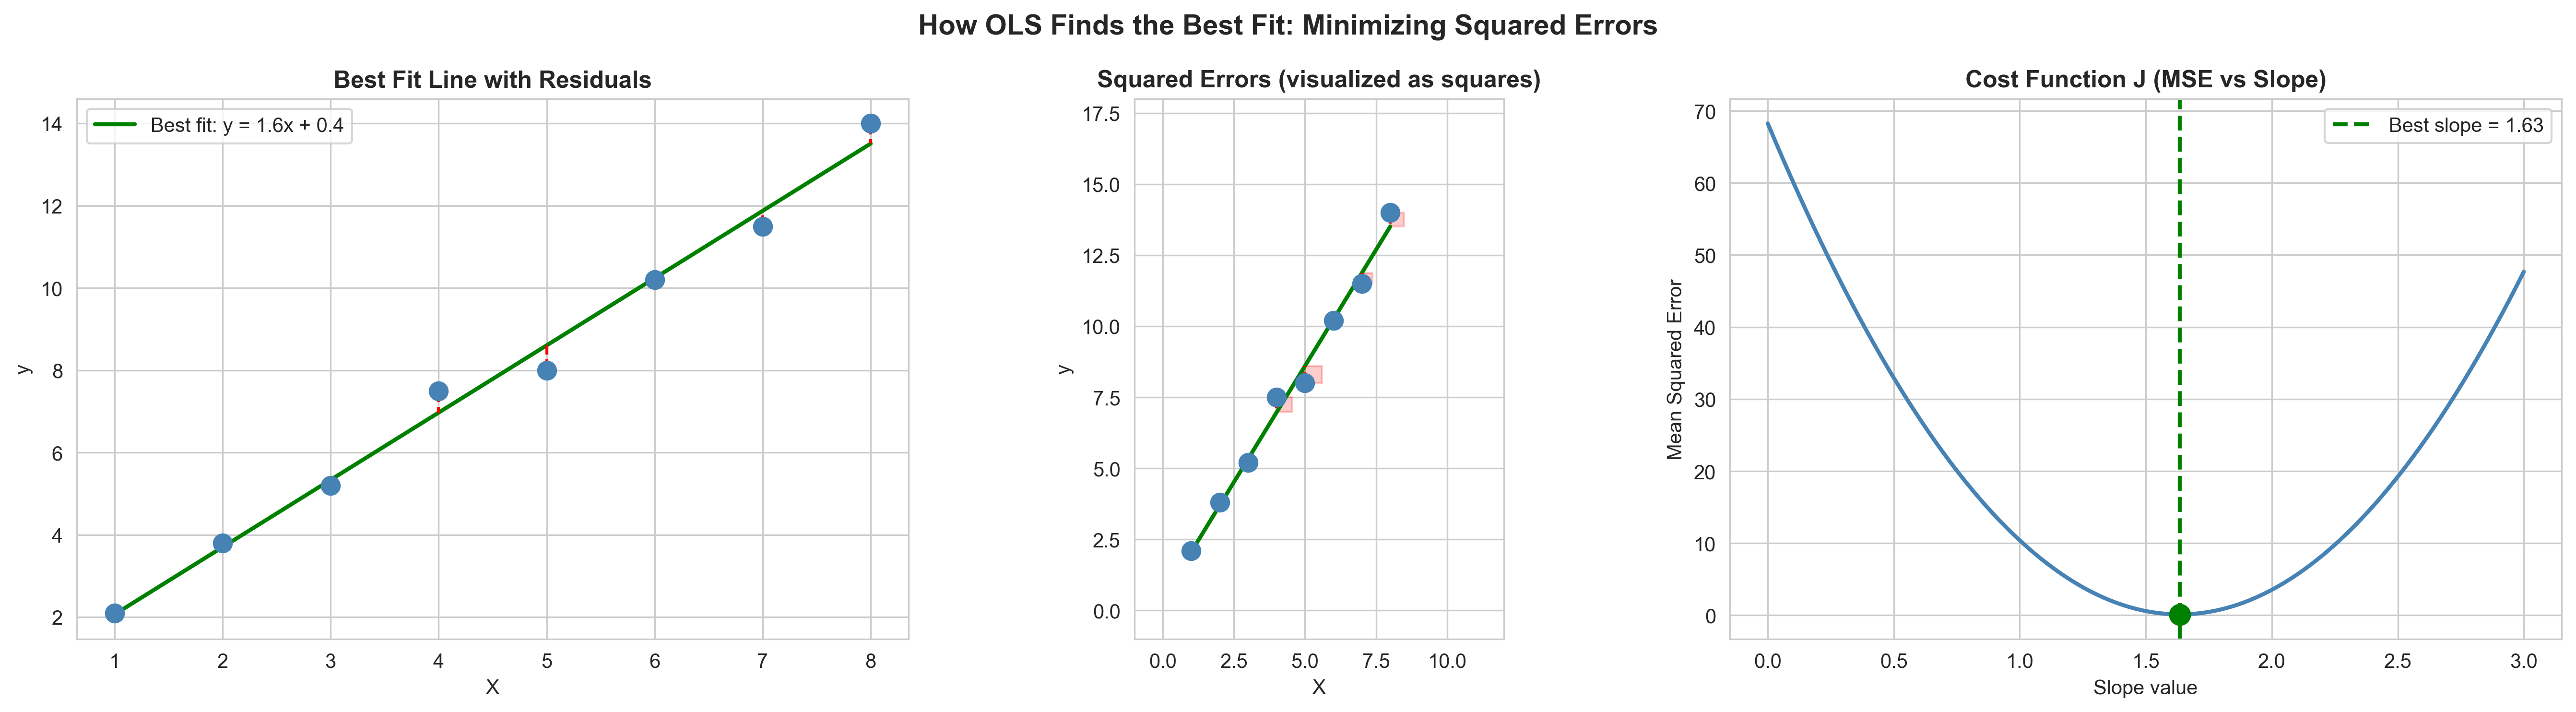

Best fit line: y = 1.63x + 0.43
Minimum MSE: 0.132

OLS finds the slope (1.63) that sits at the bottom of the cost curve.
Any other slope produces a HIGHER MSE.


In [80]:
# Visualizing How Linear Regression Works: Minimizing Squared Errors
np.random.seed(42)

# Generate simple data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([2.1, 3.8, 5.2, 7.5, 8.0, 10.2, 11.5, 14.0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: The data + best fit line with residual lines ---
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(x, y, 1)  # intercept, slope
y_pred = m * x + b

axes[0].scatter(x, y, s=80, color='steelblue', zorder=5)
axes[0].plot(x, y_pred, color='green', linewidth=2, label=f'Best fit: y = {m:.1f}x + {b:.1f}')

# Draw residual lines from each point to the line
for xi, yi, yp in zip(x, y, y_pred):
    axes[0].plot([xi, xi], [yi, yp], color='red', linewidth=1.5, linestyle='--')

axes[0].set_title('Best Fit Line with Residuals', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend()

# --- Plot 2: Show the squared errors as actual squares ---
axes[1].scatter(x, y, s=80, color='steelblue', zorder=5)
axes[1].plot(x, y_pred, color='green', linewidth=2)

for xi, yi, yp in zip(x, y, y_pred):
    error = abs(yi - yp)
    # Draw a square whose side length = the residual
    square = plt.Rectangle((xi, min(yi, yp)), error, error,
                            alpha=0.2, facecolor='red', edgecolor='red', linewidth=1)
    axes[1].add_patch(square)
    axes[1].plot([xi, xi], [yi, yp], color='red', linewidth=1.5, linestyle='--')

axes[1].set_title('Squared Errors (visualized as squares)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].set_xlim(-1, 12)
axes[1].set_ylim(-1, 18)
axes[1].set_aspect('equal')

# --- Plot 3: MSE landscape - show that OLS finds the minimum ---
slopes = np.linspace(0, 3, 200)
intercepts = b  # fix intercept, vary slope to show the curve
mse_values = [np.mean((y - (s * x + intercepts))**2) for s in slopes]

axes[2].plot(slopes, mse_values, color='steelblue', linewidth=2)
axes[2].axvline(x=m, color='green', linewidth=2, linestyle='--', label=f'Best slope = {m:.2f}')
axes[2].scatter([m], [np.mean((y - y_pred)**2)], color='green', s=100, zorder=5)
axes[2].set_title('Cost Function J (MSE vs Slope)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Slope value')
axes[2].set_ylabel('Mean Squared Error')
axes[2].legend()

plt.suptitle('How OLS Finds the Best Fit: Minimizing Squared Errors',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the MSE
mse = np.mean((y - y_pred)**2)
print(f'Best fit line: y = {m:.2f}x + {b:.2f}')
print(f'Minimum MSE: {mse:.3f}')
print(f'\nOLS finds the slope ({m:.2f}) that sits at the bottom of the cost curve.')
print(f'Any other slope produces a HIGHER MSE.')


### Simple Linear Regression

**Dataset:** `FuelConsumptionCo2.csv` -- predicting CO2 emissions from engine size.

Simple Linear Regression R-squared: 0.7616
Simple Linear Regression MSE: 985.9382
Simple Linear Regression MAE: 24.0973


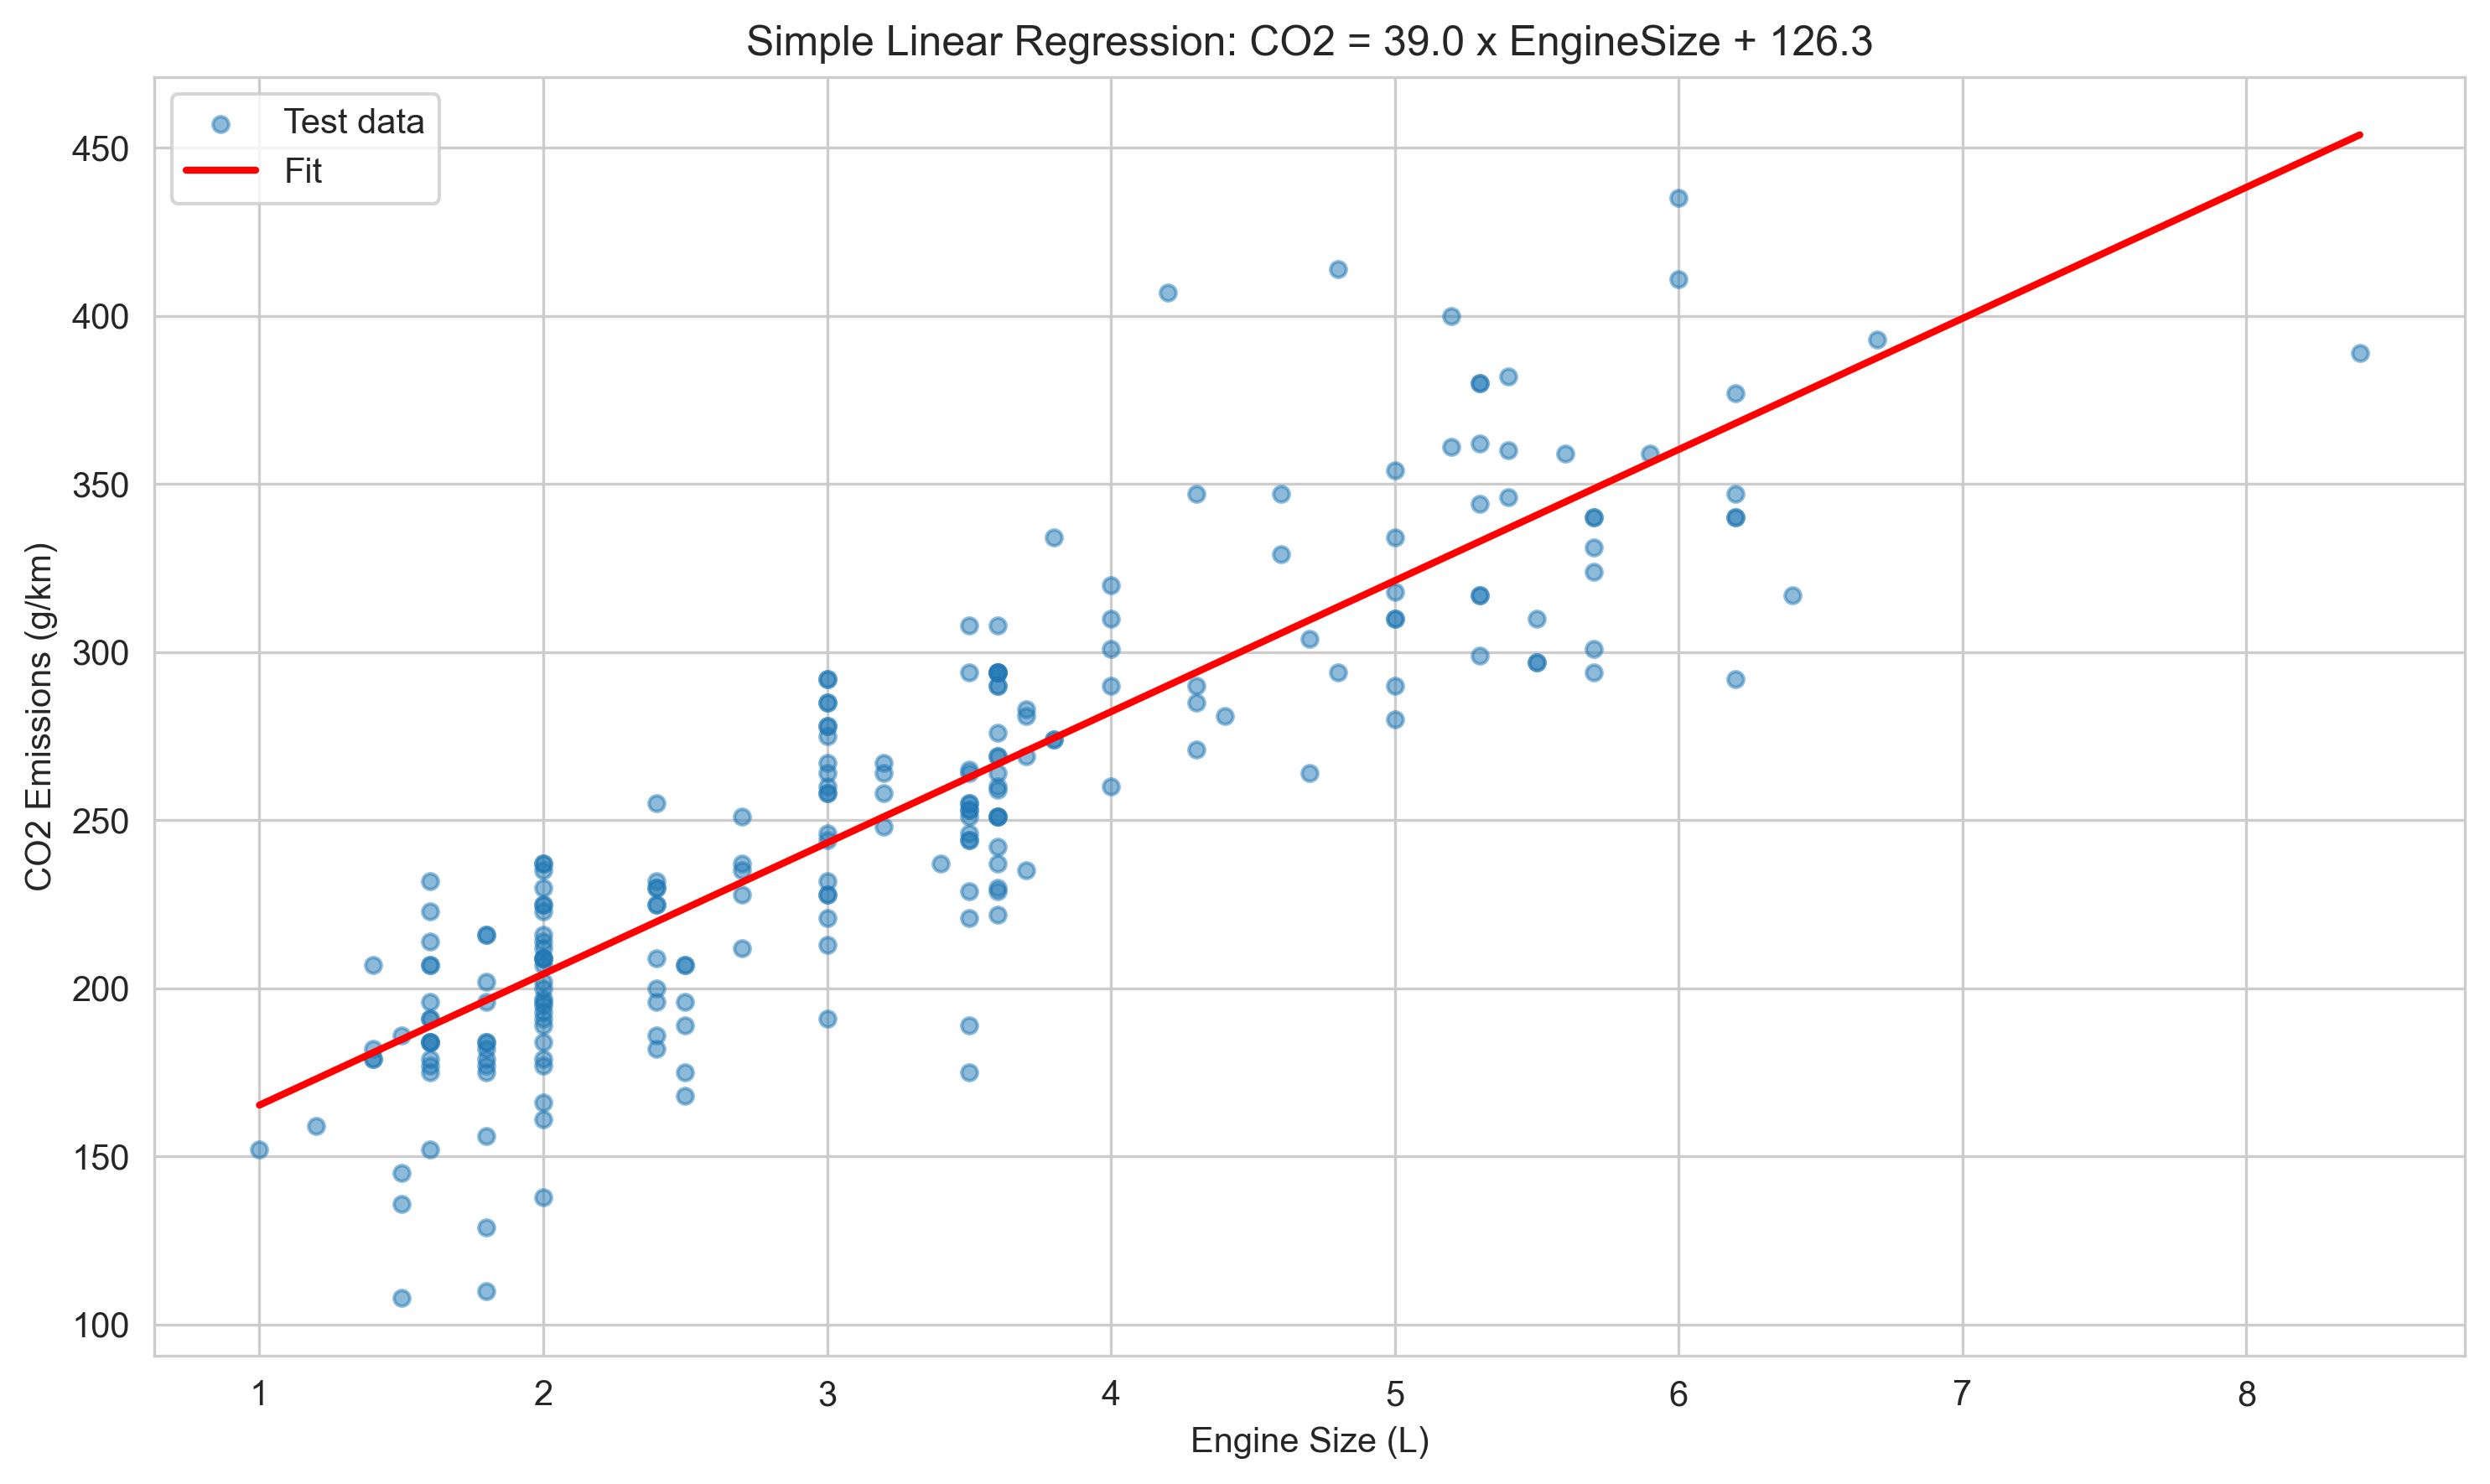

R-squared: 0.7616


In [81]:
# Load the fuel consumption dataset
fuel_df = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')

# Simple Linear Regression: CO2 Emissions vs Engine Size
# We will start with a simple linear regression using just one feature: Engine Size.
X_simple = fuel_df[['ENGINESIZE']]
y = fuel_df['CO2EMISSIONS']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Define the simple linear regression model
model_simple = LinearRegression()

# Fit the model to the training data
model_simple.fit(X_train, y_train)

# Make predictions on the test set
# This will give us the predicted CO2 emissions based on the engine size in the test set.
y_pred_simple = model_simple.predict(X_test)

# Evaluate the model using R-squared, MSE, and MAE
mse_simple = mean_squared_error(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)
print(f'Simple Linear Regression R-squared: {r2_simple:.4f}')
print(f'Simple Linear Regression MSE: {mse_simple:.4f}')
print(f'Simple Linear Regression MAE: {mae_simple:.4f}')


# Plot data with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.5, s=20, label='Test data')
X_sorted = X_test.sort_values('ENGINESIZE')
plt.plot(X_sorted, model_simple.predict(X_sorted), color='red', linewidth=2, label='Fit')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.title(f'Simple Linear Regression: CO2 = {model_simple.coef_[0]:.1f} x EngineSize + {model_simple.intercept_:.1f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'R-squared: {r2_score(y_test, y_pred_simple):.4f}')

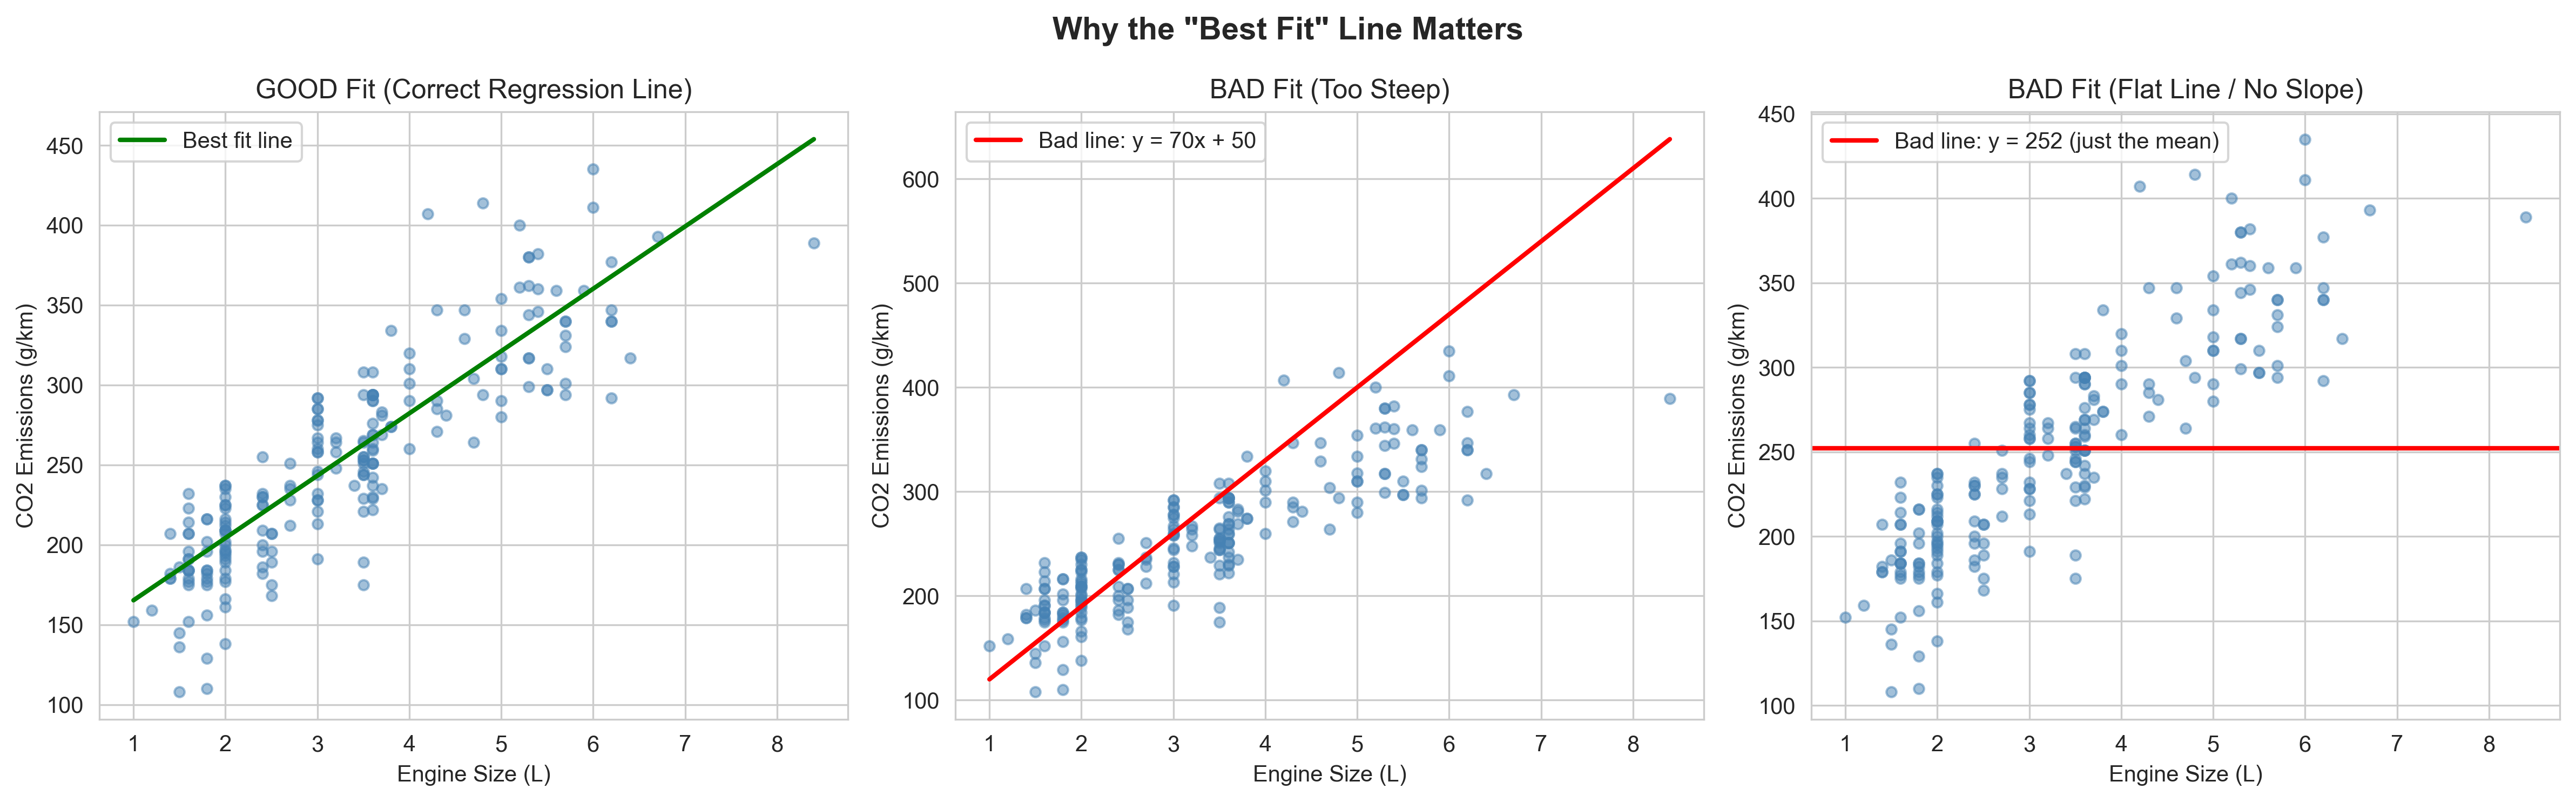

Mean Squared Error comparison:
  GOOD fit (regression line):  986
  BAD fit (too steep):         3,663
  BAD fit (flat / mean only):  4,135

The regression line minimizes MSE -- any other line produces MORE error.


In [82]:
# Good vs Bad Fit Lines: Understanding what makes a regression line "good"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

X_sorted = X_test.sort_values('ENGINESIZE')
y_sorted = y_test.loc[X_sorted.index]

# Plot 1: GOOD fit (the actual regression line)
axes[0].scatter(X_sorted, y_sorted, alpha=0.5, s=20, color='steelblue')
axes[0].plot(X_sorted, model_simple.predict(X_sorted), color='green', linewidth=2, label='Best fit line')
axes[0].set_xlabel('Engine Size (L)')
axes[0].set_ylabel('CO2 Emissions (g/km)')
axes[0].set_title('GOOD Fit (Correct Regression Line)')
axes[0].legend()

# Plot 2: BAD fit -- slope too steep, intercept too low
axes[1].scatter(X_sorted, y_sorted, alpha=0.5, s=20, color='steelblue')
bad_slope = 70  # too steep
bad_intercept = 50  # too low
axes[1].plot(X_sorted, bad_slope * X_sorted['ENGINESIZE'] + bad_intercept,
             color='red', linewidth=2, label=f'Bad line: y = {bad_slope}x + {bad_intercept}')
axes[1].set_xlabel('Engine Size (L)')
axes[1].set_ylabel('CO2 Emissions (g/km)')
axes[1].set_title('BAD Fit (Too Steep)')
axes[1].legend()

# Plot 3: BAD fit -- flat line (ignoring the relationship)
axes[2].scatter(X_sorted, y_sorted, alpha=0.5, s=20, color='steelblue')
flat_value = y_test.mean()
axes[2].axhline(y=flat_value, color='red', linewidth=2,
                label=f'Bad line: y = {flat_value:.0f} (just the mean)')
axes[2].set_xlabel('Engine Size (L)')
axes[2].set_ylabel('CO2 Emissions (g/km)')
axes[2].set_title('BAD Fit (Flat Line / No Slope)')
axes[2].legend()

plt.suptitle('Why the "Best Fit" Line Matters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show the errors for each line
good_mse = mean_squared_error(y_test, model_simple.predict(X_test))
bad_steep_pred = bad_slope * X_test['ENGINESIZE'] + bad_intercept
bad_steep_mse = mean_squared_error(y_test, bad_steep_pred)
bad_flat_mse = mean_squared_error(y_test, [flat_value] * len(y_test))

print('Mean Squared Error comparison:')
print(f'  GOOD fit (regression line):  {good_mse:,.0f}')
print(f'  BAD fit (too steep):         {bad_steep_mse:,.0f}')
print(f'  BAD fit (flat / mean only):  {bad_flat_mse:,.0f}')
print(f'\nThe regression line minimizes MSE -- any other line produces MORE error.')


### Multivariable Linear Regression

Adding more features can improve the model. Let us use engine size, cylinders, and combined fuel consumption.

In [83]:

# Multivariable Linear Regression: Adding More Features
X_multi = fuel_df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]

# Split the data into training and testing sets for the multivariable model
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Define and fit the multivariable linear regression model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Make predictions on the test set for the multivariable model
y_pred_multi = model_multi.predict(X_test_m)


print('Multivariable regression coefficients:')
for feature, coef in zip(X_multi.columns, model_multi.coef_):
    print(f'  {feature}: {coef:.4f}')
print(f'  Intercept: {model_multi.intercept_:.4f}')

print(f'\nSimple model R-squared:  {r2_score(y_test, y_pred_simple):.4f}')
print(f'Multi model R-squared:   {r2_score(y_test_m, y_pred_multi):.4f}')

Multivariable regression coefficients:
  ENGINESIZE: 11.2094
  CYLINDERS: 7.1556
  FUELCONSUMPTION_COMB: 9.5208
  Intercept: 67.3484

Simple model R-squared:  0.7616
Multi model R-squared:   0.8760


### Linear Regression Assumptions

For OLS estimates to be reliable, four assumptions should hold:

| Assumption | Description |
|-----------|-------------|
| **Linearity** | The relationship between X and y is approximately linear |
| **Independence** | Observations are independent of each other |
| **Homoscedasticity** | Residuals have constant variance across all predicted values |
| **Normality** | Residuals are approximately normally distributed |

Violations do not invalidate the model, but they affect the reliability of coefficient estimates and confidence intervals.

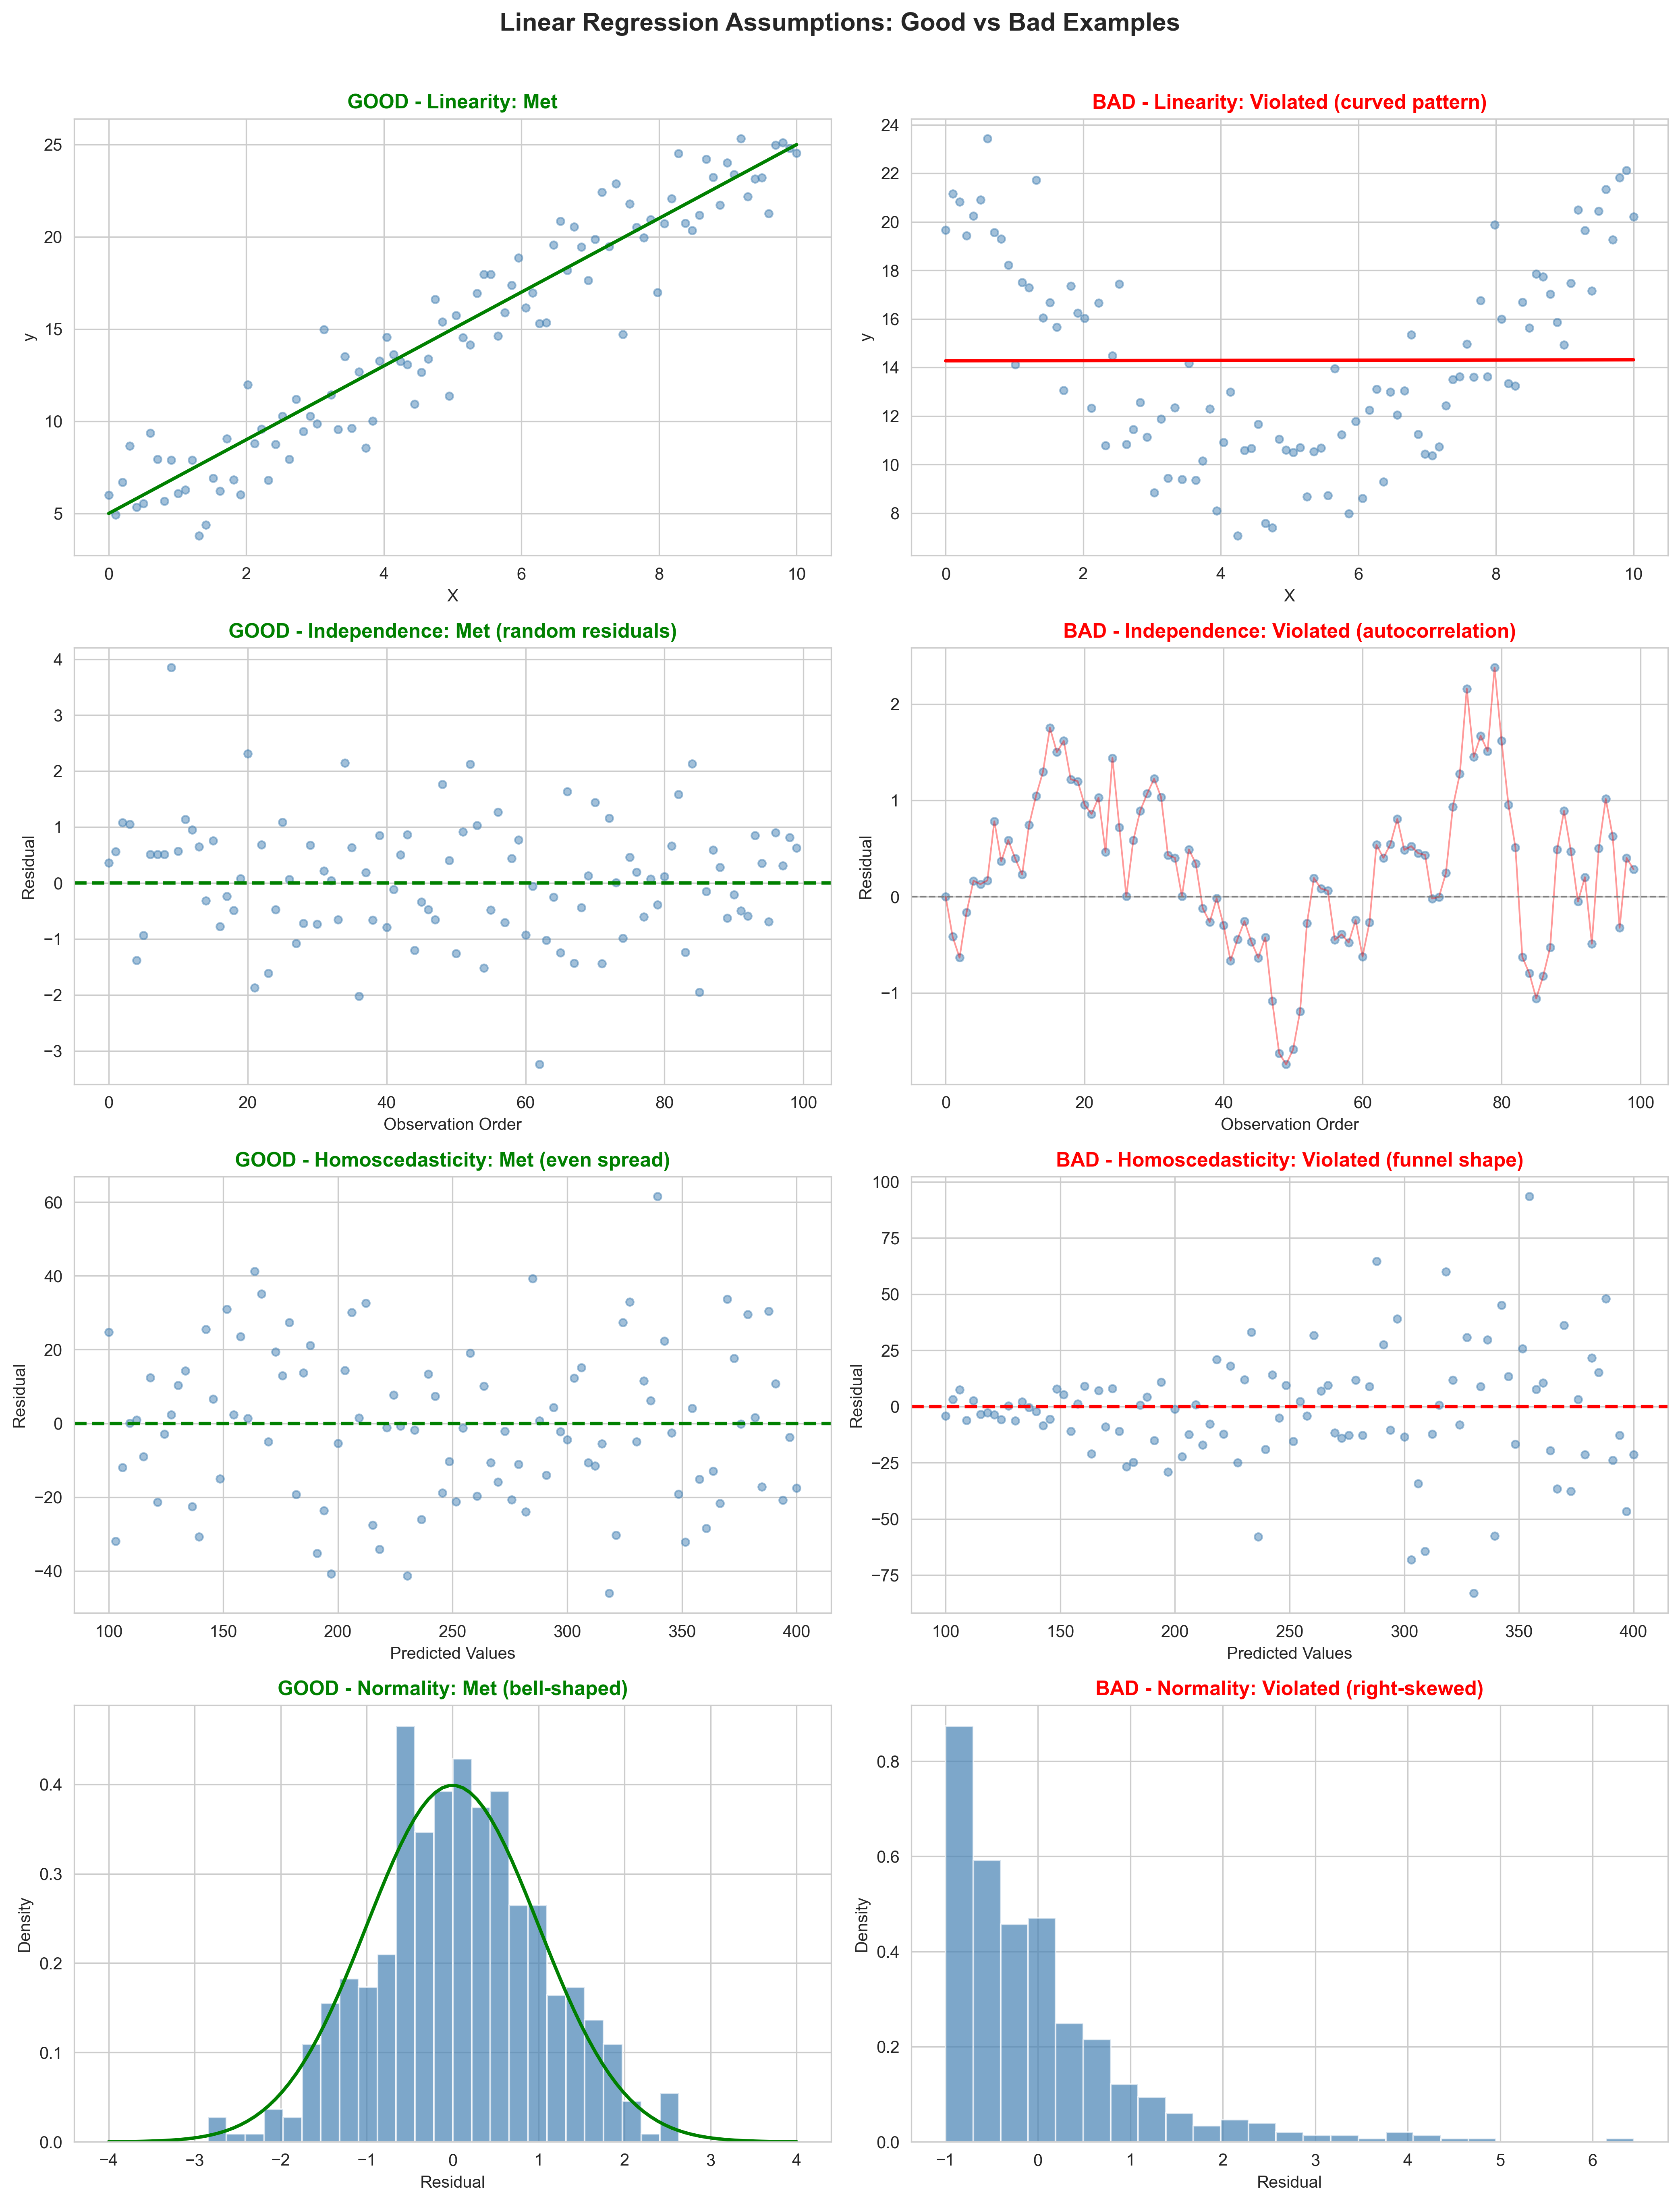

In [84]:
# Visual Guide: Linear Regression Assumptions - Good vs Bad Examples
np.random.seed(42)
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

# --- 1. LINEARITY ---
x = np.linspace(0, 10, 100)
# Good: linear relationship
y_linear = 2 * x + 5 + np.random.normal(0, 2, 100)
axes[0, 0].scatter(x, y_linear, alpha=0.5, s=20, color='steelblue')
axes[0, 0].plot(x, 2 * x + 5, color='green', linewidth=2)
axes[0, 0].set_title('GOOD - Linearity: Met', fontsize=12, fontweight='bold', color='green')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('y')

# Bad: curved relationship with a straight line forced through it
y_curve = 0.5 * (x - 5)**2 + 10 + np.random.normal(0, 2, 100)
axes[0, 1].scatter(x, y_curve, alpha=0.5, s=20, color='steelblue')
z = np.polyfit(x, y_curve, 1)
axes[0, 1].plot(x, np.polyval(z, x), color='red', linewidth=2)
axes[0, 1].set_title('BAD - Linearity: Violated (curved pattern)', fontsize=12, fontweight='bold', color='red')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('y')

# --- 2. INDEPENDENCE ---
# Good: random residuals (no pattern over time/order)
residuals_indep = np.random.normal(0, 1, 100)
axes[1, 0].scatter(range(100), residuals_indep, alpha=0.5, s=20, color='steelblue')
axes[1, 0].axhline(y=0, color='green', linewidth=2, linestyle='--')
axes[1, 0].set_title('GOOD - Independence: Met (random residuals)', fontsize=12, fontweight='bold', color='green')
axes[1, 0].set_xlabel('Observation Order')
axes[1, 0].set_ylabel('Residual')

# Bad: autocorrelated residuals (each depends on the previous)
residuals_dep = np.zeros(100)
for i in range(1, 100):
    residuals_dep[i] = 0.85 * residuals_dep[i-1] + np.random.normal(0, 0.5)
axes[1, 1].scatter(range(100), residuals_dep, alpha=0.5, s=20, color='steelblue')
axes[1, 1].plot(range(100), residuals_dep, color='red', alpha=0.4, linewidth=1)
axes[1, 1].axhline(y=0, color='gray', linewidth=1, linestyle='--')
axes[1, 1].set_title('BAD - Independence: Violated (autocorrelation)', fontsize=12, fontweight='bold', color='red')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')

# --- 3. HOMOSCEDASTICITY ---
# Good: constant spread of residuals
predicted_good = np.linspace(100, 400, 100)
resid_homo = np.random.normal(0, 20, 100)
axes[2, 0].scatter(predicted_good, resid_homo, alpha=0.5, s=20, color='steelblue')
axes[2, 0].axhline(y=0, color='green', linewidth=2, linestyle='--')
axes[2, 0].set_title('GOOD - Homoscedasticity: Met (even spread)', fontsize=12, fontweight='bold', color='green')
axes[2, 0].set_xlabel('Predicted Values')
axes[2, 0].set_ylabel('Residual')

# Bad: funnel shape (variance increases with predicted value)
predicted_bad = np.linspace(100, 400, 100)
resid_hetero = np.random.normal(0, 1, 100) * (predicted_bad - 80) * 0.15
axes[2, 1].scatter(predicted_bad, resid_hetero, alpha=0.5, s=20, color='steelblue')
axes[2, 1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[2, 1].set_title('BAD - Homoscedasticity: Violated (funnel shape)', fontsize=12, fontweight='bold', color='red')
axes[2, 1].set_xlabel('Predicted Values')
axes[2, 1].set_ylabel('Residual')

# --- 4. NORMALITY OF RESIDUALS ---
from scipy.stats import norm
# Good: residuals follow a bell curve
resid_normal = np.random.normal(0, 1, 500)
axes[3, 0].hist(resid_normal, bins=25, color='steelblue', edgecolor='white', alpha=0.7, density=True)
xn = np.linspace(-4, 4, 100)
axes[3, 0].plot(xn, norm.pdf(xn, 0, 1), color='green', linewidth=2)
axes[3, 0].set_title('GOOD - Normality: Met (bell-shaped)', fontsize=12, fontweight='bold', color='green')
axes[3, 0].set_xlabel('Residual')
axes[3, 0].set_ylabel('Density')

# Bad: residuals are skewed
resid_skewed = np.random.exponential(1, 500) - 1
axes[3, 1].hist(resid_skewed, bins=25, color='steelblue', edgecolor='white', alpha=0.7, density=True)
axes[3, 1].set_title('BAD - Normality: Violated (right-skewed)', fontsize=12, fontweight='bold', color='red')
axes[3, 1].set_xlabel('Residual')
axes[3, 1].set_ylabel('Density')

plt.suptitle('Linear Regression Assumptions: Good vs Bad Examples', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 2. Evaluation Metrics

How do we measure how well a regression model performs?

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Average squared error; penalizes large errors heavily |
| **RMSE** | $\sqrt{MSE}$ | Same units as target; easier to interpret than MSE |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error; robust to outliers |
| **R-squared** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (0 to 1) |

In [85]:
# Calculate all metrics for the multivariable model
mse = mean_squared_error(y_test_m, y_pred_multi)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_m, y_pred_multi)
r2 = r2_score(y_test_m, y_pred_multi)

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R-squared'],
    'Value': [f'{mse:.2f}', f'{rmse:.2f}', f'{mae:.2f}', f'{r2:.4f}'],
    'Interpretation': [
        'Average squared error',
        f'Typical prediction error: +/- {rmse:.1f} g/km',
        f'Average absolute error: {mae:.1f} g/km',
        f'{r2*100:.1f}% of variance explained'
    ]
})
print(metrics_df.to_string(index=False))

   Metric  Value                          Interpretation
      MSE 512.86                   Average squared error
     RMSE  22.65 Typical prediction error: +/- 22.6 g/km
      MAE  16.72       Average absolute error: 16.7 g/km
R-squared 0.8760             87.6% of variance explained


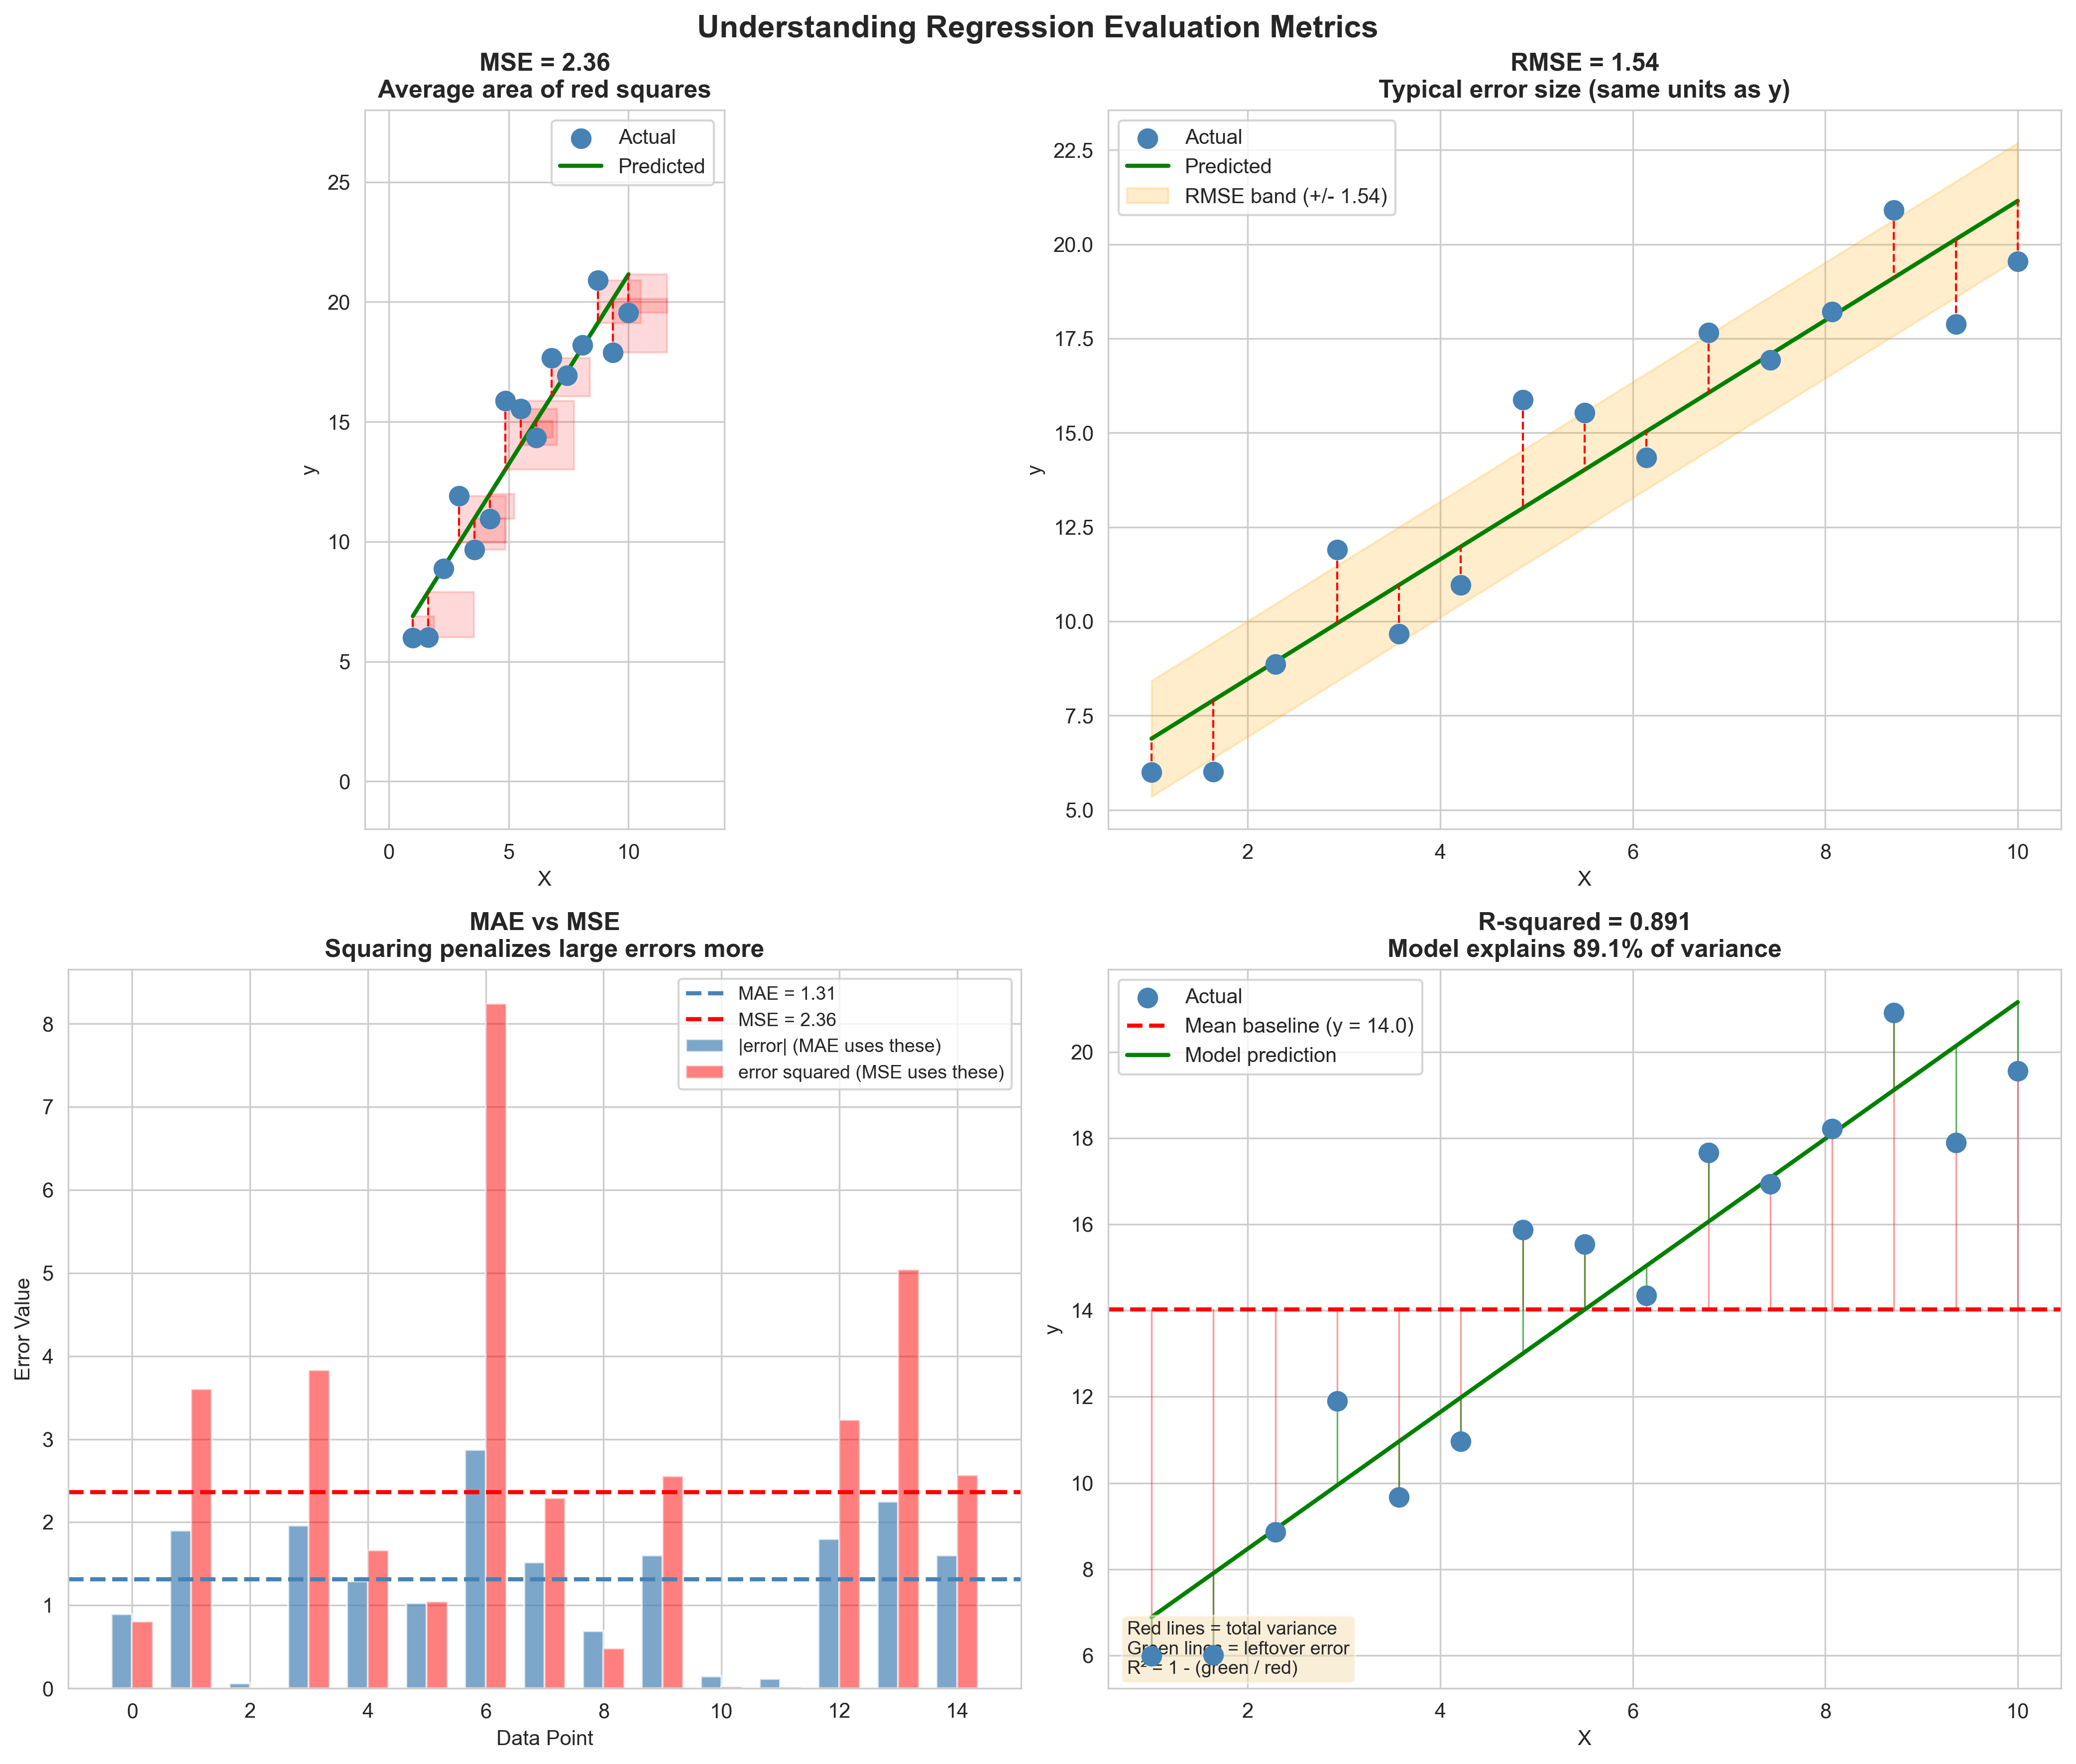

Summary:
  MSE  = 2.36  -- average squared error (penalizes large errors)
  RMSE = 1.54  -- square root of MSE (same units as y)
  MAE  = 1.31  -- average absolute error (treats all errors equally)
  R²   = 0.891  -- 89.1% of variance explained (1.0 = perfect)


In [86]:
# Visualizing Evaluation Metrics
np.random.seed(42)

# Generate simple data with a clear linear trend + some noise
x = np.linspace(1, 10, 15)
y_true = 2 * x + 3 + np.random.normal(0, 2, 15)

# Fit a line
from numpy.polynomial.polynomial import polyfit
b, m = polyfit(x, y_true, 1)
y_pred = m * x + b
y_mean = np.mean(y_true)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1: MSE - Show squared errors ---
axes[0, 0].scatter(x, y_true, s=80, color='steelblue', zorder=5, label='Actual')
axes[0, 0].plot(x, y_pred, color='green', linewidth=2, label='Predicted')

for xi, yi, yp in zip(x, y_true, y_pred):
    error = abs(yi - yp)
    square = plt.Rectangle((xi, min(yi, yp)), error, error,
                            alpha=0.15, facecolor='red', edgecolor='red', linewidth=1)
    axes[0, 0].add_patch(square)
    axes[0, 0].plot([xi, xi], [yi, yp], color='red', linewidth=1, linestyle='--')

mse = np.mean((y_true - y_pred)**2)
axes[0, 0].set_title(f'MSE = {mse:.2f}\nAverage area of red squares', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('y')
axes[0, 0].legend()
axes[0, 0].set_xlim(-1, 14)
axes[0, 0].set_ylim(-2, 28)
axes[0, 0].set_aspect('equal')

# --- Plot 2: RMSE - Show it's in the same units as y ---
axes[0, 1].scatter(x, y_true, s=80, color='steelblue', zorder=5, label='Actual')
axes[0, 1].plot(x, y_pred, color='green', linewidth=2, label='Predicted')

rmse = np.sqrt(mse)
# Show RMSE as a band around the prediction line
axes[0, 1].fill_between(x, y_pred - rmse, y_pred + rmse,
                         alpha=0.2, color='orange', label=f'RMSE band (+/- {rmse:.2f})')

for xi, yi, yp in zip(x, y_true, y_pred):
    axes[0, 1].plot([xi, xi], [yi, yp], color='red', linewidth=1, linestyle='--')

axes[0, 1].set_title(f'RMSE = {rmse:.2f}\nTypical error size (same units as y)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('y')
axes[0, 1].legend()

# --- Plot 3: MAE vs MSE - Show how MSE penalizes outliers more ---
errors = y_true - y_pred
abs_errors = np.abs(errors)
sq_errors = errors**2

x_idx = np.arange(len(errors))
width = 0.35

axes[1, 0].bar(x_idx - width/2, abs_errors, width, color='steelblue', alpha=0.7, label='|error| (MAE uses these)')
axes[1, 0].bar(x_idx + width/2, sq_errors, width, color='red', alpha=0.5, label='error squared (MSE uses these)')

mae = np.mean(abs_errors)
axes[1, 0].axhline(y=mae, color='steelblue', linewidth=2, linestyle='--', label=f'MAE = {mae:.2f}')
axes[1, 0].axhline(y=mse, color='red', linewidth=2, linestyle='--', label=f'MSE = {mse:.2f}')

axes[1, 0].set_title('MAE vs MSE\nSquaring penalizes large errors more', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Data Point')
axes[1, 0].set_ylabel('Error Value')
axes[1, 0].legend(fontsize=9)

# --- Plot 4: R-squared - Model vs just using the mean ---
axes[1, 1].scatter(x, y_true, s=80, color='steelblue', zorder=5, label='Actual')

# Show the mean line (baseline)
axes[1, 1].axhline(y=y_mean, color='red', linewidth=2, linestyle='--', label=f'Mean baseline (y = {y_mean:.1f})')
for xi, yi in zip(x, y_true):
    axes[1, 1].plot([xi, xi], [yi, y_mean], color='red', linewidth=0.8, alpha=0.4)

# Show the model line
axes[1, 1].plot(x, y_pred, color='green', linewidth=2, label='Model prediction')
for xi, yi, yp in zip(x, y_true, y_pred):
    axes[1, 1].plot([xi, xi], [yi, yp], color='green', linewidth=0.8, alpha=0.6)

ss_res = np.sum((y_true - y_pred)**2)
ss_tot = np.sum((y_true - y_mean)**2)
r2 = 1 - ss_res / ss_tot

axes[1, 1].set_title(f'R-squared = {r2:.3f}\nModel explains {r2*100:.1f}% of variance', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('y')
axes[1, 1].legend()

# Add annotation
axes[1, 1].annotate('Red lines = total variance\nGreen lines = leftover error\nR² = 1 - (green / red)',
                     xy=(0.02, 0.02), xycoords='axes fraction', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Understanding Regression Evaluation Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Summary:')
print(f'  MSE  = {mse:.2f}  -- average squared error (penalizes large errors)')
print(f'  RMSE = {rmse:.2f}  -- square root of MSE (same units as y)')
print(f'  MAE  = {mae:.2f}  -- average absolute error (treats all errors equally)')
print(f'  R²   = {r2:.3f}  -- {r2*100:.1f}% of variance explained (1.0 = perfect)')


### Diagnostic Plots

Visualizing model performance helps identify problems that metrics alone may miss.

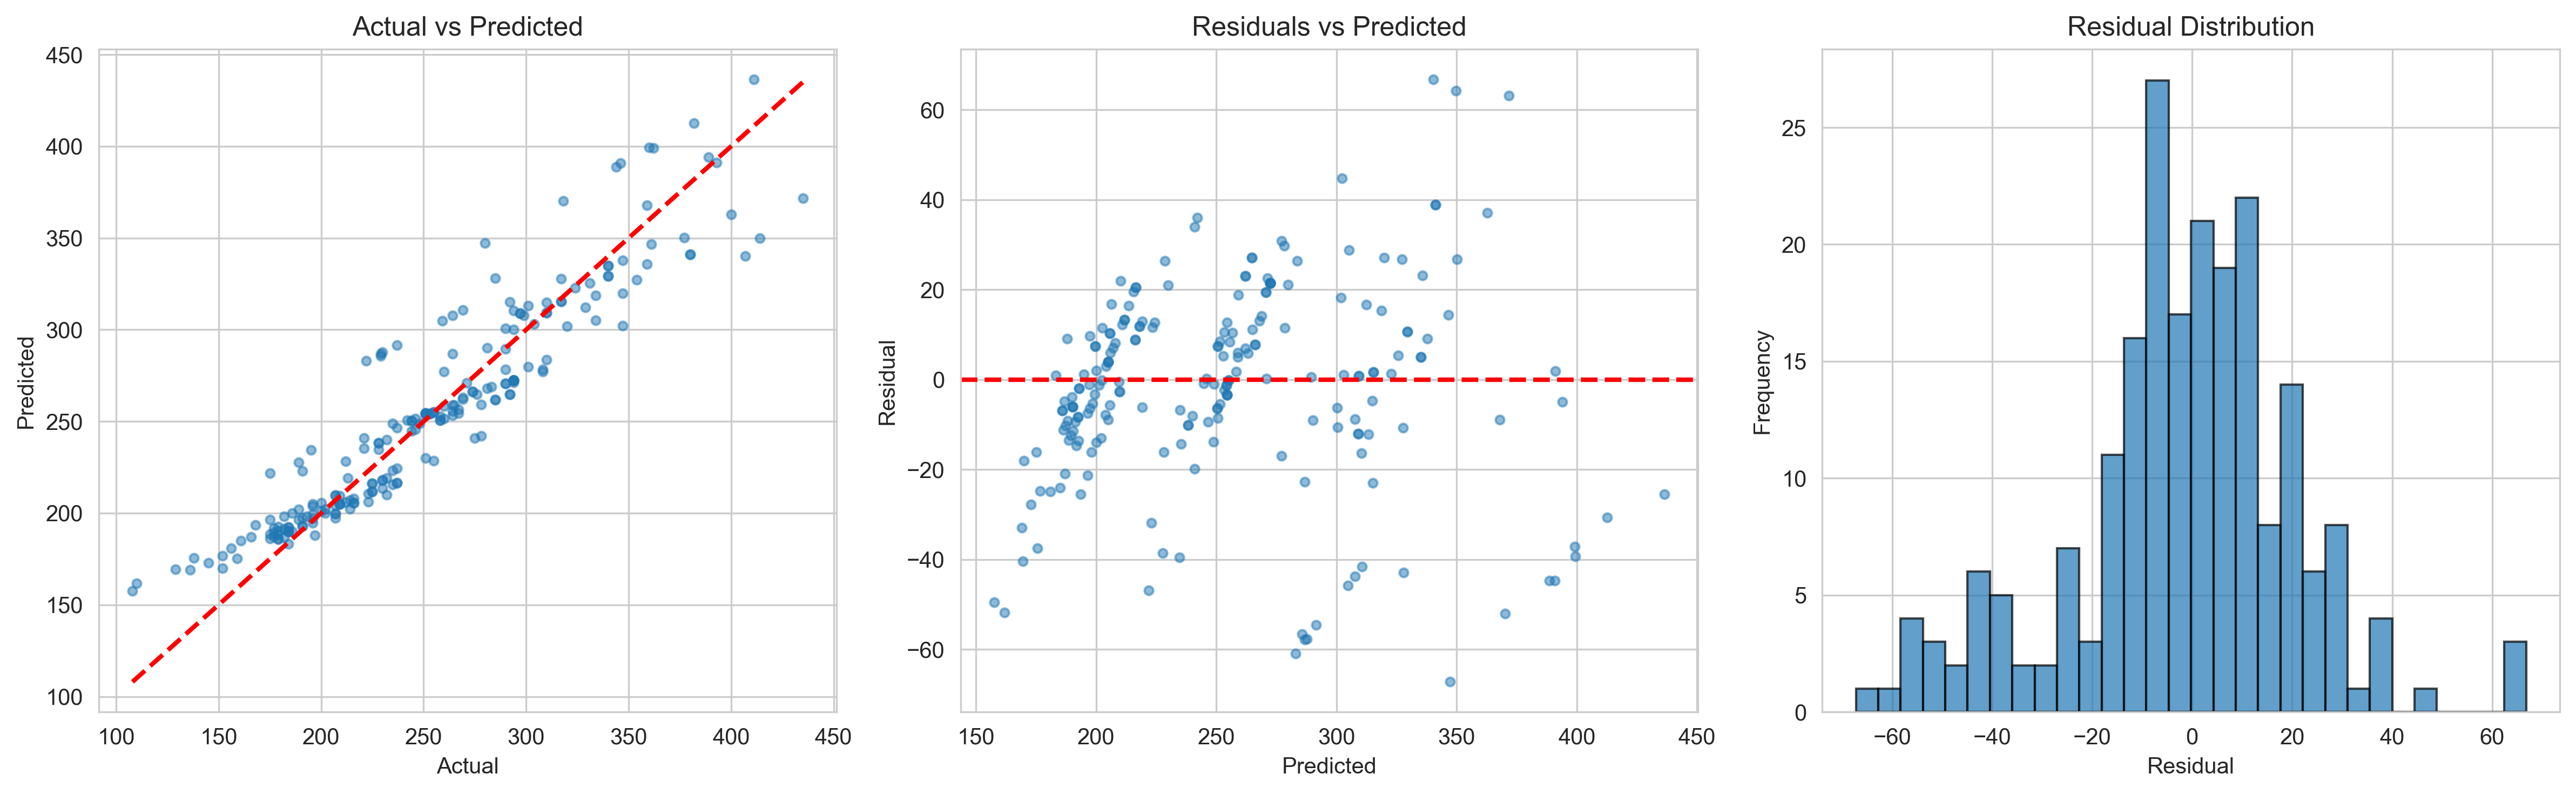

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
residuals = y_test_m - y_pred_multi

# Actual vs Predicted
axes[0].scatter(y_test_m, y_pred_multi, alpha=0.5, s=15)
axes[0].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             'r--', linewidth=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residuals vs Predicted
axes[1].scatter(y_pred_multi, residuals, alpha=0.5, s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

# Residual distribution
axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

**Reading the diagnostic plots:**
- **Actual vs Predicted:** Points close to the red line indicate accurate predictions
- **Residuals vs Predicted:** Random scatter around zero is ideal. Patterns indicate model misspecification
- **Residual Distribution:** Approximately normal (bell-shaped) distribution supports the normality assumption

### Class Activity: 
Train and evaluate a linear regression model using the fuel consumption dataset.
Try adding different features and see how it affects the evaluation metrics. 

In [88]:
# Class Activity: Train and evaluate a linear regression model using the fuel consumption dataset.
# Try adding different features and see how it affects the evaluation metrics. 

# load the dataset
fuel_df = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')
# TODO:Define features and target X and y for the multivariable model


# TODO:Split the data into training and testing sets


# TODO: Define the linear regression model


# TODO: Fit the model to the training data


# TODO: Make predictions on the test set


# TODO: Evaluate the model using MSE, MAE, R-squared


---
## 3. Polynomial Regression

When the relationship between X and y is non-linear, a straight line underfits the data. Polynomial regression adds powers of the features:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

Higher degree polynomials are more flexible, but risk overfitting.

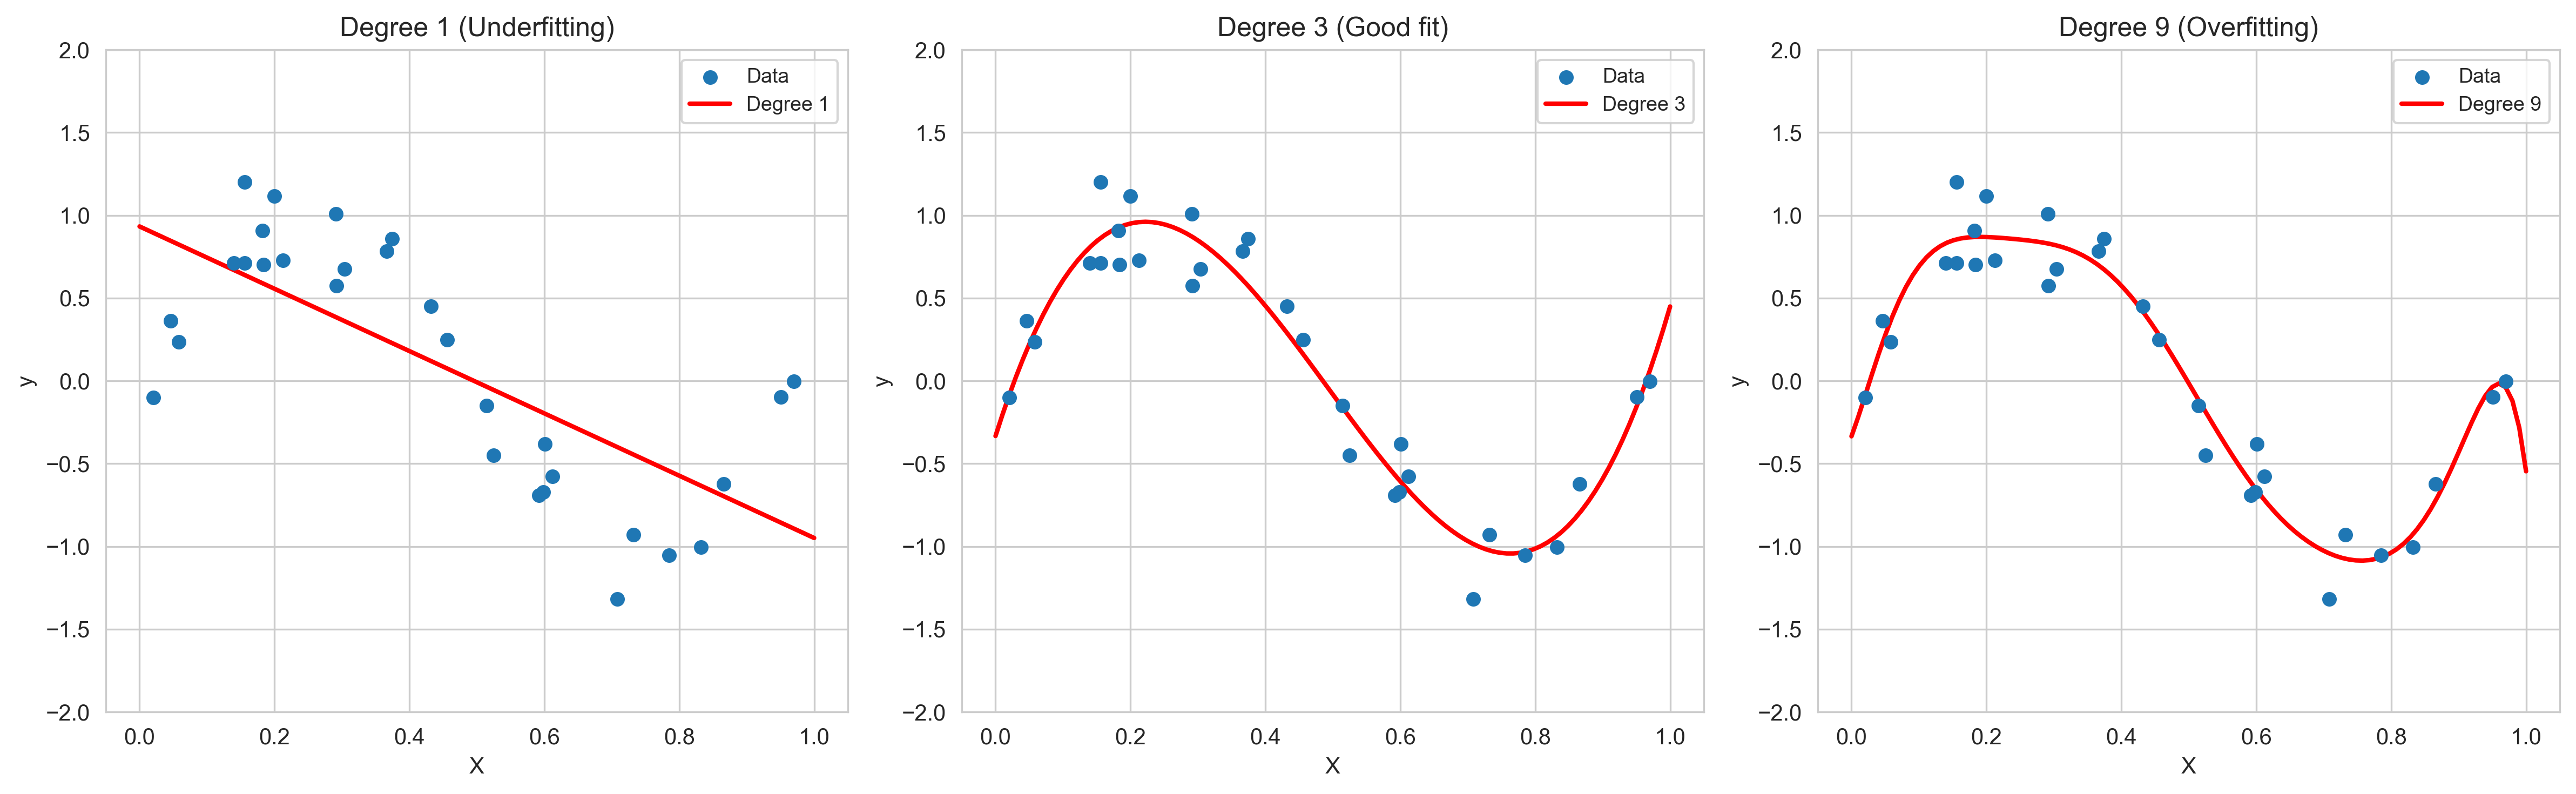

In [89]:
# Generate non-linear data to demonstrate
np.random.seed(42)
X_nl = np.sort(np.random.uniform(0, 1, 30)).reshape(-1, 1)
y_nl = np.sin(2 * np.pi * X_nl).ravel() + np.random.normal(0, 0.2, 30)

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
degrees = [1, 3, 9]
titles = ['Degree 1 (Underfitting)', 'Degree 3 (Good fit)', 'Degree 9 (Overfitting)']

for ax, degree, title in zip(axes, degrees, titles):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X_nl)
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y_nl)

    X_plot_poly = poly.transform(X_plot)
    y_plot = model_poly.predict(X_plot_poly)

    ax.scatter(X_nl, y_nl, s=30, zorder=3, label='Data')
    ax.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Degree {degree}')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Applying Polynomial Regression to Real Data

**Dataset:** `FuelConsumptionCo2.csv.csv` -- does FUELCONSUMPTION_HWY predict CO2 Emission linearly, or is there a non-linear relationship?

In [90]:
# Polynomial Regression: Predicting CO2 from Highway Fuel Consumption

# Load data
fuel_df = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')

X_hwy = fuel_df[['FUELCONSUMPTION_HWY']]
y_co2 = fuel_df['CO2EMISSIONS']

X_tr, X_te, y_tr, y_te = train_test_split(X_hwy, y_co2, test_size=0.2, random_state=42)

# --- Step 1: Linear Regression (degree 1) ---
model_linear = LinearRegression()
model_linear.fit(X_tr, y_tr)
r2_linear = model_linear.score(X_te, y_te)
print(f'Linear R²: {r2_linear:.4f}')

# --- Step 2: Polynomial Regression (degree 2) ---
poly = PolynomialFeatures(degree=2)
X_tr_poly = poly.fit_transform(X_tr)
X_te_poly = poly.transform(X_te)

print(f'\nOriginal features: {X_tr.shape[1]} column  -> {list(X_tr.columns)}')
print(f'Polynomial features: {X_tr_poly.shape[1]} columns -> {poly.get_feature_names_out()}')

model_poly = LinearRegression()
model_poly.fit(X_tr_poly, y_tr)
r2_poly = model_poly.score(X_te_poly, y_te)
print(f'\nPolynomial R²: {r2_poly:.4f}')



Linear R²: 0.7518

Original features: 1 column  -> ['FUELCONSUMPTION_HWY']
Polynomial features: 3 columns -> ['1' 'FUELCONSUMPTION_HWY' 'FUELCONSUMPTION_HWY^2']

Polynomial R²: 0.8481


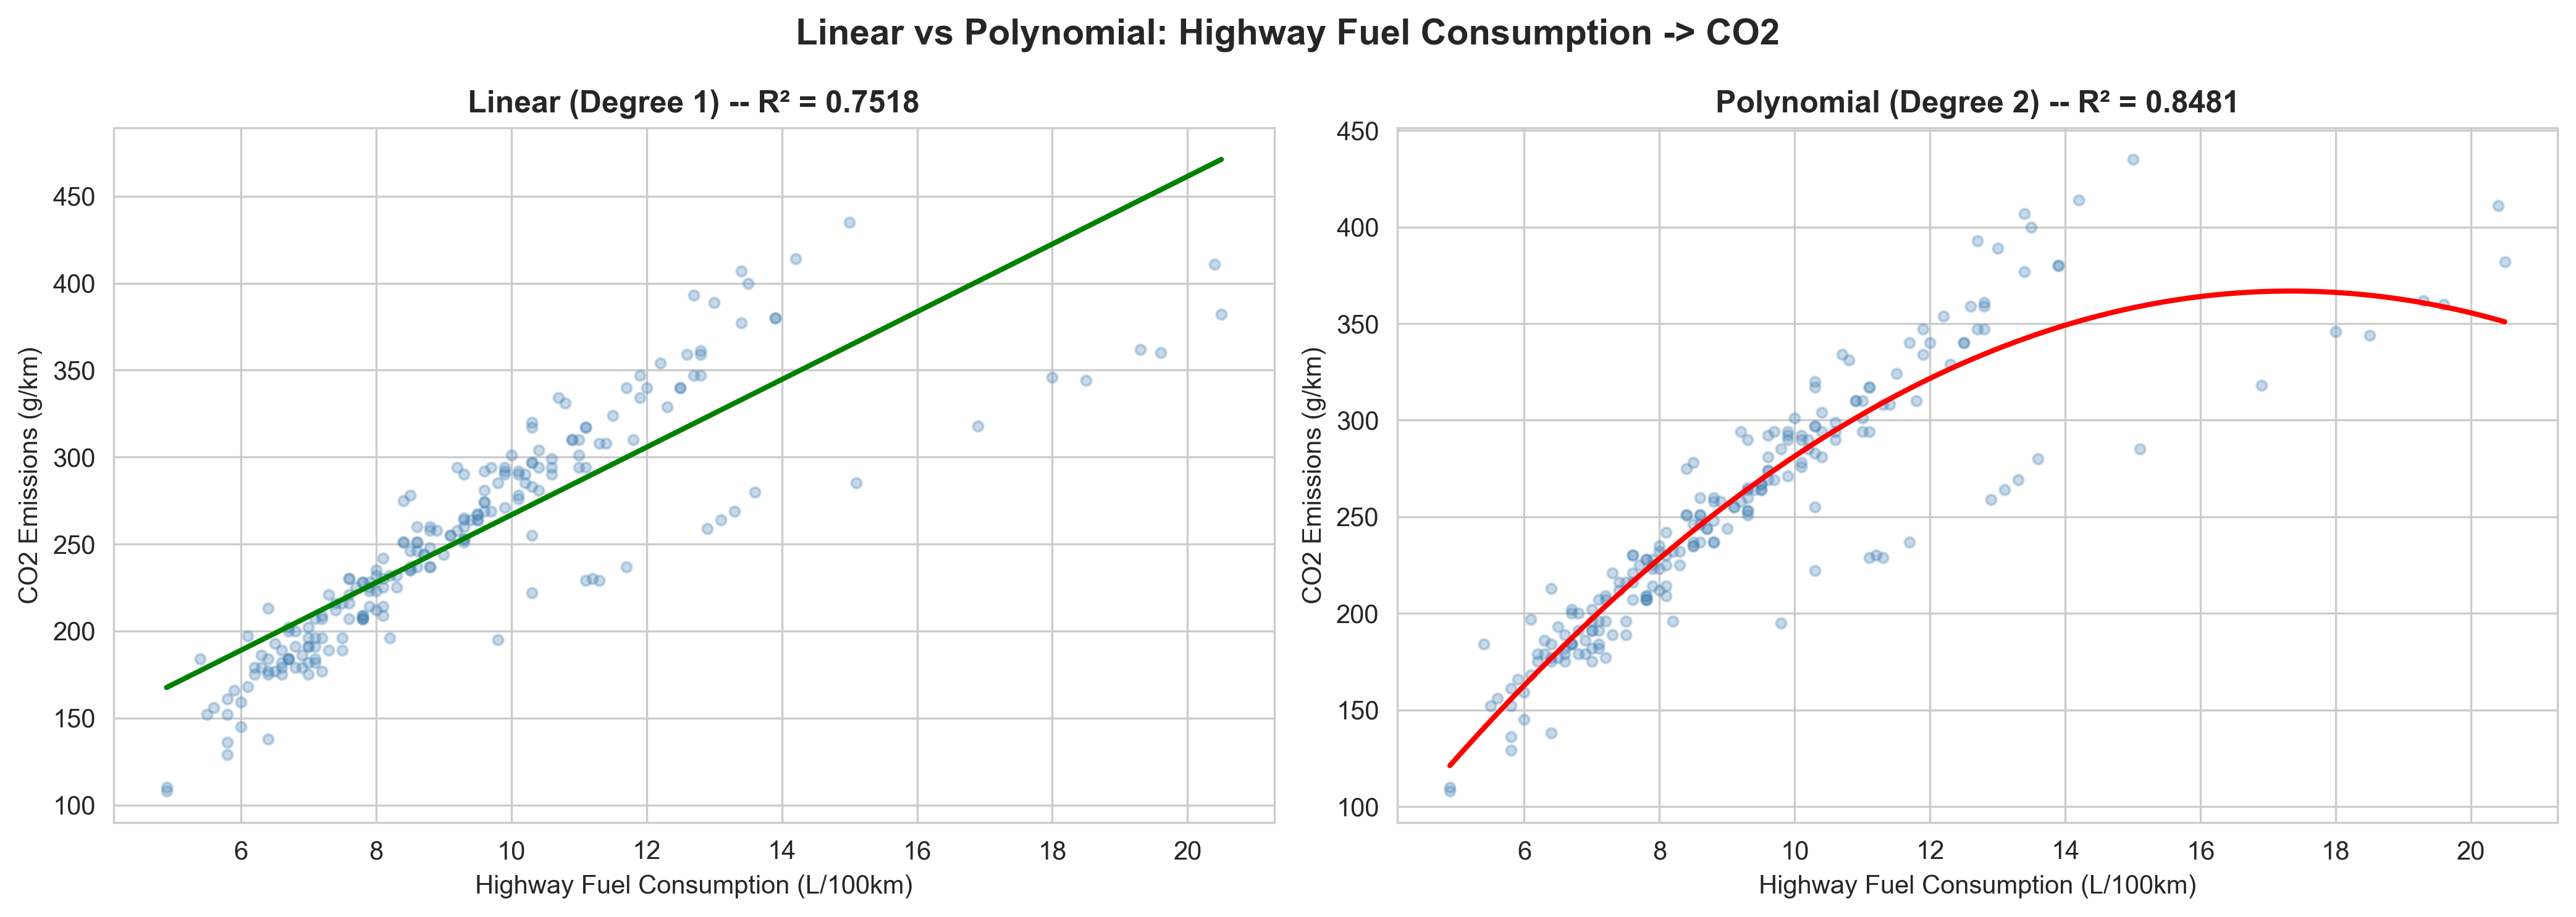

Linear R²:     0.7518
Polynomial R²: 0.8481

The polynomial curve captures the non-linear pattern that the straight line misses.


In [91]:
# Visualize: Linear vs Polynomial Fit
x_vals = np.linspace(X_hwy.values.min(), X_hwy.values.max(), 300).reshape(-1, 1)
X_range = pd.DataFrame(x_vals, columns=['FUELCONSUMPTION_HWY'])
X_range_poly = poly.transform(X_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear fit
axes[0].scatter(X_te.values, y_te.values, alpha=0.3, s=15, color='steelblue')
axes[0].plot(x_vals, model_linear.predict(X_range), color='green', linewidth=2)
axes[0].set_title(f'Linear (Degree 1) -- R² = {r2_linear:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Highway Fuel Consumption (L/100km)')
axes[0].set_ylabel('CO2 Emissions (g/km)')

# Polynomial fit
axes[1].scatter(X_te.values, y_te.values, alpha=0.3, s=15, color='steelblue')
axes[1].plot(x_vals, model_poly.predict(X_range_poly), color='red', linewidth=2)
axes[1].set_title(f'Polynomial (Degree 2) -- R² = {r2_poly:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Highway Fuel Consumption (L/100km)')
axes[1].set_ylabel('CO2 Emissions (g/km)')

plt.suptitle('Linear vs Polynomial: Highway Fuel Consumption -> CO2',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Linear R²:     {r2_linear:.4f}')
print(f'Polynomial R²: {r2_poly:.4f}')
print(f'\nThe polynomial curve captures the non-linear pattern that the straight line misses.')


In [ ]:
# Class Activity: Train and evaluate a polynomial regression model using the fuel consumption dataset.
# Try adding different features and see how it affects the evaluation metrics. 
# Try different polynomial degrees and see how it affects the fit and evaluation metrics.

# load the dataset
fuel_df = pd.read_csv('../../Datasets/FuelConsumptionCo2.csv')
# TODO:Define features and target X and y for the multivariable model


# TODO:Split the data into training and testing sets


# TODO: transform the features into polynomial features
X_tr_poly = poly.fit_transform(X_tr)
X_te_poly = poly.transform(X_te)


# TODO: Define the polynomial regression model
model_poly = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_regression', LinearRegression())
])


# TODO: Fit the model to the training data


# TODO: Make predictions on the test set


# TODO: Evaluate the model using MSE, MAE, R-squared


---
## 4. Bias-Variance Tradeoff

The total prediction error decomposes into three components:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Component | High when... | Result |
|-----------|-------------|--------|
| **Bias** | Model is too simple | Underfitting -- misses the true pattern |
| **Variance** | Model is too complex | Overfitting -- fits noise in training data |
| **Noise** | Data is inherently noisy | Cannot be reduced by any model |

The goal is to find the sweet spot: complex enough to capture the pattern, simple enough to generalize.

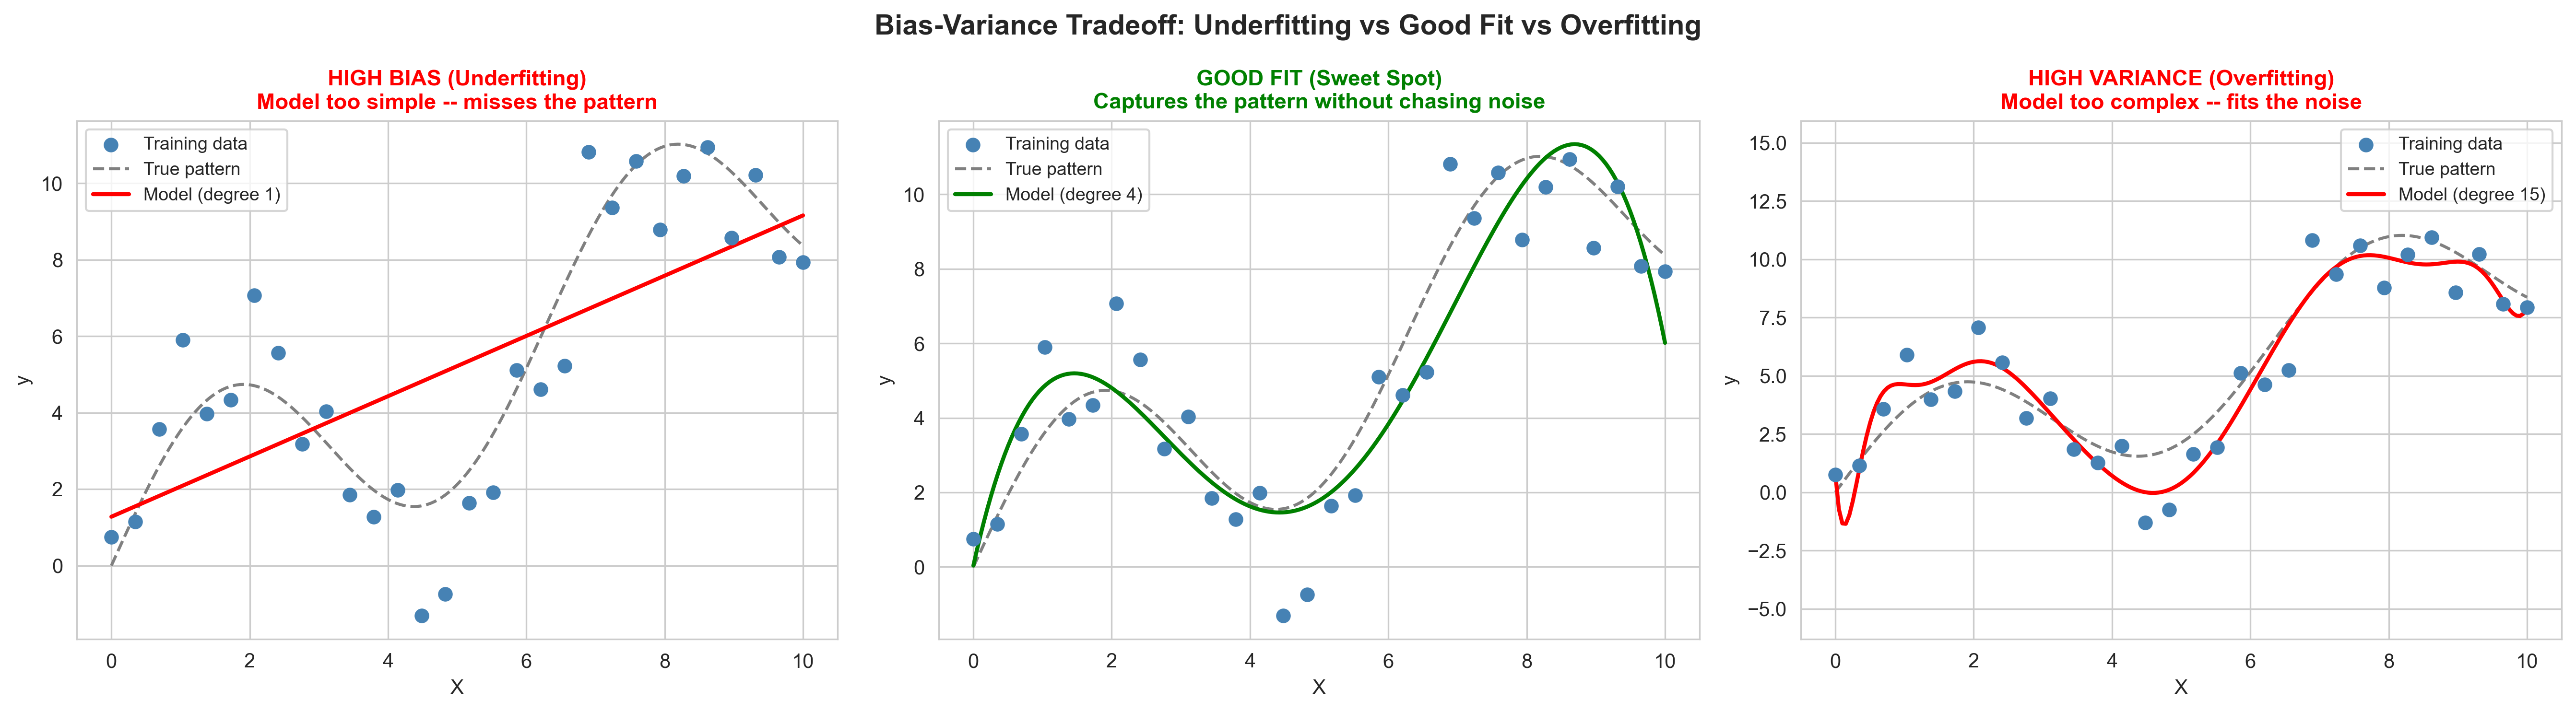

HIGH BIAS (Underfitting):  Model is too simple (straight line for curved data)
                           -> Misses the real pattern, bad on BOTH train and test

GOOD FIT (Sweet Spot):     Model complexity matches the data
                           -> Captures the pattern, good on BOTH train and test

HIGH VARIANCE (Overfitting): Model is too complex (wiggly curve chasing every point)
                           -> Perfect on training data, terrible on new/test data

IRREDUCIBLE NOISE:         The scatter around the true pattern (gray dashed line)
                           -> No model can remove this -- it is randomness in the data


In [92]:
# Bias-Variance Tradeoff: Visual Examples
np.random.seed(42)

# Generate true pattern (a curve) + noise
x = np.linspace(0, 10, 30)
y_true_pattern = np.sin(x) * 3 + x  # the real underlying pattern
y_noisy = y_true_pattern + np.random.normal(0, 1.5, len(x))  # what we observe

# Smooth x for plotting curves
x_smooth = np.linspace(0, 10, 200)
y_true_smooth = np.sin(x_smooth) * 3 + x_smooth

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- HIGH BIAS (Underfitting): Too simple - just a straight line ---
coeffs_1 = np.polyfit(x, y_noisy, 1)
y_underfit = np.polyval(coeffs_1, x_smooth)

axes[0].scatter(x, y_noisy, s=40, color='steelblue', zorder=5, label='Training data')
axes[0].plot(x_smooth, y_true_smooth, color='gray', linewidth=1.5, linestyle='--', label='True pattern')
axes[0].plot(x_smooth, y_underfit, color='red', linewidth=2, label='Model (degree 1)')
axes[0].set_title('HIGH BIAS (Underfitting)\nModel too simple -- misses the pattern',
                  fontsize=11, fontweight='bold', color='red')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=9)

# --- GOOD FIT (Sweet spot): Right complexity ---
coeffs_3 = np.polyfit(x, y_noisy, 4)
y_goodfit = np.polyval(coeffs_3, x_smooth)

axes[1].scatter(x, y_noisy, s=40, color='steelblue', zorder=5, label='Training data')
axes[1].plot(x_smooth, y_true_smooth, color='gray', linewidth=1.5, linestyle='--', label='True pattern')
axes[1].plot(x_smooth, y_goodfit, color='green', linewidth=2, label='Model (degree 4)')
axes[1].set_title('GOOD FIT (Sweet Spot)\nCaptures the pattern without chasing noise',
                  fontsize=11, fontweight='bold', color='green')
axes[1].set_xlabel('X')
axes[1].set_ylabel('y')
axes[1].legend(fontsize=9)

# --- HIGH VARIANCE (Overfitting): Too complex - fits every data point ---
coeffs_20 = np.polyfit(x, y_noisy, 15)
y_overfit = np.polyval(coeffs_20, x_smooth)

axes[2].scatter(x, y_noisy, s=40, color='steelblue', zorder=5, label='Training data')
axes[2].plot(x_smooth, y_true_smooth, color='gray', linewidth=1.5, linestyle='--', label='True pattern')
axes[2].plot(x_smooth, y_overfit, color='red', linewidth=2, label='Model (degree 15)')
axes[2].set_ylim(min(y_noisy) - 5, max(y_noisy) + 5)
axes[2].set_title('HIGH VARIANCE (Overfitting)\nModel too complex -- fits the noise',
                  fontsize=11, fontweight='bold', color='red')
axes[2].set_xlabel('X')
axes[2].set_ylabel('y')
axes[2].legend(fontsize=9)

plt.suptitle('Bias-Variance Tradeoff: Underfitting vs Good Fit vs Overfitting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('HIGH BIAS (Underfitting):  Model is too simple (straight line for curved data)')
print('                           -> Misses the real pattern, bad on BOTH train and test\n')
print('GOOD FIT (Sweet Spot):     Model complexity matches the data')
print('                           -> Captures the pattern, good on BOTH train and test\n')
print('HIGH VARIANCE (Overfitting): Model is too complex (wiggly curve chasing every point)')
print('                           -> Perfect on training data, terrible on new/test data\n')
print('IRREDUCIBLE NOISE:         The scatter around the true pattern (gray dashed line)')
print('                           -> No model can remove this -- it is randomness in the data')


### Visualizing the Tradeoff

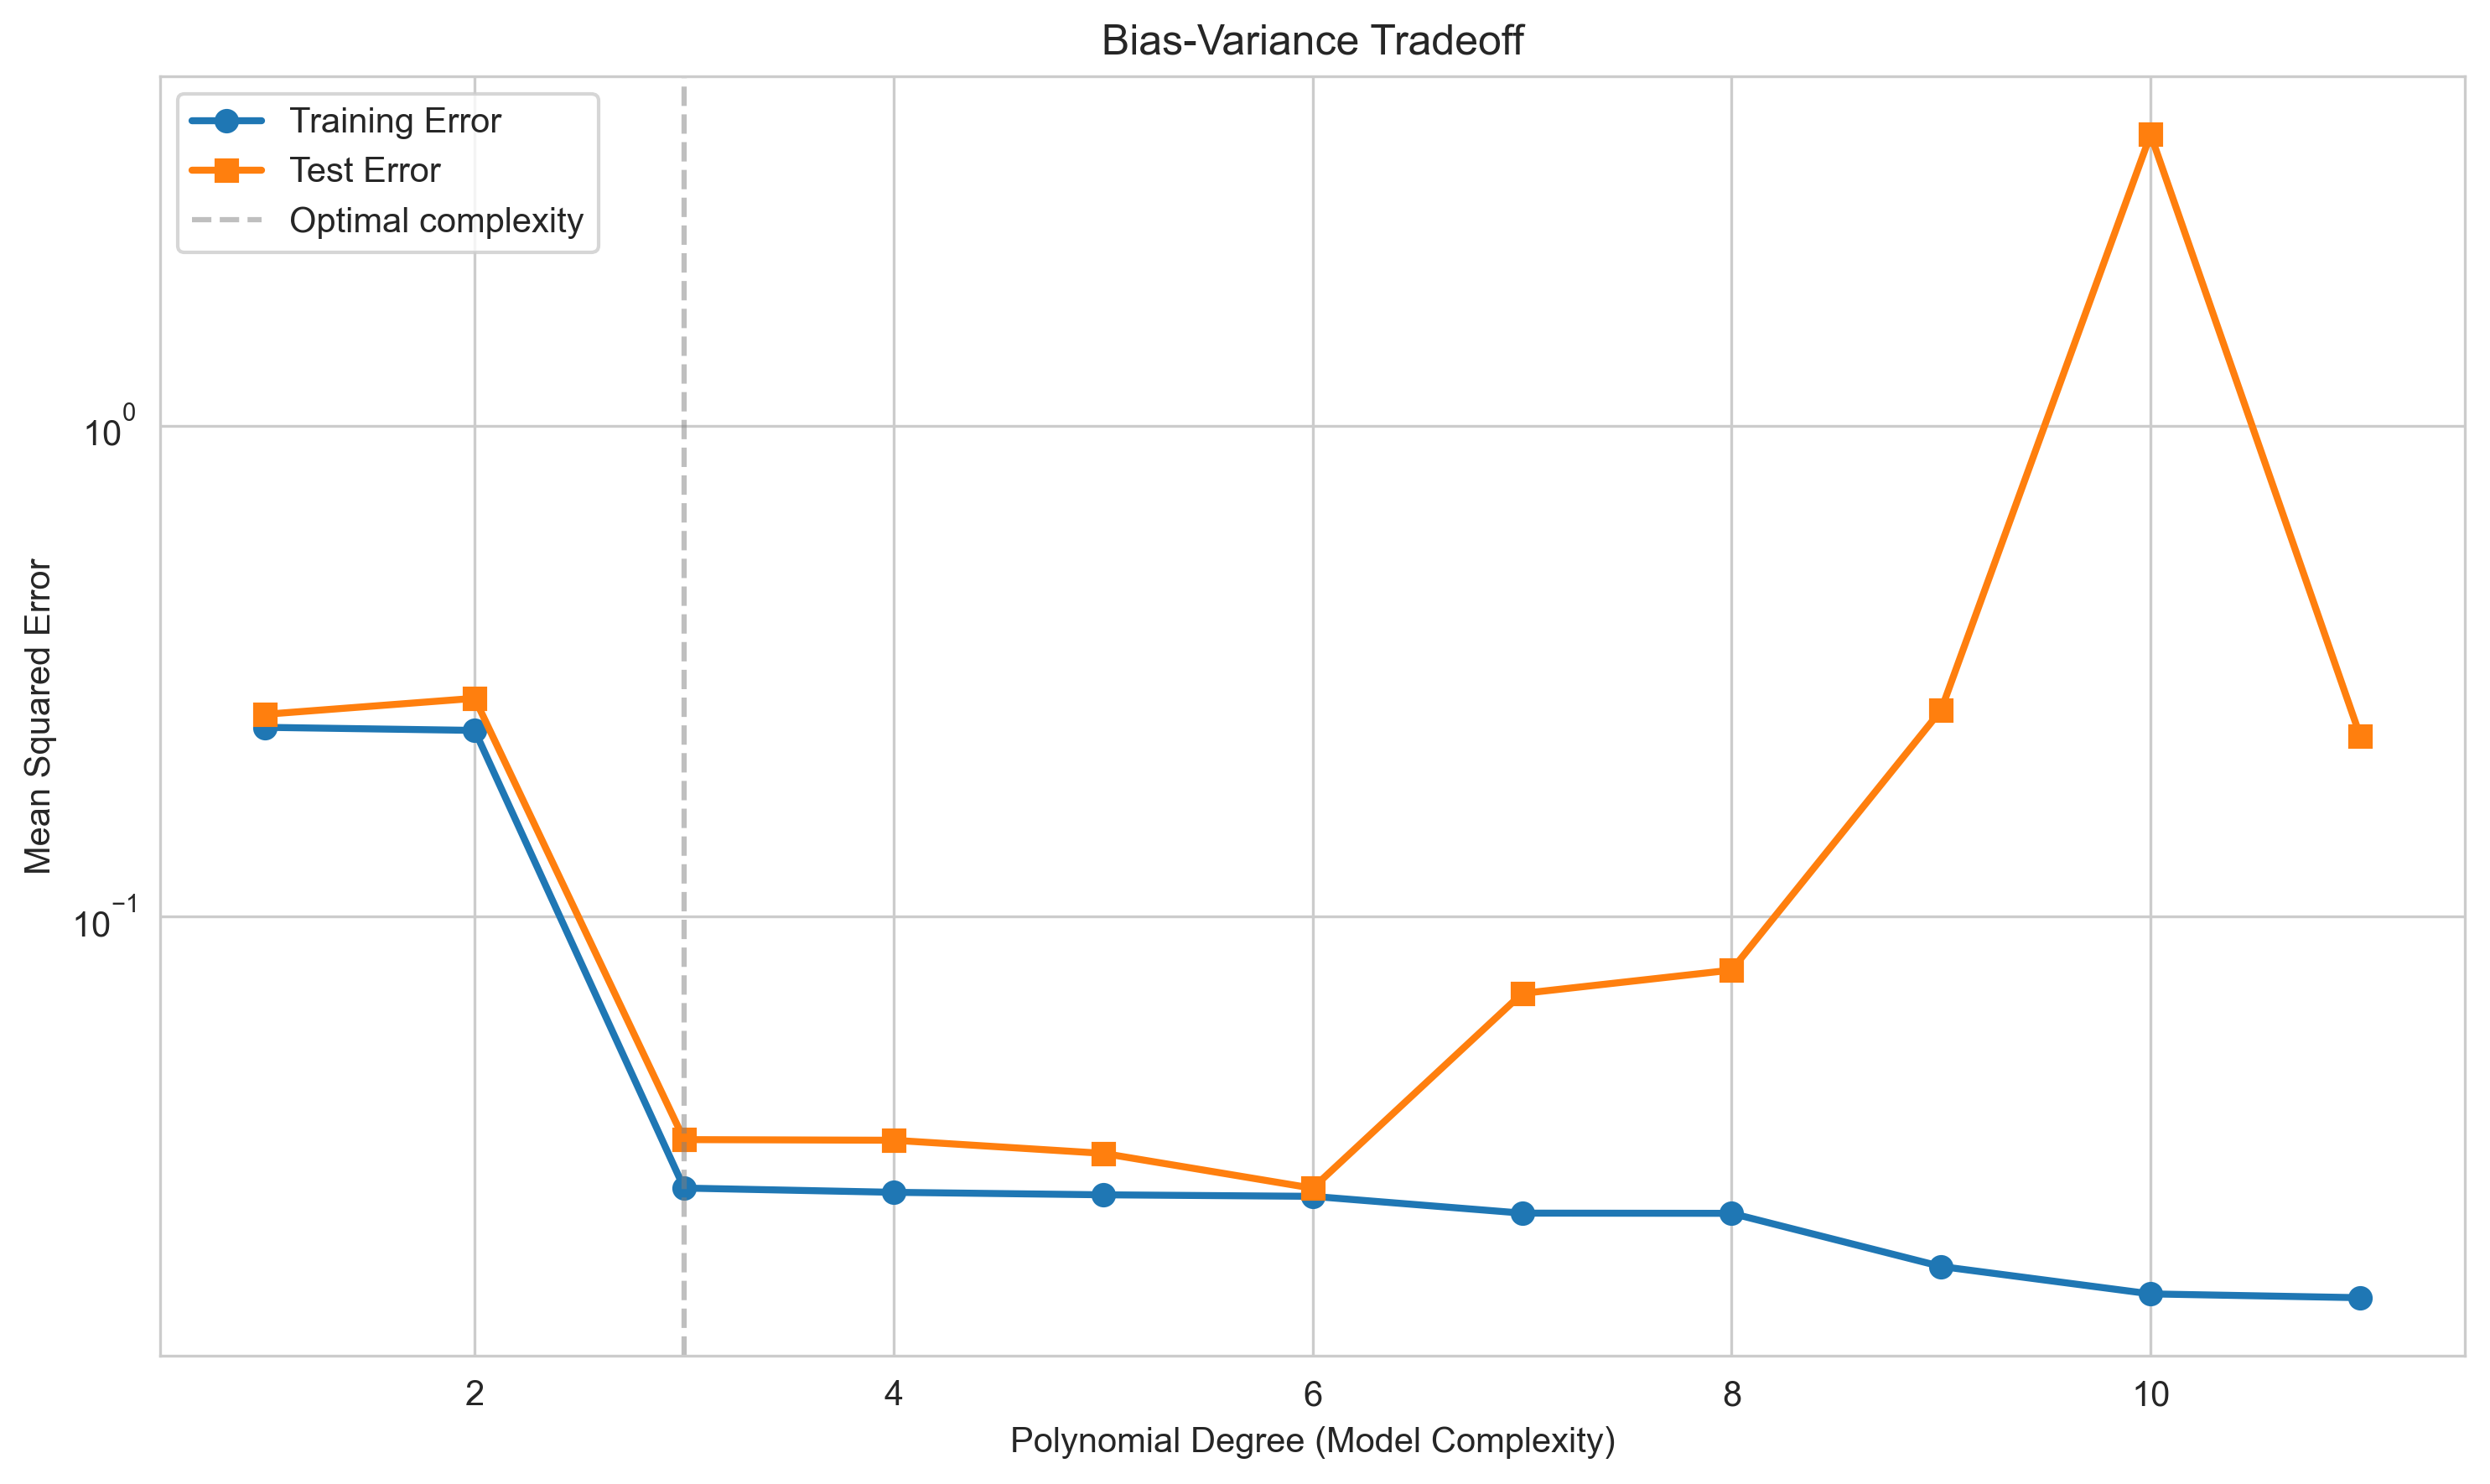

As complexity increases:
  - Training error always decreases (model fits training data better)
  - Test error decreases then increases (overfitting kicks in)


In [93]:
# Train and test error vs polynomial degree
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_nl, y_nl, test_size=0.3, random_state=42
)

degrees_range = range(1, 12)
train_errors = []
test_errors = []

for d in degrees_range:
    poly = PolynomialFeatures(d)
    X_tr_p = poly.fit_transform(X_train_nl)
    X_te_p = poly.transform(X_test_nl)

    m = LinearRegression()
    m.fit(X_tr_p, y_train_nl)

    train_errors.append(mean_squared_error(y_train_nl, m.predict(X_tr_p)))
    test_errors.append(mean_squared_error(y_test_nl, m.predict(X_te_p)))

plt.figure(figsize=(10, 6))
plt.plot(list(degrees_range), train_errors, 'o-', label='Training Error', linewidth=2)
plt.plot(list(degrees_range), test_errors, 's-', label='Test Error', linewidth=2)
plt.axvline(x=3, color='gray', linestyle='--', alpha=0.5, label='Optimal complexity')
plt.xlabel('Polynomial Degree (Model Complexity)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

print('As complexity increases:')
print('  - Training error always decreases (model fits training data better)')
print('  - Test error decreases then increases (overfitting kicks in)')

### Cross-Validation

Cross-validation provides a more robust estimate of model performance by splitting the data into multiple folds.

In [94]:
# 5-fold cross-validation on the FuelConsumption data
X_cv = fuel_df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y_cv = fuel_df['CO2EMISSIONS']

model_cv = LinearRegression()
cv_scores = cross_val_score(model_cv, X_cv, y_cv, cv=5, scoring='r2')

print('5-Fold Cross-Validation Results:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R2 = {score:.4f}')
print(f'\n  Mean R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'\nA small standard deviation indicates consistent performance across folds.')

5-Fold Cross-Validation Results:
  Fold 1: R2 = 0.8805
  Fold 2: R2 = 0.7691
  Fold 3: R2 = 0.8196
  Fold 4: R2 = 0.8849
  Fold 5: R2 = 0.8956

  Mean R2: 0.8499 (+/- 0.0484)

A small standard deviation indicates consistent performance across folds.


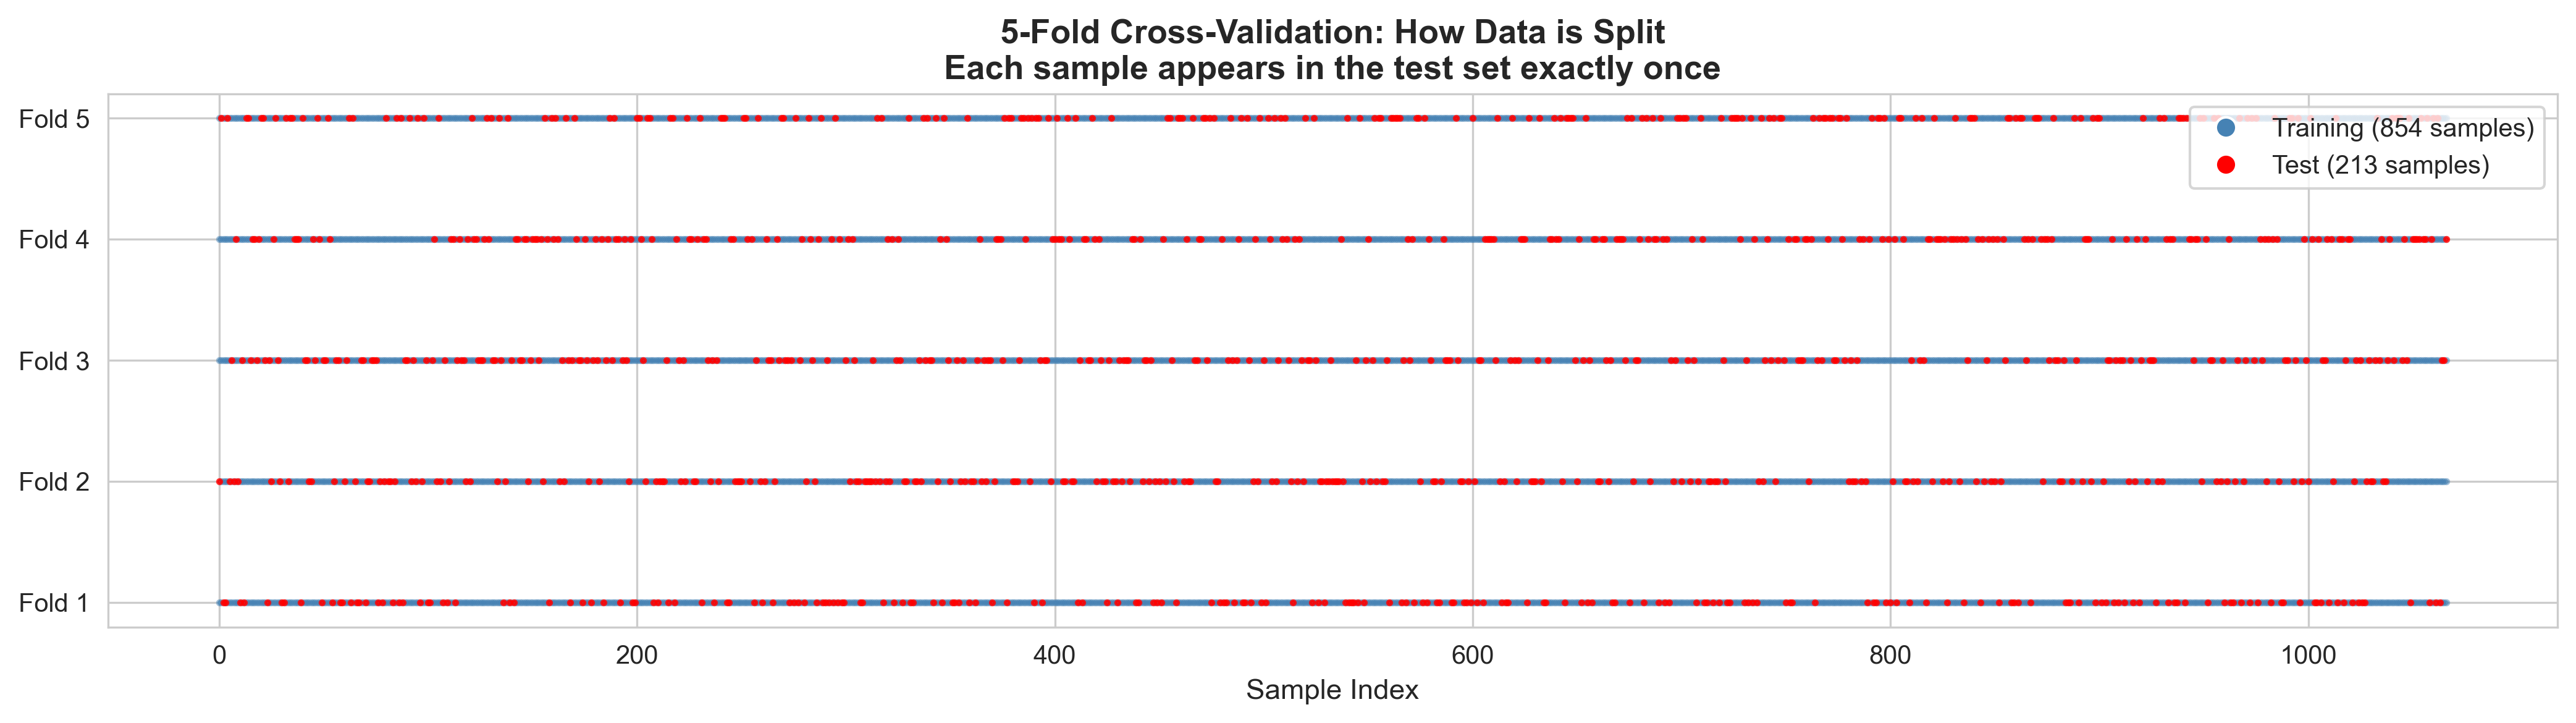

Total samples: 1067
Each fold: ~854 train, ~213 test
Every sample gets used as test data exactly once.


In [95]:
# How 5-Fold Cross-Validation Splits the Data
from sklearn.model_selection import KFold

n_samples = len(X_cv)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))

for i, (train_idx, test_idx) in enumerate(kf.split(X_cv)):
    # Plot training indices as blue bars
    ax.scatter(train_idx, [i + 1] * len(train_idx), s=3, color='steelblue', alpha=0.5)
    # Plot test indices as red bars
    ax.scatter(test_idx, [i + 1] * len(test_idx), s=3, color='red', alpha=0.8)

ax.set_yticks(range(1, 6))
ax.set_yticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_title('5-Fold Cross-Validation: How Data is Split\nEach sample appears in the test set exactly once',
             fontsize=13, fontweight='bold')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                          markersize=8, label=f'Training ({n_samples - n_samples//5} samples)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
                          markersize=8, label=f'Test ({n_samples//5} samples)')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Total samples: {n_samples}')
print(f'Each fold: ~{n_samples - n_samples//5} train, ~{n_samples//5} test')
print(f'Every sample gets used as test data exactly once.')


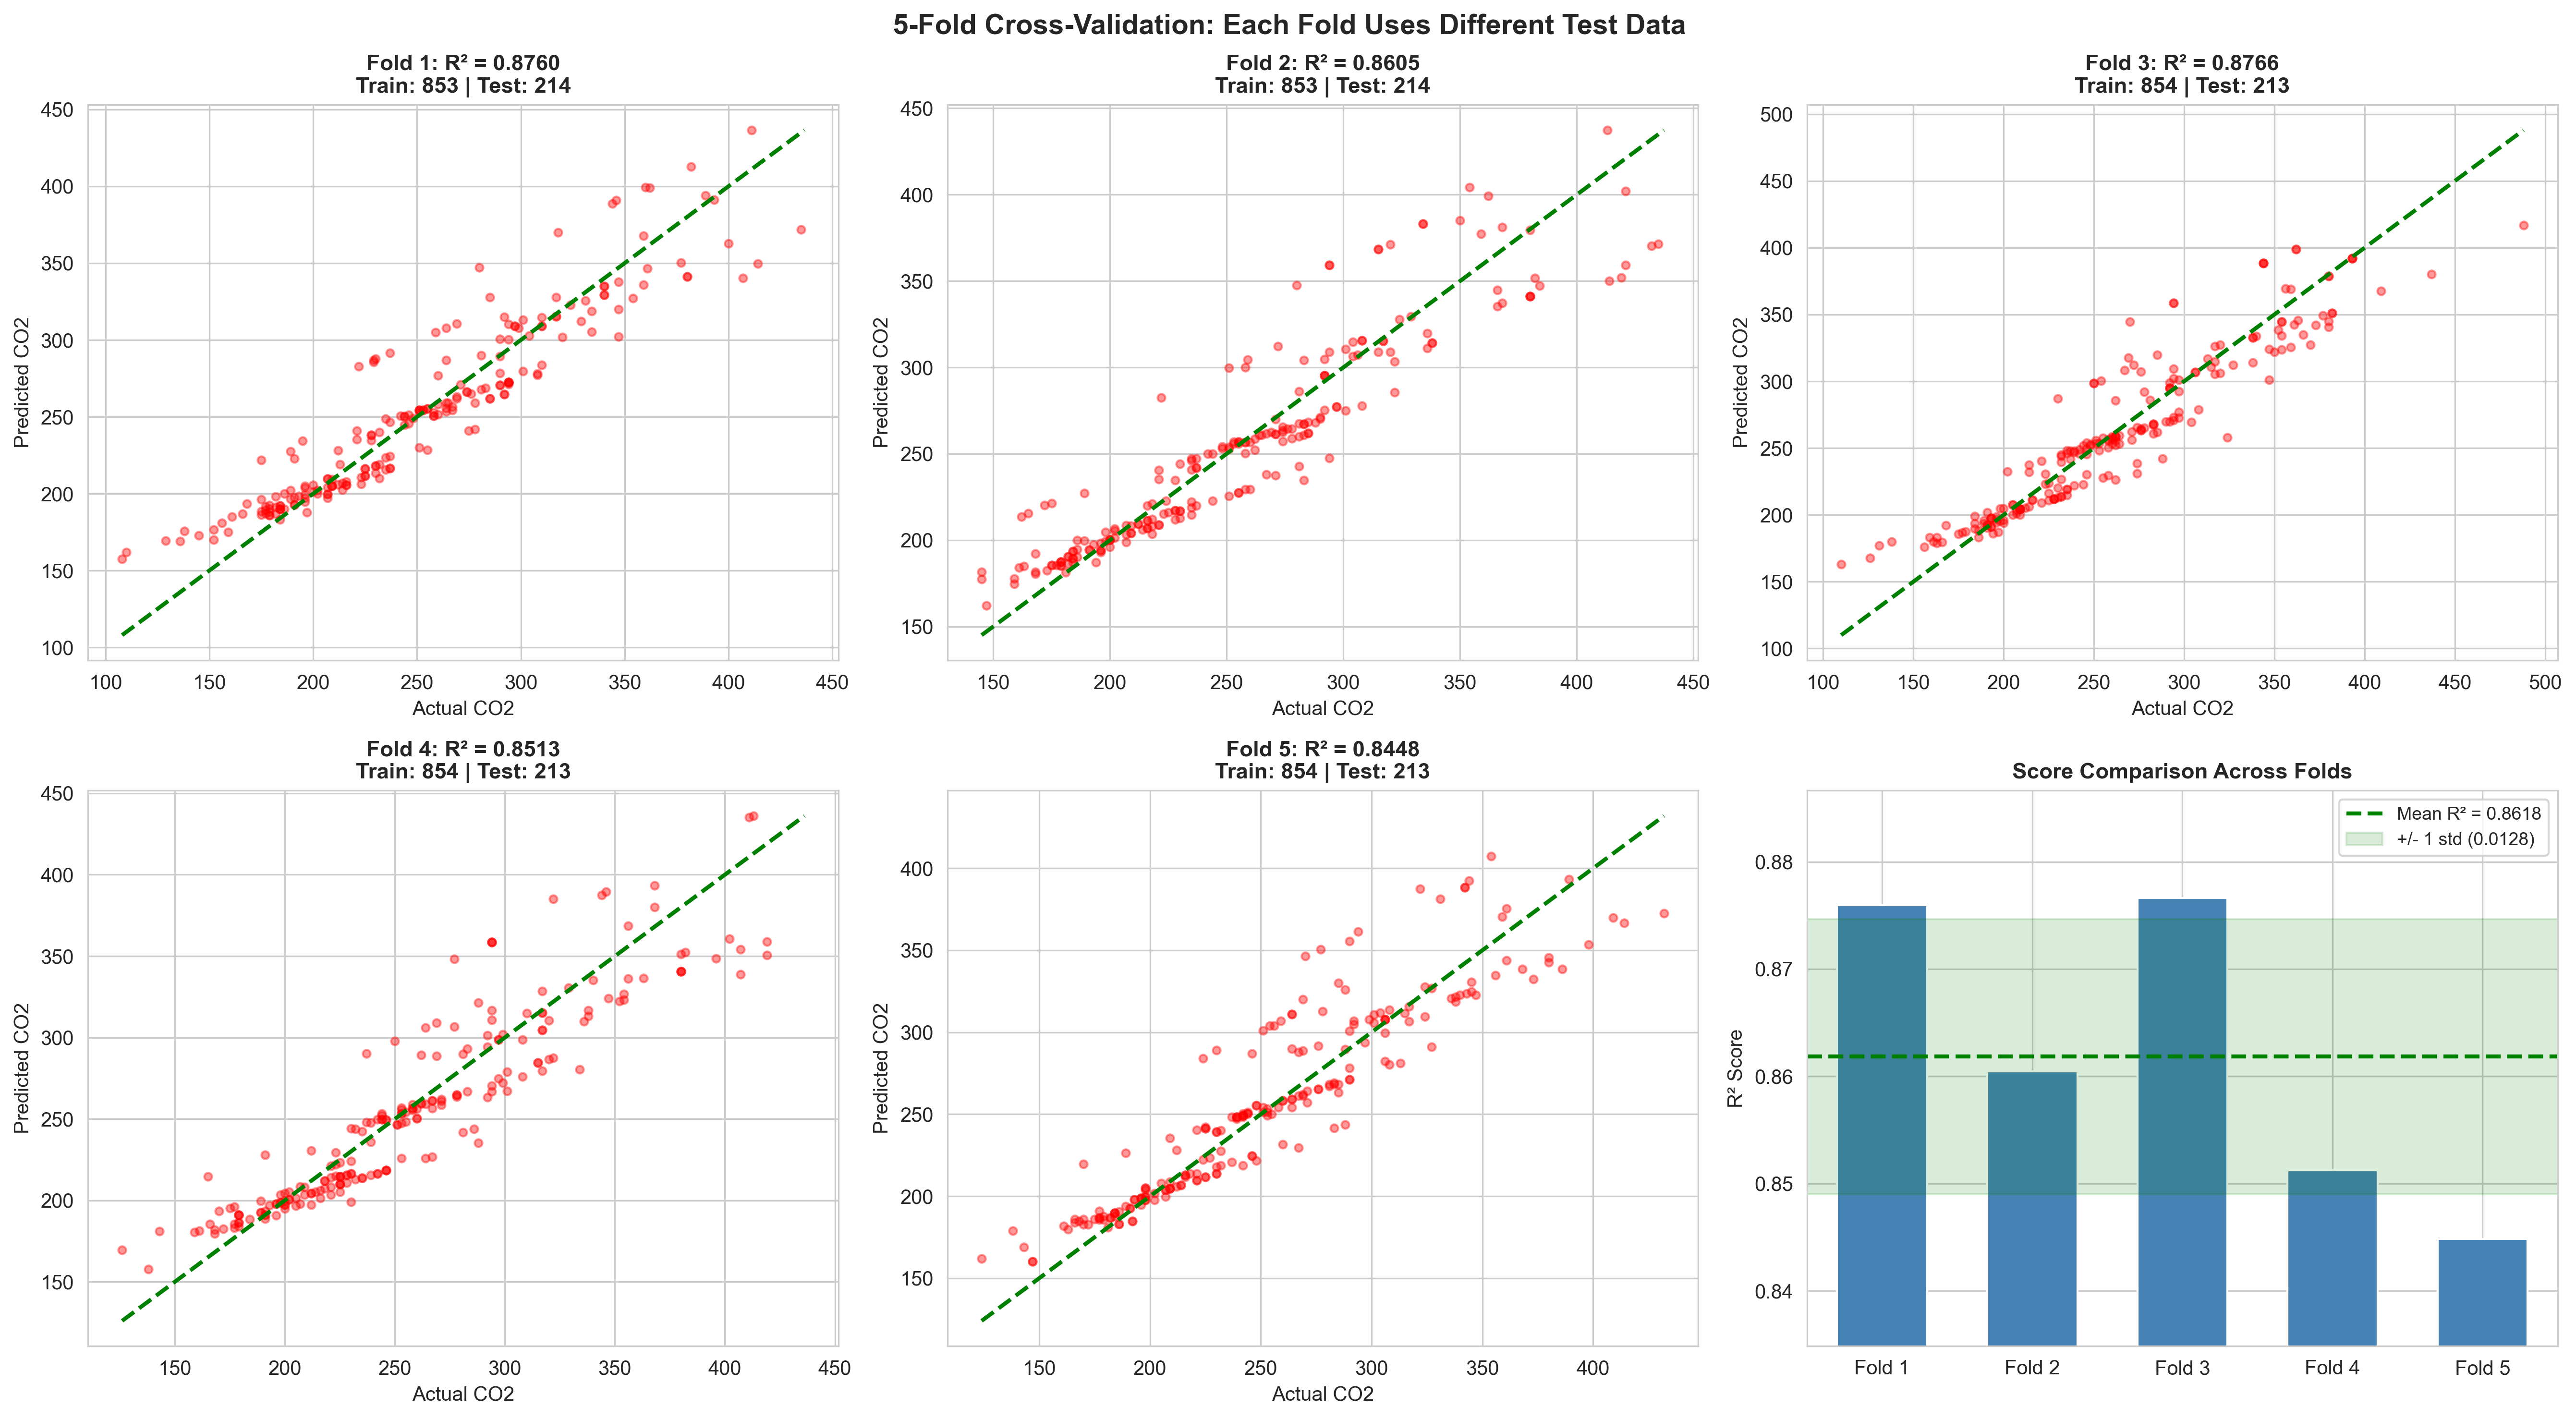

Mean R²: 0.8618 (+/- 0.0128)

Consistent scores across folds = model generalizes well.
Large variation across folds = model may be unstable.


In [96]:
# 5-Fold Cross-Validation: Visualized
from sklearn.model_selection import KFold

X_cv = fuel_df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB']]
y_cv = fuel_df['CO2EMISSIONS']

model_cv = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig = plt.figure(figsize=(18, 10))

fold_scores = []

# --- Top row: Actual vs Predicted for each fold ---
for i, (train_idx, test_idx) in enumerate(kf.split(X_cv)):
    ax = fig.add_subplot(2, 3, i + 1)

    X_train_fold = X_cv.iloc[train_idx]
    X_test_fold = X_cv.iloc[test_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_test_fold = y_cv.iloc[test_idx]

    model_cv.fit(X_train_fold, y_train_fold)
    y_pred_fold = model_cv.predict(X_test_fold)
    r2 = model_cv.score(X_test_fold, y_test_fold)
    fold_scores.append(r2)

    ax.scatter(y_test_fold, y_pred_fold, alpha=0.4, s=15, color='red')
    min_val = min(y_test_fold.min(), y_pred_fold.min())
    max_val = max(y_test_fold.max(), y_pred_fold.max())
    ax.plot([min_val, max_val], [min_val, max_val], color='green', linewidth=2, linestyle='--')
    ax.set_title(f'Fold {i+1}: R² = {r2:.4f}\nTrain: {len(train_idx)} | Test: {len(test_idx)}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual CO2')
    ax.set_ylabel('Predicted CO2')

# --- Bottom right: Summary bar chart ---
ax_bar = fig.add_subplot(2, 3, 6)
fold_nums = [f'Fold {i+1}' for i in range(5)]
ax_bar.bar(fold_nums, fold_scores, color='steelblue', edgecolor='white', width=0.6)
ax_bar.axhline(y=np.mean(fold_scores), color='green', linewidth=2, linestyle='--',
               label=f'Mean R² = {np.mean(fold_scores):.4f}')
ax_bar.fill_between(range(-1, 6),
                     np.mean(fold_scores) - np.std(fold_scores),
                     np.mean(fold_scores) + np.std(fold_scores),
                     alpha=0.15, color='green', label=f'+/- 1 std ({np.std(fold_scores):.4f})')
ax_bar.set_xlim(-0.5, 4.5)
ax_bar.set_ylim(min(fold_scores) - 0.01, max(fold_scores) + 0.01)
ax_bar.set_title('Score Comparison Across Folds', fontsize=11, fontweight='bold')
ax_bar.set_ylabel('R² Score')
ax_bar.legend(fontsize=9)

plt.suptitle('5-Fold Cross-Validation: Each Fold Uses Different Test Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean R²: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})')
print(f'\nConsistent scores across folds = model generalizes well.')
print(f'Large variation across folds = model may be unstable.')


---
## 5. Regularization

Regularization adds a penalty term to the cost function to constrain model complexity and reduce overfitting.

| Method | Penalty | Effect |
|--------|---------|--------|
| **Ridge (L2)** | $\lambda \sum \beta_j^2$ | Shrinks coefficients toward zero but keeps all features |
| **Lasso (L1)** | $\lambda \sum |\beta_j|$ | Drives some coefficients exactly to zero (feature selection) |

The hyperparameter $\lambda$ (called `alpha` in scikit-learn) controls the strength of regularization:
- $\lambda = 0$: No regularization (ordinary least squares)
- Large $\lambda$: Strong regularization (simpler model)

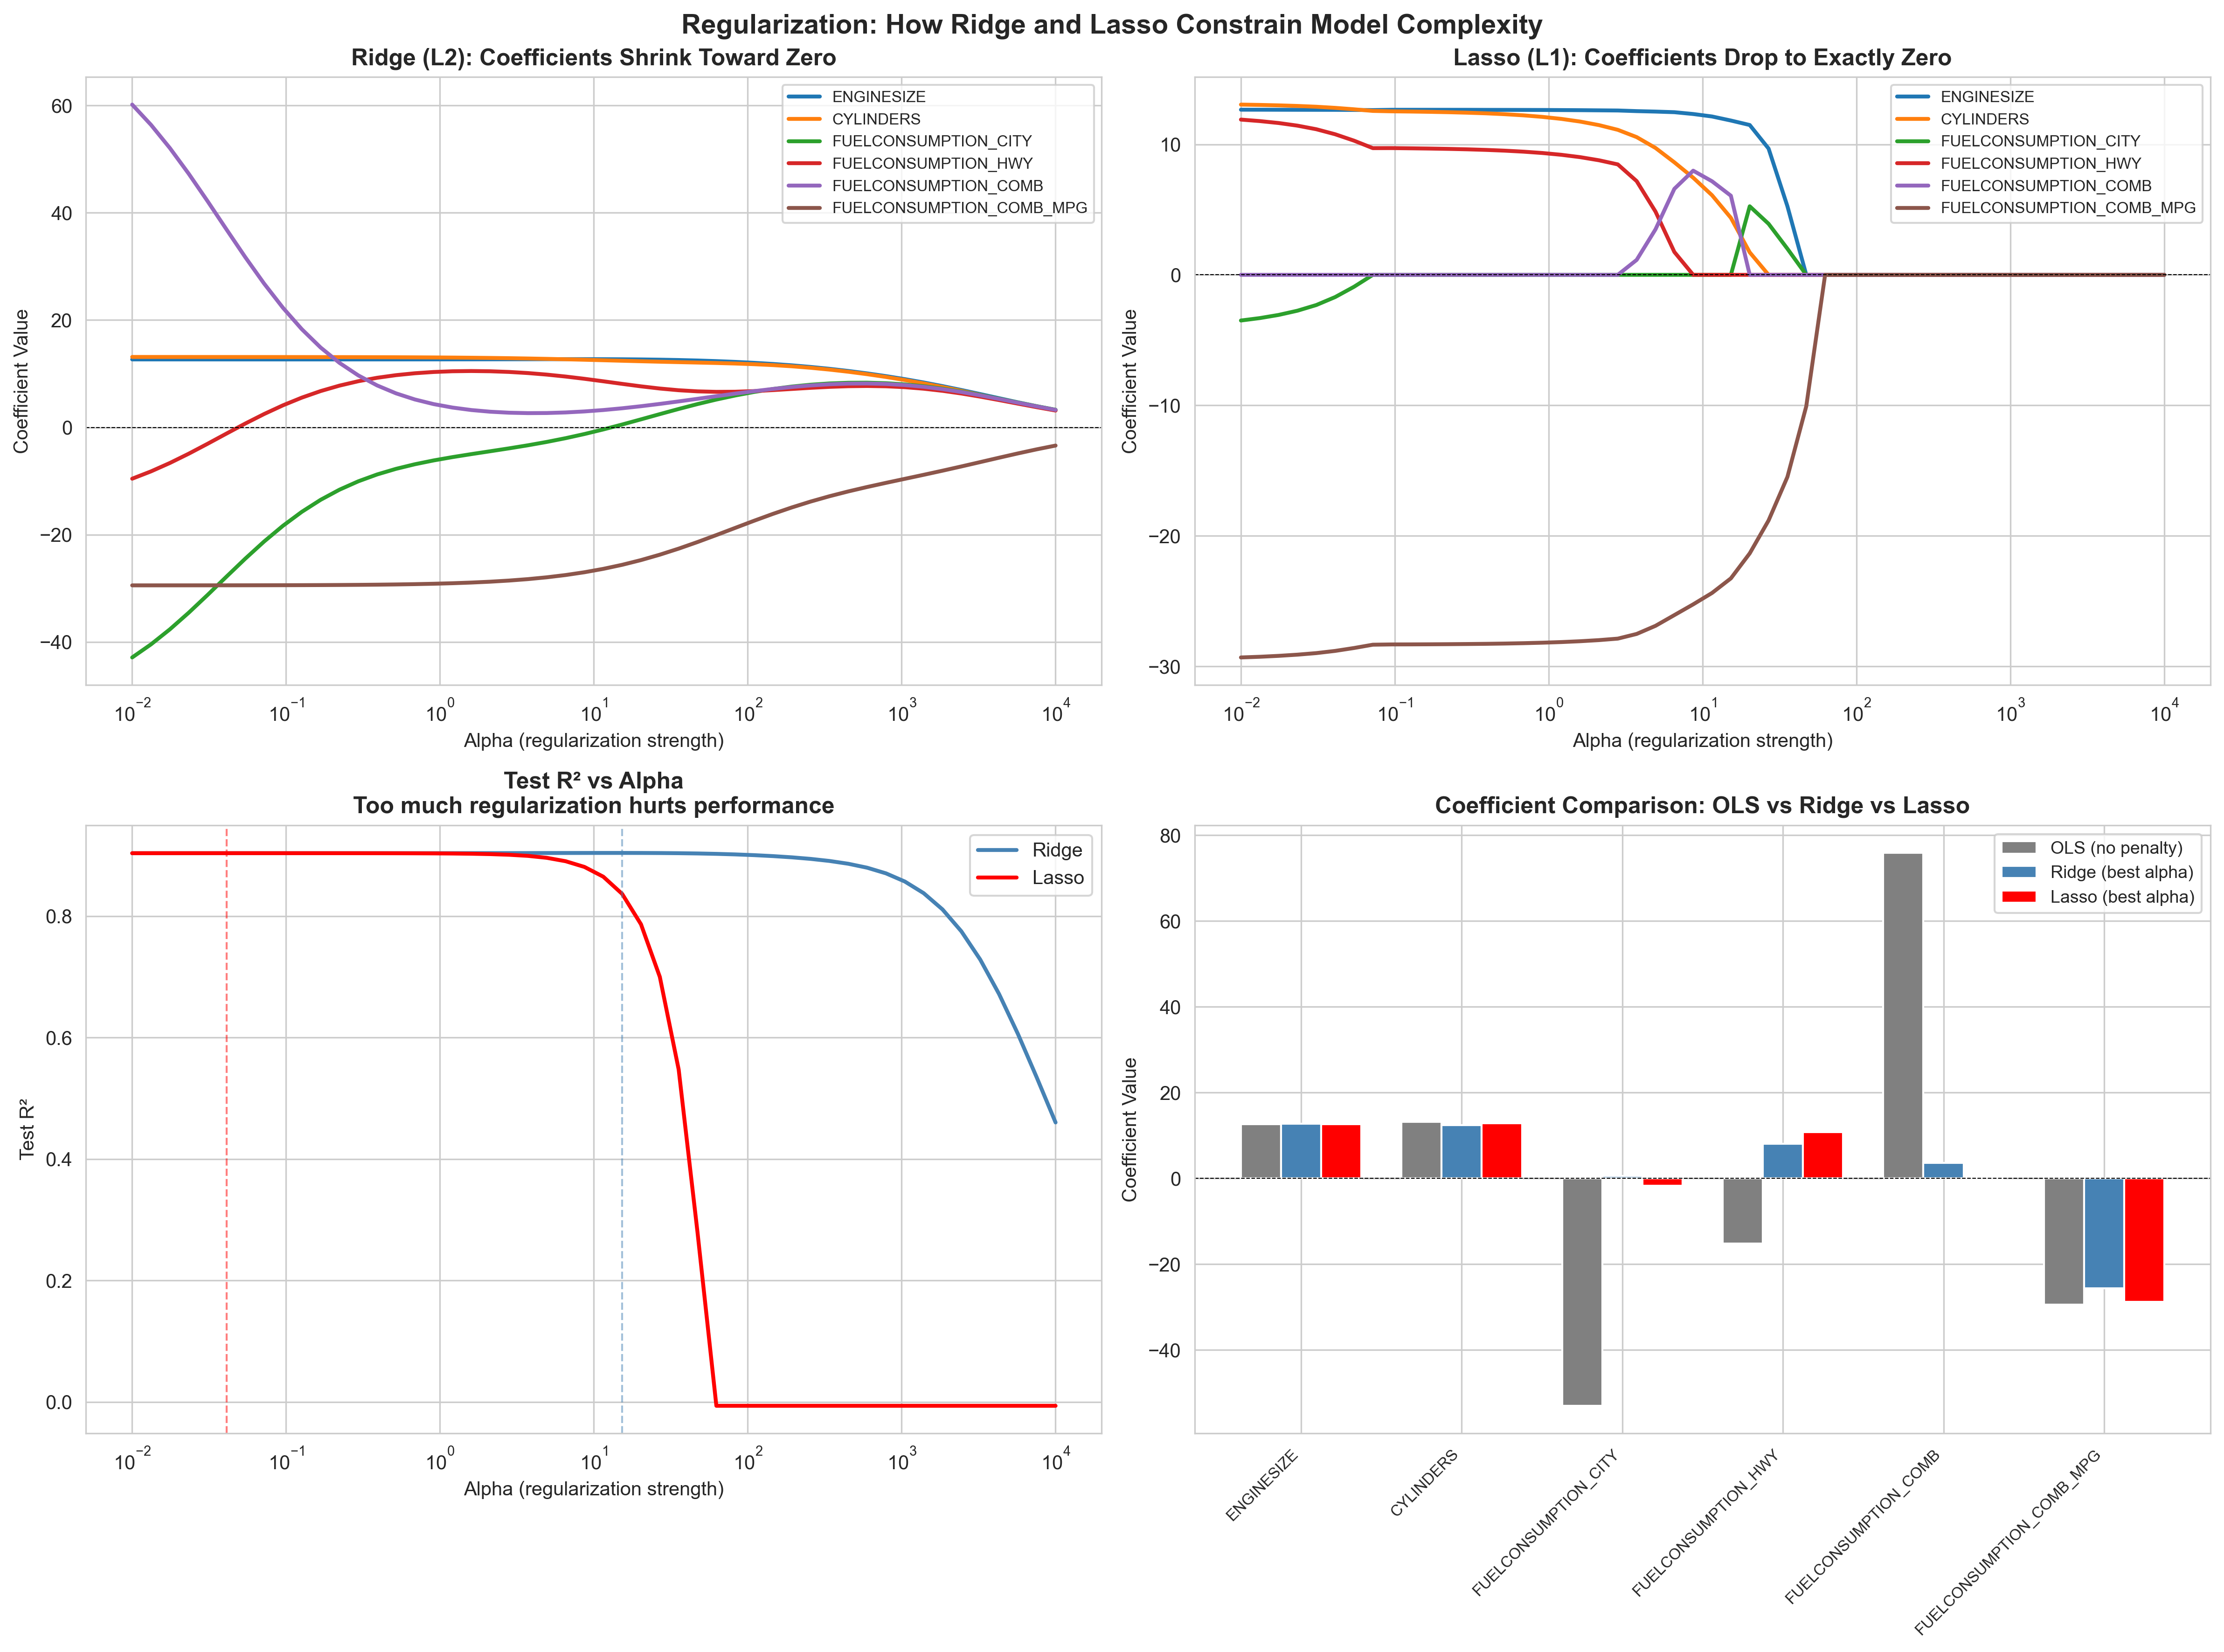

Best Ridge alpha: 15.26 (R² = 0.9039)
Best Lasso alpha: 0.04 (R² = 0.9035)

Key takeaway:
  Ridge: shrinks ALL coefficients but keeps every feature
  Lasso: eliminates less important features entirely (coefficients = 0)


In [97]:
# Regularization Visualized: Ridge (L2) vs Lasso (L1)
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY',
            'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']
X_reg = fuel_df[features]
y_reg = fuel_df['CO2EMISSIONS']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale features so coefficients are comparable
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_r)
X_te_scaled = scaler.transform(X_te_r)

# Track coefficients across a range of alpha values
alphas = np.logspace(-2, 4, 50)

ridge_coefs = []
lasso_coefs = []
ridge_scores = []
lasso_scores = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_tr_scaled, y_tr_r)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_tr_scaled, y_tr_r)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)
    ridge_scores.append(ridge.score(X_te_scaled, y_te_r))
    lasso_scores.append(lasso.score(X_te_scaled, y_te_r))

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Ridge coefficients shrink toward zero ---
for i, feat in enumerate(features):
    axes[0, 0].plot(alphas, ridge_coefs[:, i], linewidth=2, label=feat)
axes[0, 0].set_xscale('log')
axes[0, 0].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[0, 0].set_title('Ridge (L2): Coefficients Shrink Toward Zero',
                      fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Alpha (regularization strength)')
axes[0, 0].set_ylabel('Coefficient Value')
axes[0, 0].legend(fontsize=8, loc='upper right')

# --- Plot 2: Lasso coefficients drop to exactly zero ---
for i, feat in enumerate(features):
    axes[0, 1].plot(alphas, lasso_coefs[:, i], linewidth=2, label=feat)
axes[0, 1].set_xscale('log')
axes[0, 1].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[0, 1].set_title('Lasso (L1): Coefficients Drop to Exactly Zero',
                      fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Alpha (regularization strength)')
axes[0, 1].set_ylabel('Coefficient Value')
axes[0, 1].legend(fontsize=8, loc='upper right')

# --- Plot 3: R² vs Alpha for both ---
axes[1, 0].plot(alphas, ridge_scores, linewidth=2, color='steelblue', label='Ridge')
axes[1, 0].plot(alphas, lasso_scores, linewidth=2, color='red', label='Lasso')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Test R² vs Alpha\nToo much regularization hurts performance',
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Alpha (regularization strength)')
axes[1, 0].set_ylabel('Test R²')
axes[1, 0].legend(fontsize=10)
axes[1, 0].axvline(x=alphas[np.argmax(ridge_scores)], color='steelblue',
                    linewidth=1, linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=alphas[np.argmax(lasso_scores)], color='red',
                    linewidth=1, linestyle='--', alpha=0.5)

# --- Plot 4: Bar chart comparing OLS vs Ridge vs Lasso coefficients ---
ols = LinearRegression().fit(X_tr_scaled, y_tr_r)
best_ridge = Ridge(alpha=alphas[np.argmax(ridge_scores)]).fit(X_tr_scaled, y_tr_r)
best_lasso = Lasso(alpha=alphas[np.argmax(lasso_scores)], max_iter=10000).fit(X_tr_scaled, y_tr_r)

x_pos = np.arange(len(features))
width = 0.25
axes[1, 1].bar(x_pos - width, ols.coef_, width, color='gray', label='OLS (no penalty)')
axes[1, 1].bar(x_pos, best_ridge.coef_, width, color='steelblue', label='Ridge (best alpha)')
axes[1, 1].bar(x_pos + width, best_lasso.coef_, width, color='red', label='Lasso (best alpha)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(features, rotation=45, ha='right', fontsize=8)
axes[1, 1].axhline(y=0, color='black', linewidth=0.5, linestyle='--')
axes[1, 1].set_title('Coefficient Comparison: OLS vs Ridge vs Lasso',
                      fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Coefficient Value')
axes[1, 1].legend(fontsize=9)

plt.suptitle('Regularization: How Ridge and Lasso Constrain Model Complexity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best Ridge alpha: {alphas[np.argmax(ridge_scores)]:.2f} (R² = {max(ridge_scores):.4f})')
print(f'Best Lasso alpha: {alphas[np.argmax(lasso_scores)]:.2f} (R² = {max(lasso_scores):.4f})')
print(f'\nKey takeaway:')
print(f'  Ridge: shrinks ALL coefficients but keeps every feature')
print(f'  Lasso: eliminates less important features entirely (coefficients = 0)')


### Selecting Alpha with Cross-Validation

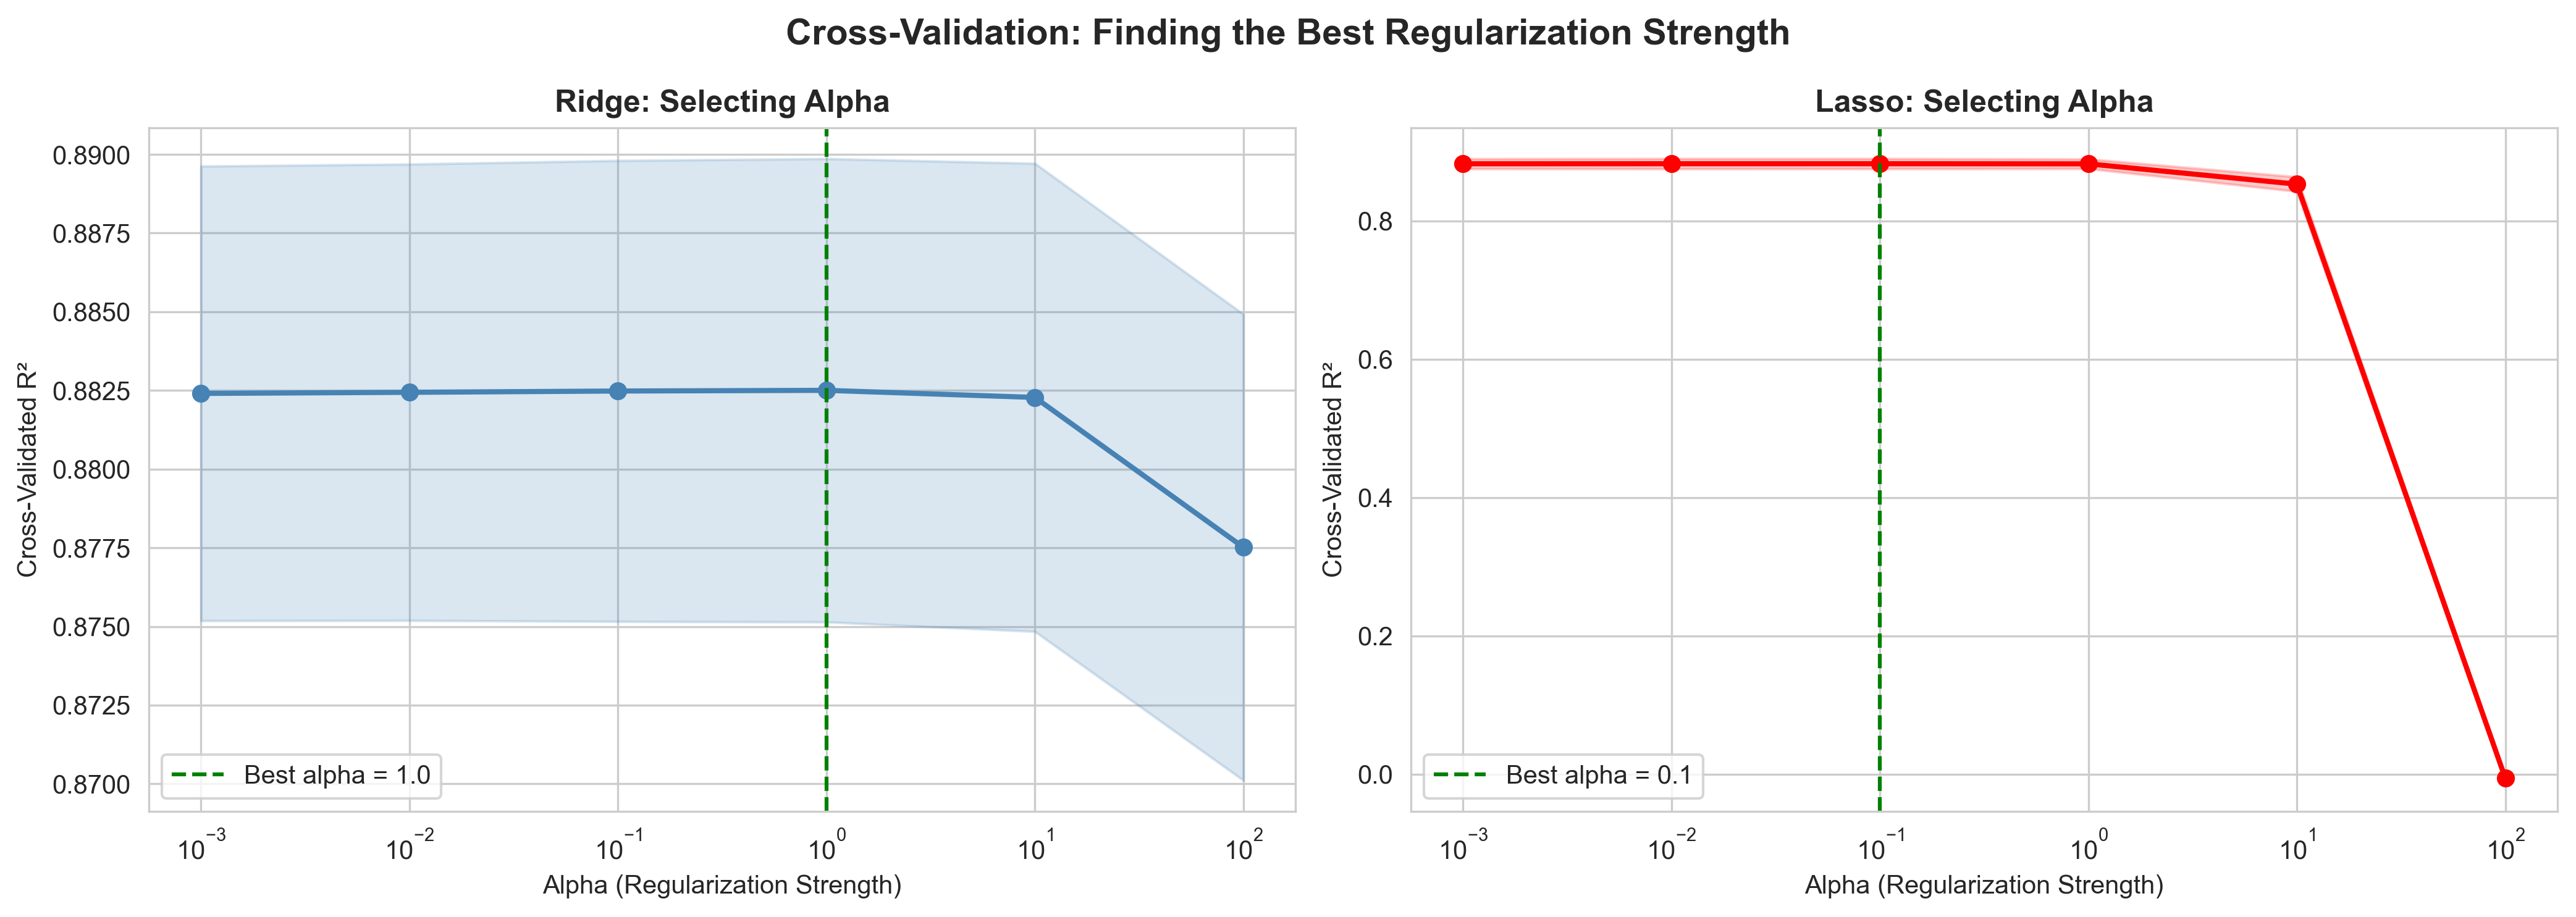

Best Ridge alpha: 1.0 with mean R² = 0.8825
Best Lasso alpha: 0.1 with mean R² = 0.8825


In [98]:
# Selecting the Best Alpha using Cross-Validation
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv_results = []
lasso_cv_results = []

for alpha in alphas:
    ridge_scores = cross_val_score(Ridge(alpha=alpha), X_tr_scaled, y_tr_r, cv=5, scoring='r2')
    lasso_scores = cross_val_score(Lasso(alpha=alpha, max_iter=100000), X_tr_scaled, y_tr_r, cv=5, scoring='r2')
    ridge_cv_results.append({'Alpha': alpha, 'Mean_R2': ridge_scores.mean(), 'Std': ridge_scores.std()})
    lasso_cv_results.append({'Alpha': alpha, 'Mean_R2': lasso_scores.mean(), 'Std': lasso_scores.std()})

ridge_cv_df = pd.DataFrame(ridge_cv_results)
lasso_cv_df = pd.DataFrame(lasso_cv_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(ridge_cv_df['Alpha'], ridge_cv_df['Mean_R2'], 'o-', linewidth=2, color='steelblue')
axes[0].fill_between(ridge_cv_df['Alpha'],
                     ridge_cv_df['Mean_R2'] - ridge_cv_df['Std'],
                     ridge_cv_df['Mean_R2'] + ridge_cv_df['Std'], alpha=0.2, color='steelblue')
best_ridge_cv = ridge_cv_df.loc[ridge_cv_df['Mean_R2'].idxmax()]
axes[0].axvline(x=best_ridge_cv['Alpha'], color='green', linewidth=1.5, linestyle='--',
                label=f'Best alpha = {best_ridge_cv["Alpha"]}')
axes[0].set_xlabel('Alpha (Regularization Strength)')
axes[0].set_ylabel('Cross-Validated R²')
axes[0].set_title('Ridge: Selecting Alpha', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Lasso
axes[1].semilogx(lasso_cv_df['Alpha'], lasso_cv_df['Mean_R2'], 'o-', linewidth=2, color='red')
axes[1].fill_between(lasso_cv_df['Alpha'],
                     lasso_cv_df['Mean_R2'] - lasso_cv_df['Std'],
                     lasso_cv_df['Mean_R2'] + lasso_cv_df['Std'], alpha=0.2, color='red')
best_lasso_cv = lasso_cv_df.loc[lasso_cv_df['Mean_R2'].idxmax()]
axes[1].axvline(x=best_lasso_cv['Alpha'], color='green', linewidth=1.5, linestyle='--',
                label=f'Best alpha = {best_lasso_cv["Alpha"]}')
axes[1].set_xlabel('Alpha (Regularization Strength)')
axes[1].set_ylabel('Cross-Validated R²')
axes[1].set_title('Lasso: Selecting Alpha', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Cross-Validation: Finding the Best Regularization Strength',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best Ridge alpha: {best_ridge_cv["Alpha"]} with mean R² = {best_ridge_cv["Mean_R2"]:.4f}')
print(f'Best Lasso alpha: {best_lasso_cv["Alpha"]} with mean R² = {best_lasso_cv["Mean_R2"]:.4f}')


     Feature     OLS  Ridge (alpha=10)  Lasso (alpha=1)
 Compactness -7.5163           -2.8187           0.0000
Surface_Area -4.3354           -1.6231          -0.0000
   Wall_Area  0.5920            1.5730           1.3894
   Roof_Area -4.5359           -2.3495          -0.0000
      Height  6.8769            7.0570           7.5610

Intercepts:
  OLS:   22.1550
  Ridge: 22.1550
  Lasso: 22.1550
OLS (No Penalty) -- keeps large coefficients freely
Heating_Load = 22.16
               -7.52 x Compactness
               -4.34 x Surface_Area
               +0.59 x Wall_Area
               -4.54 x Roof_Area
               +6.88 x Height

Ridge (L2) -- shrinks all coefficients toward zero
Heating_Load = 22.16
               -2.82 x Compactness
               -1.62 x Surface_Area
               +1.57 x Wall_Area
               -2.35 x Roof_Area
               +7.06 x Height

Lasso (L1) -- drives some coefficients to exactly zero
Heating_Load = 22.16
               +1.39 x Wall_Area
          

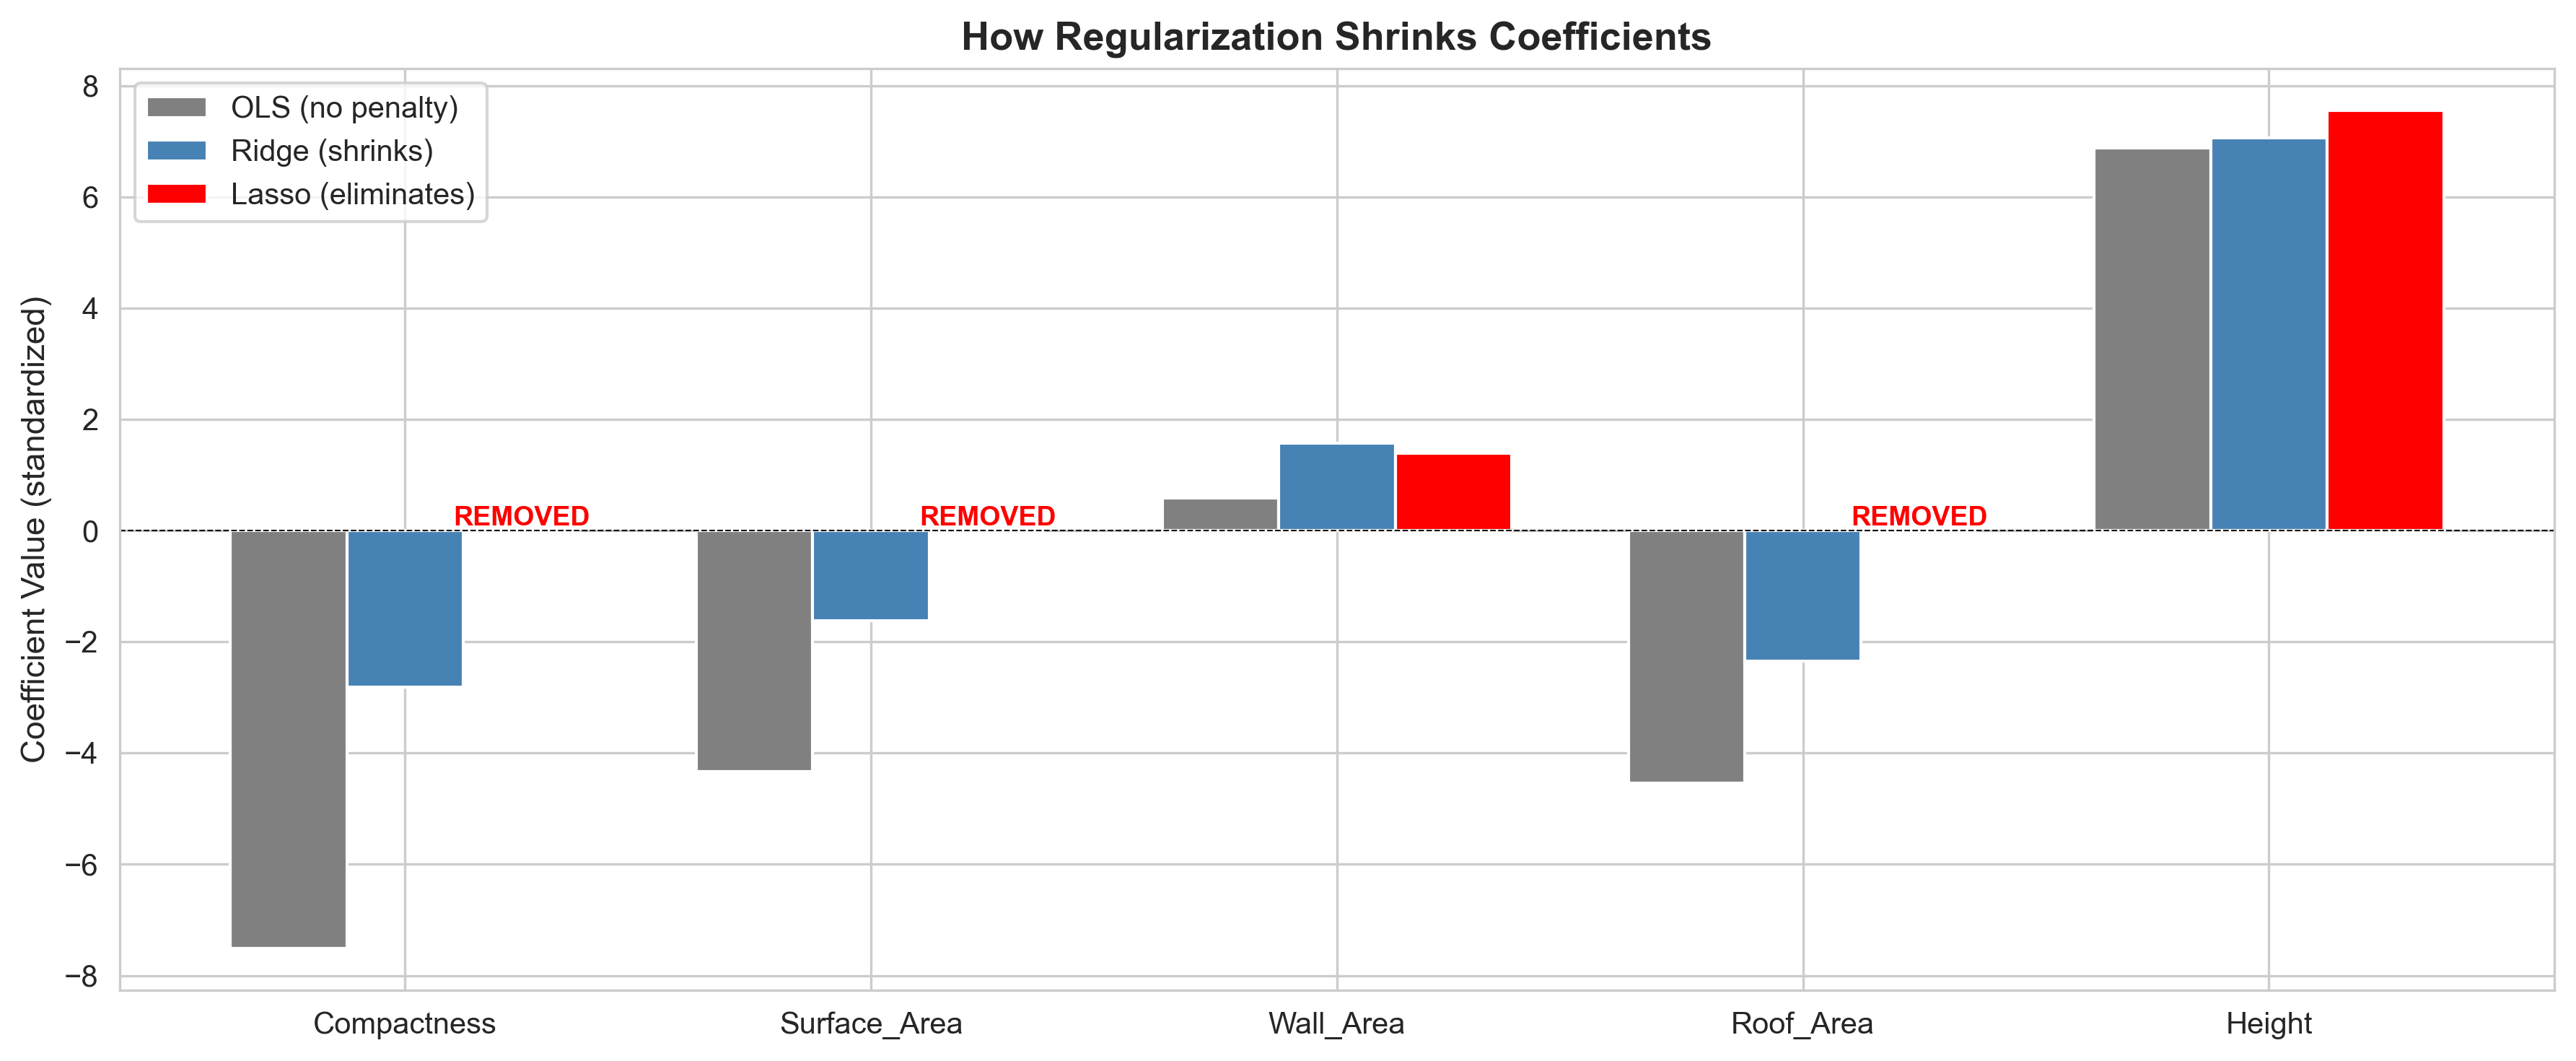

Test R² Scores:
  OLS:   0.8495
  Ridge: 0.8478
  Lasso: 0.8262


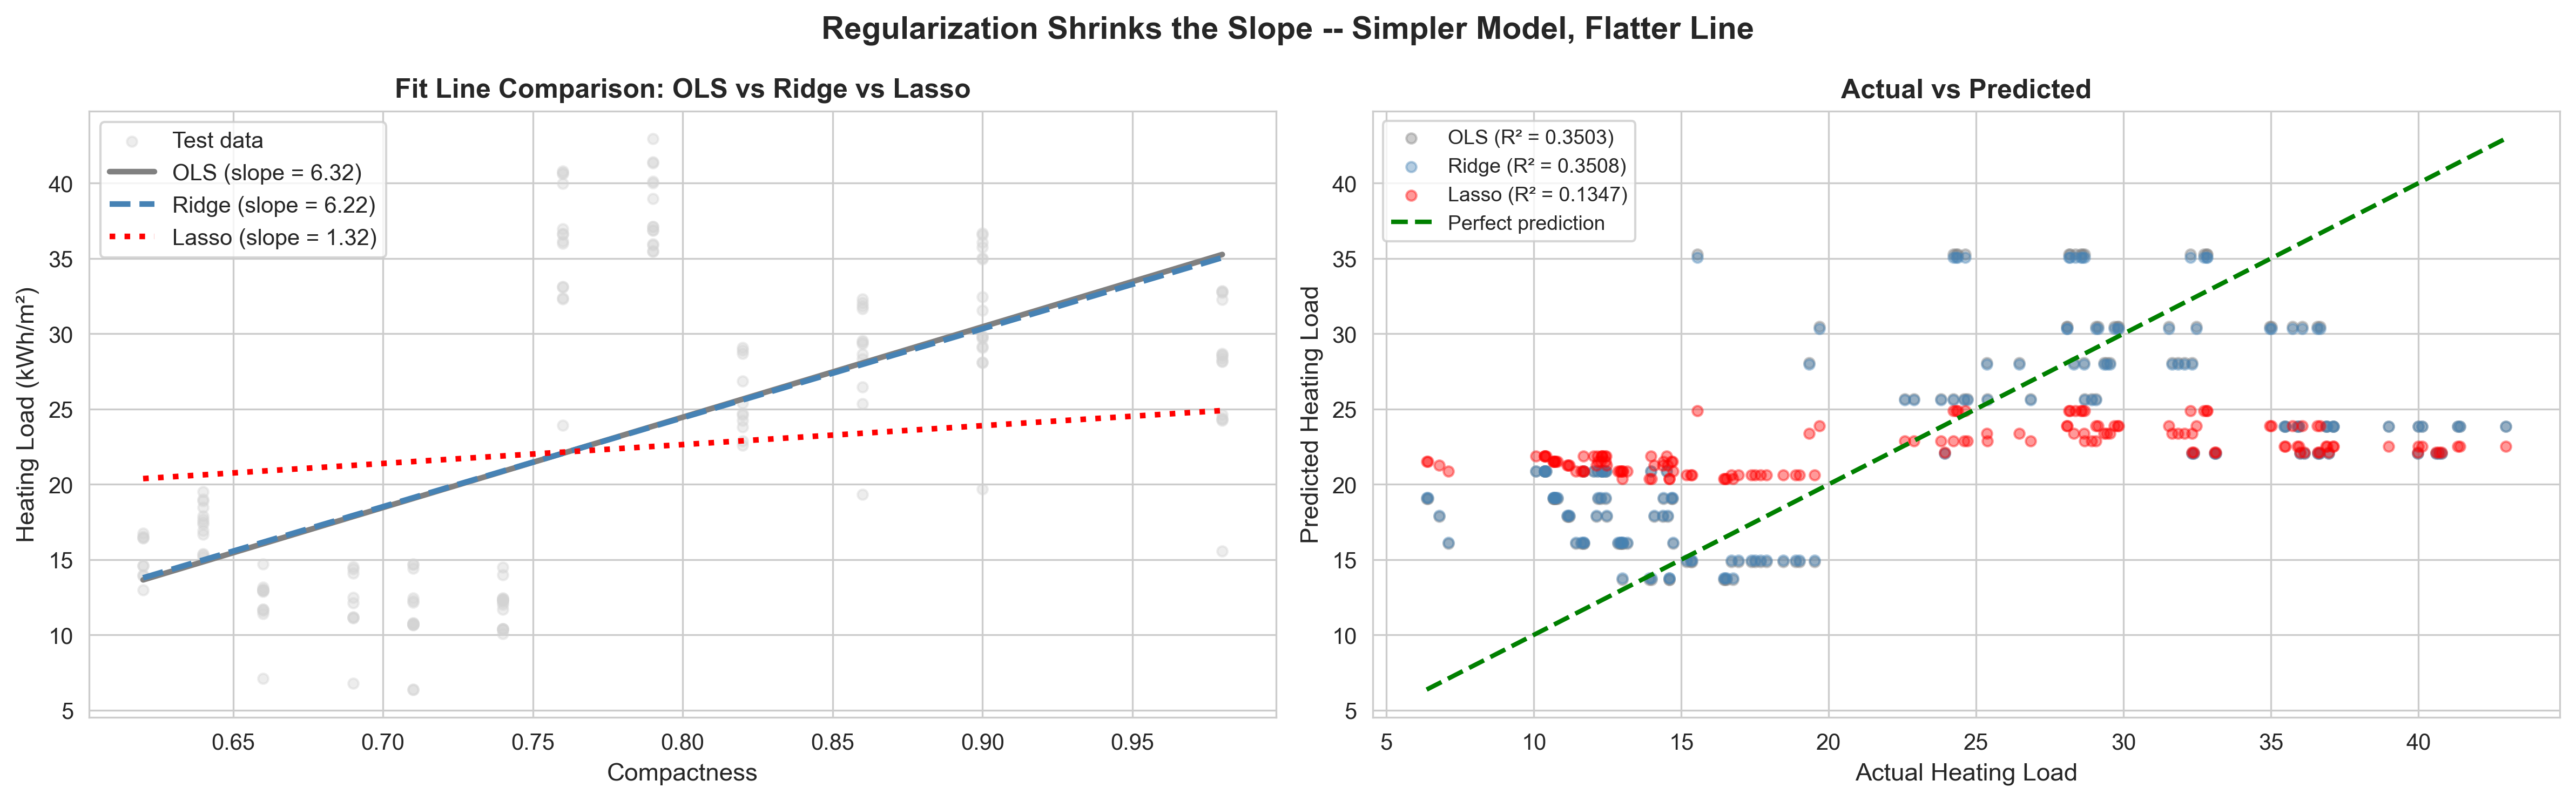

Slopes:  OLS = 6.32  |  Ridge = 6.22  |  Lasso = 1.32
R²:      OLS = 0.3503  |  Ridge = 0.3508  |  Lasso = 0.1347

Notice: Ridge slightly shrinks the slope, Lasso aggressively flattens it.
Stronger penalty = flatter line = simpler model.


In [99]:
# Regularization in Action: See How Coefficients Shrink
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Load and rename columns for clarity
energy_df = pd.read_excel('../../Datasets/ENB2012_data.xlsx')

energy_df.columns = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                     'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
                     'Heating_Load', 'Cooling_Load']

energy_df.head()

features = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Height']
X_reg = energy_df[features]
y_reg = energy_df['Heating_Load']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale so coefficients are comparable
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_r)
X_te_scaled = scaler.transform(X_te_r)

# Fit all three models
ols = LinearRegression().fit(X_tr_scaled, y_tr_r)
ridge = Ridge(alpha=10).fit(X_tr_scaled, y_tr_r)
lasso = Lasso(alpha=1, max_iter=50000).fit(X_tr_scaled, y_tr_r)

# Display coefficients side by side
coef_df = pd.DataFrame({
    'Feature': features,
    'OLS': ols.coef_.round(4),
    'Ridge (alpha=10)': ridge.coef_.round(4),
    'Lasso (alpha=1)': lasso.coef_.round(4)
})
print(coef_df.to_string(index=False))

print(f'\nIntercepts:')
print(f'  OLS:   {ols.intercept_:.4f}')
print(f'  Ridge: {ridge.intercept_:.4f}')
print(f'  Lasso: {lasso.intercept_:.4f}')

# The Equations: See the Formulas Side by Side

print('=' * 70)
print('OLS (No Penalty) -- keeps large coefficients freely')
print('=' * 70)
terms_ols = [f'{ols.coef_[i]:+.2f} x {features[i]}' for i in range(len(features))]
print(f'Heating_Load = {ols.intercept_:.2f}')
for t in terms_ols:
    print(f'               {t}')

print()
print('=' * 70)
print('Ridge (L2) -- shrinks all coefficients toward zero')
print('=' * 70)
terms_ridge = [f'{ridge.coef_[i]:+.2f} x {features[i]}' for i in range(len(features))]
print(f'Heating_Load = {ridge.intercept_:.2f}')
for t in terms_ridge:
    print(f'               {t}')

print()
print('=' * 70)
print('Lasso (L1) -- drives some coefficients to exactly zero')
print('=' * 70)
terms_lasso = []
eliminated = []
for i in range(len(features)):
    if lasso.coef_[i] == 0:
        eliminated.append(features[i])
    else:
        terms_lasso.append(f'{lasso.coef_[i]:+.2f} x {features[i]}')

print(f'Heating_Load = {lasso.intercept_:.2f}')
for t in terms_lasso:
    print(f'               {t}')
if eliminated:
    print(f'\n  Eliminated features (coefficient = 0): {eliminated}')
    print(f'  Lasso removed {len(eliminated)} feature(s) -- automatic feature selection!')


# Visualize: How Each Method Changes the Coefficients
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(features))
width = 0.25

bars1 = ax.bar(x_pos - width, ols.coef_, width, color='gray', label='OLS (no penalty)')
bars2 = ax.bar(x_pos, ridge.coef_, width, color='steelblue', label='Ridge (shrinks)')
bars3 = ax.bar(x_pos + width, lasso.coef_, width, color='red', label='Lasso (eliminates)')

ax.set_xticks(x_pos)
ax.set_xticklabels(features, fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Coefficient Value (standardized)', fontsize=11)
ax.set_title('How Regularization Shrinks Coefficients', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate zero coefficients
for i, coef in enumerate(lasso.coef_):
    if coef == 0:
        ax.annotate('REMOVED', xy=(i + width, 0), fontsize=9, fontweight='bold',
                     color='red', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Score comparison
print(f'Test R² Scores:')
print(f'  OLS:   {ols.score(X_te_scaled, y_te_r):.4f}')
print(f'  Ridge: {ridge.score(X_te_scaled, y_te_r):.4f}')
print(f'  Lasso: {lasso.score(X_te_scaled, y_te_r):.4f}')


# Compare Fit Lines: OLS vs Ridge vs Lasso
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Use Compactness as single feature so we can plot fit lines
X_single = energy_df[['Compactness']].values
y_single = energy_df['Heating_Load'].values

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_single, y_single, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_s)
X_te_scaled = scaler.transform(X_te_s)

# Fit three models
model_ols = LinearRegression().fit(X_tr_scaled, y_tr_s)
model_ridge = Ridge(alpha=10).fit(X_tr_scaled, y_tr_s)
model_lasso = Lasso(alpha=5, max_iter=50000).fit(X_tr_scaled, y_tr_s)

# Generate smooth line for plotting
x_range = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)
x_range_scaled = scaler.transform(x_range)

# --- Plot 1: All three fit lines on one plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(X_te_s, y_te_s, alpha=0.4, s=20, color='lightgray', label='Test data')
axes[0].plot(x_range, model_ols.predict(x_range_scaled),
             color='gray', linewidth=2.5, label=f'OLS (slope = {model_ols.coef_[0]:.2f})')
axes[0].plot(x_range, model_ridge.predict(x_range_scaled),
             color='steelblue', linewidth=2.5, linestyle='--', label=f'Ridge (slope = {model_ridge.coef_[0]:.2f})')
axes[0].plot(x_range, model_lasso.predict(x_range_scaled),
             color='red', linewidth=2.5, linestyle=':', label=f'Lasso (slope = {model_lasso.coef_[0]:.2f})')
axes[0].set_xlabel('Compactness', fontsize=11)
axes[0].set_ylabel('Heating Load (kWh/m²)', fontsize=11)
axes[0].set_title('Fit Line Comparison: OLS vs Ridge vs Lasso', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# --- Plot 2: Actual vs Predicted for all three ---
pred_ols = model_ols.predict(X_te_scaled)
pred_ridge = model_ridge.predict(X_te_scaled)
pred_lasso = model_lasso.predict(X_te_scaled)

axes[1].scatter(y_te_s, pred_ols, alpha=0.4, s=20, color='gray', label=f'OLS (R² = {model_ols.score(X_te_scaled, y_te_s):.4f})')
axes[1].scatter(y_te_s, pred_ridge, alpha=0.4, s=20, color='steelblue', label=f'Ridge (R² = {model_ridge.score(X_te_scaled, y_te_s):.4f})')
axes[1].scatter(y_te_s, pred_lasso, alpha=0.4, s=20, color='red', label=f'Lasso (R² = {model_lasso.score(X_te_scaled, y_te_s):.4f})')

min_val = min(y_te_s.min(), pred_lasso.min())
max_val = max(y_te_s.max(), pred_ols.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='green', linewidth=2, linestyle='--', label='Perfect prediction')
axes[1].set_xlabel('Actual Heating Load', fontsize=11)
axes[1].set_ylabel('Predicted Heating Load', fontsize=11)
axes[1].set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Regularization Shrinks the Slope -- Simpler Model, Flatter Line',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Slopes:  OLS = {model_ols.coef_[0]:.2f}  |  Ridge = {model_ridge.coef_[0]:.2f}  |  Lasso = {model_lasso.coef_[0]:.2f}')
print(f'R²:      OLS = {model_ols.score(X_te_scaled, y_te_s):.4f}  |  Ridge = {model_ridge.score(X_te_scaled, y_te_s):.4f}  |  Lasso = {model_lasso.score(X_te_scaled, y_te_s):.4f}')
print(f'\nNotice: Ridge slightly shrinks the slope, Lasso aggressively flattens it.')
print(f'Stronger penalty = flatter line = simpler model.')



---
## 6. Logistic Regression Introduction

Logistic regression extends linear regression to **classification** tasks by passing the linear output through the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This maps any real value to a probability between 0 and 1.

> Full classification methods (decision trees, random forests, SVM, etc.) are covered in **Week 2**. This is a brief preview.

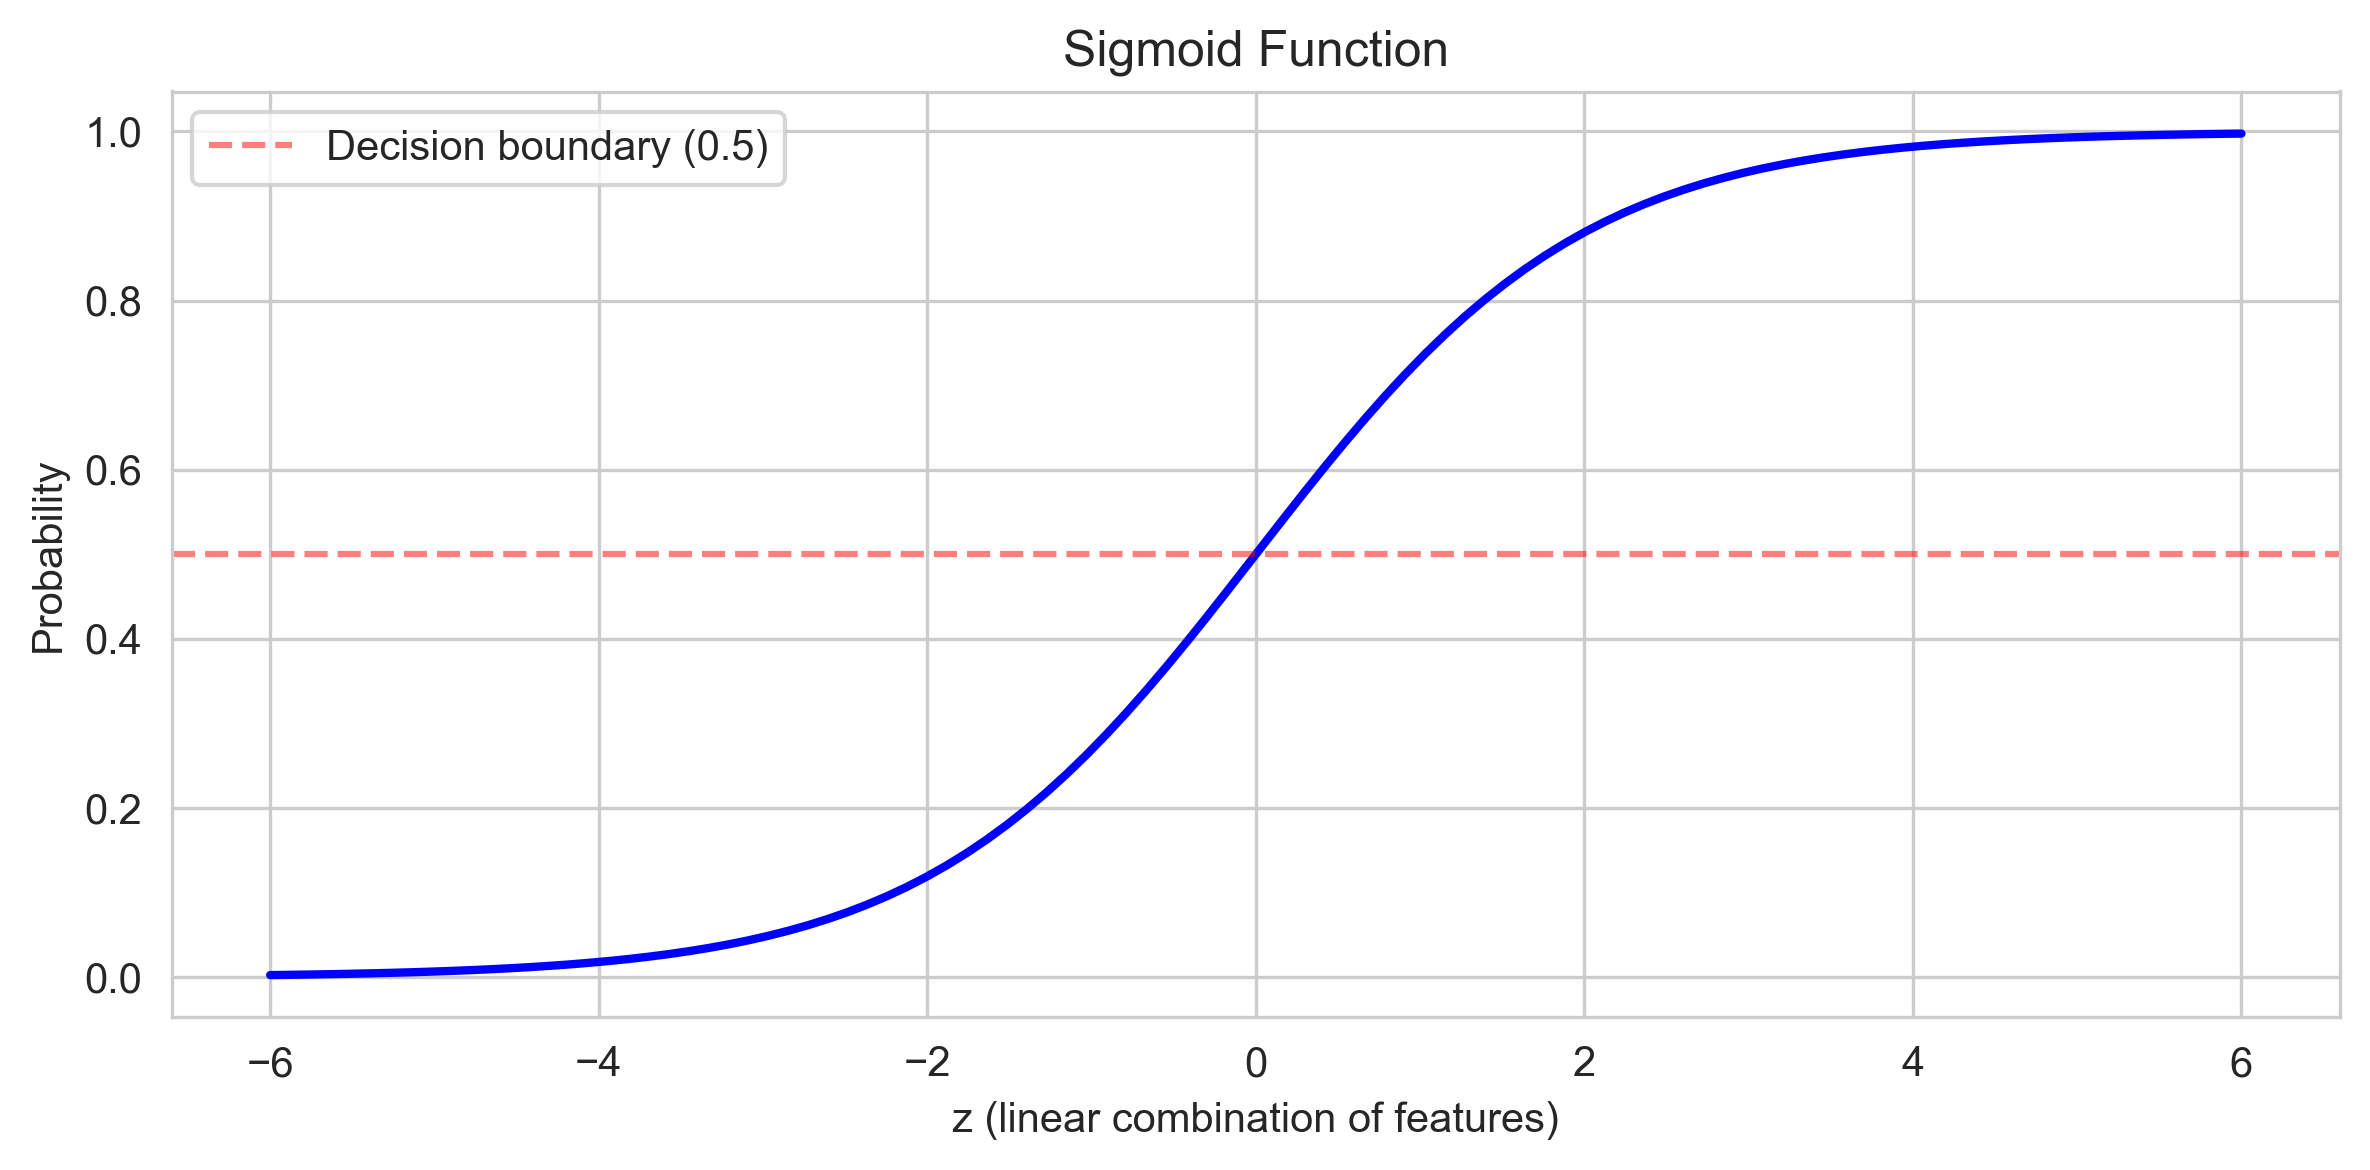

In [100]:
# The sigmoid function
z = np.linspace(-6, 6, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, linewidth=2, color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
plt.xlabel('z (linear combination of features)')
plt.ylabel('Probability')
plt.title('Sigmoid Function')
plt.legend()
plt.tight_layout()
plt.show()

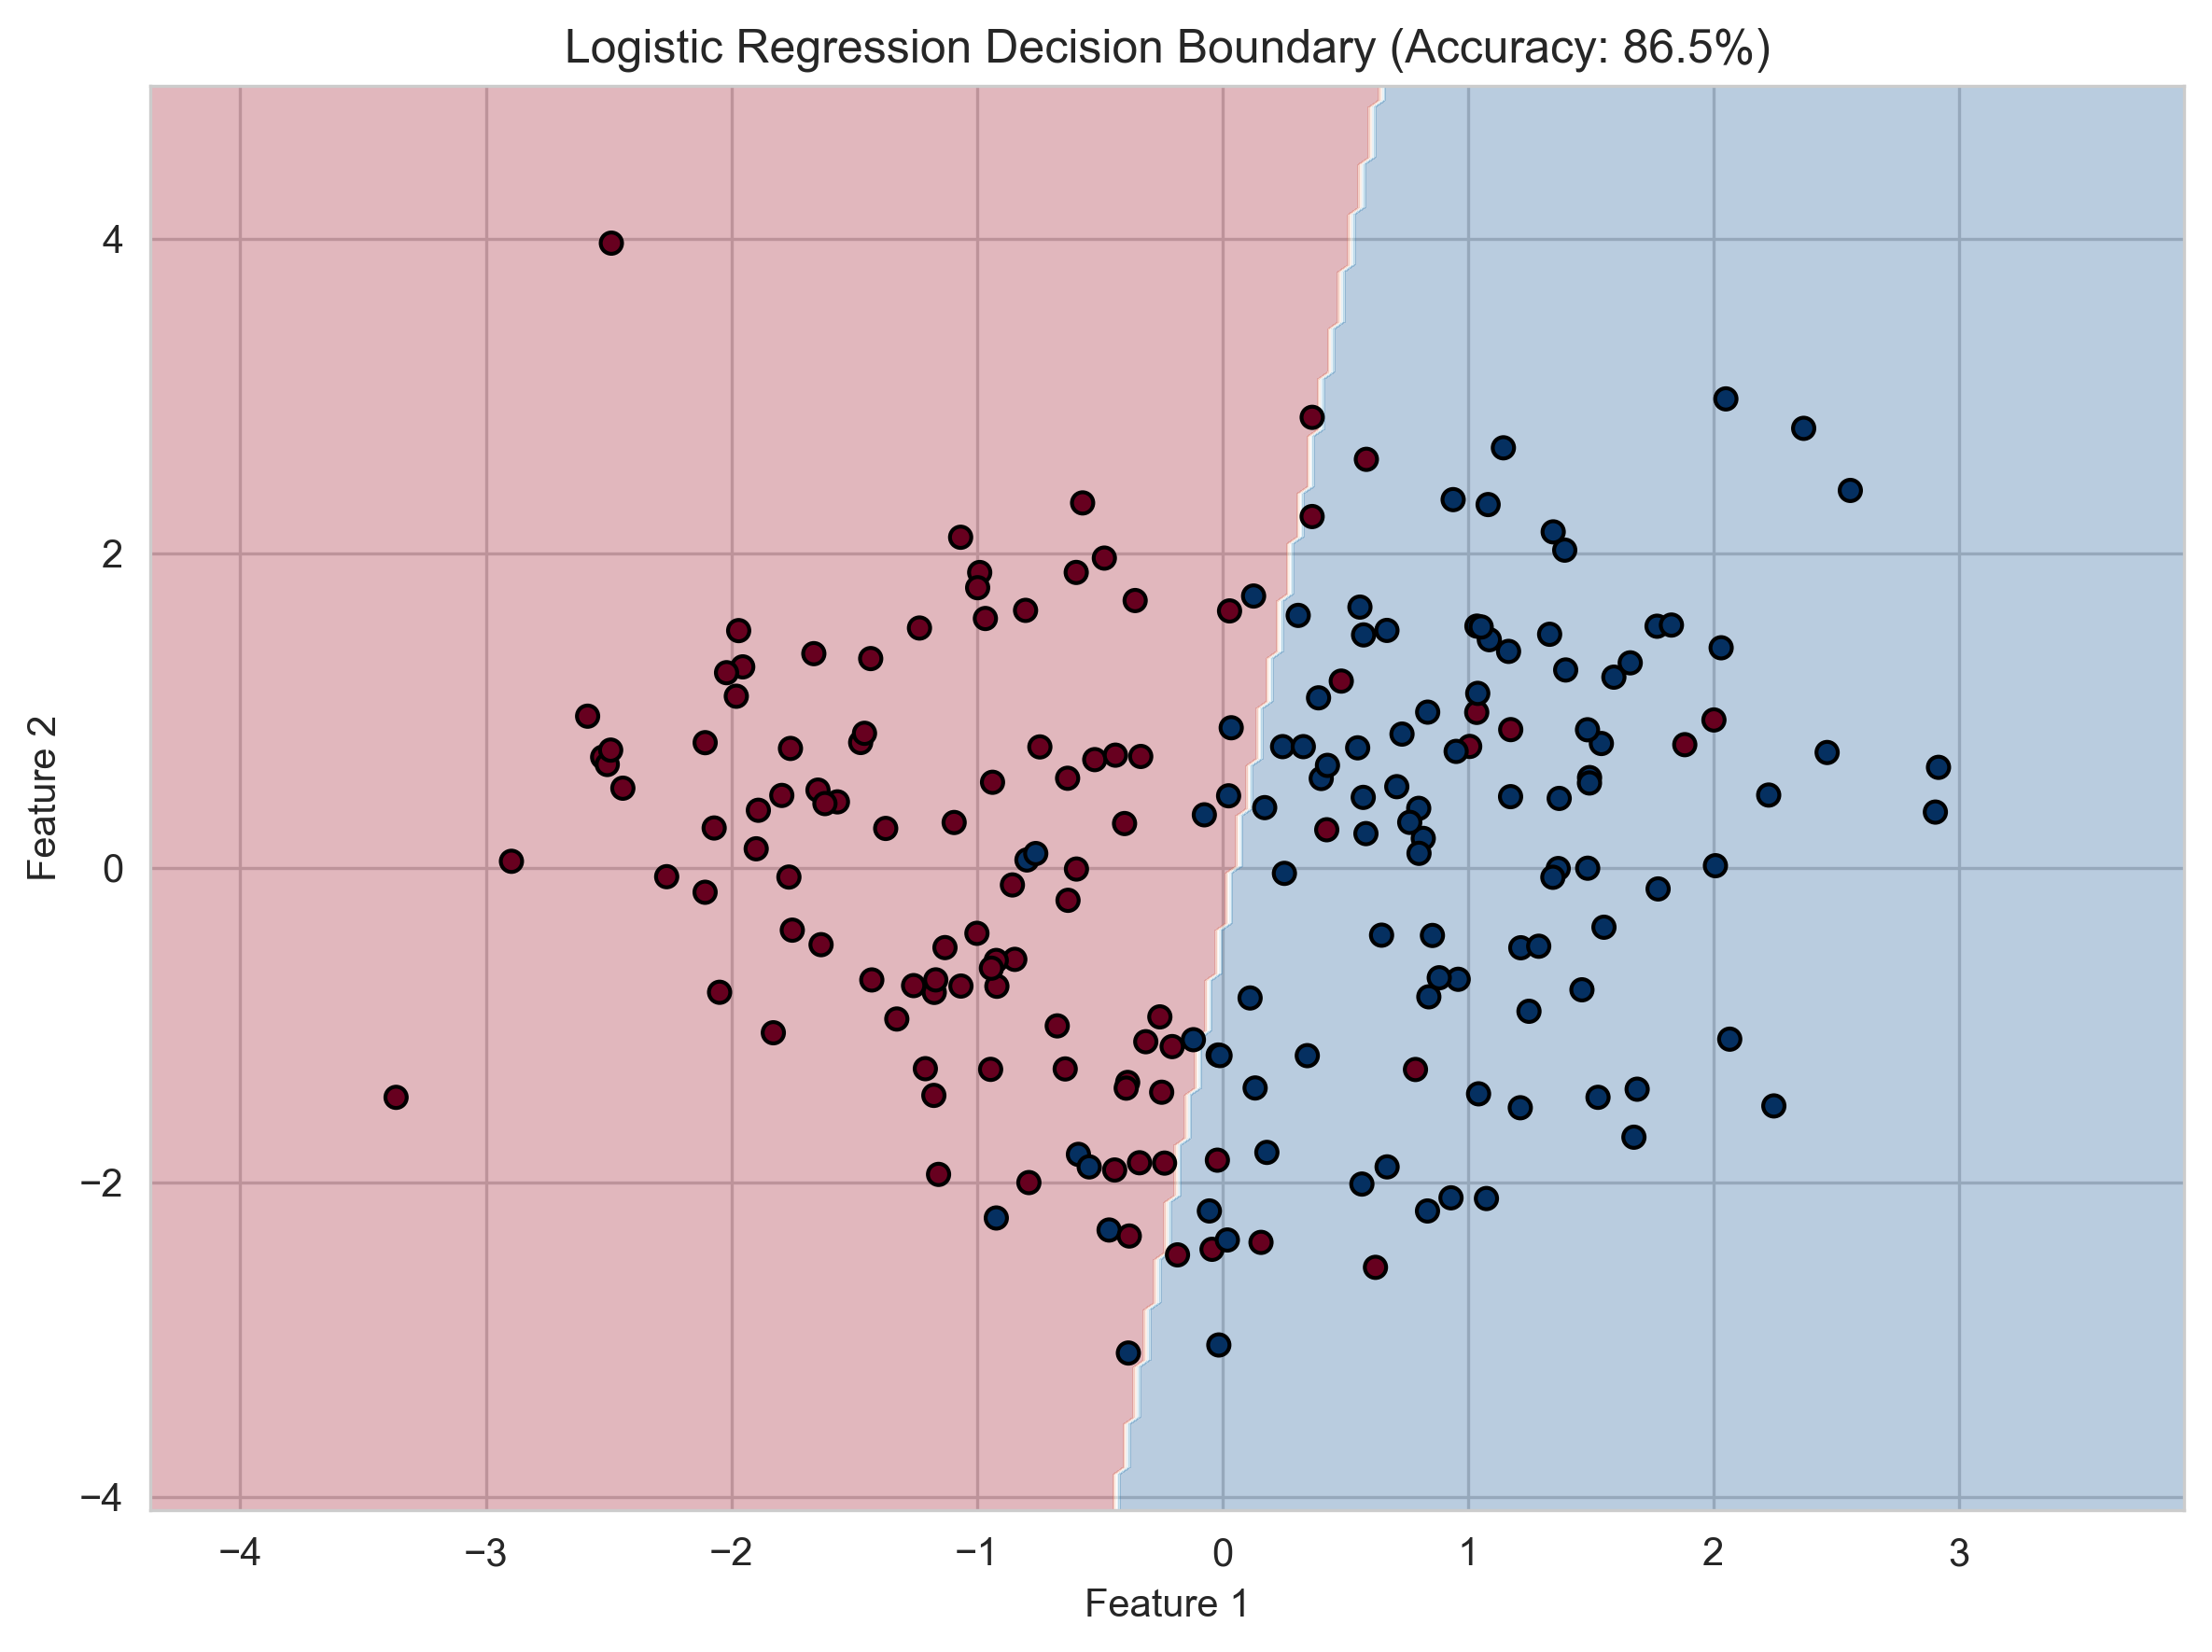

In [101]:
# Quick demo: binary classification with synthetic data
X_clf, y_clf = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=42)

lr = LogisticRegression(random_state=42)
lr.fit(X_clf, y_clf)

# Plot decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
x_min, x_max = X_clf[:, 0].min() - 1, X_clf[:, 0].max() + 1
y_min, y_max = X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='RdBu', edgecolors='black', s=30)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'Logistic Regression Decision Boundary (Accuracy: {lr.score(X_clf, y_clf):.1%})')
plt.tight_layout()
plt.show()

---
## 7. Lab Exercise

Complete a regression analysis on the `FuelConsumptionCo2` dataset.

**Tasks:**
1. Select 4 features to predict `CO2EMISSIONS`
2. Split into train/test (80/20)
3. Train a linear regression model and report R2 and RMSE
4. Try polynomial regression (degree 2) and compare


In [102]:
# The data is already loaded as fuel_df

# TODO: Select features
# X_lab = fuel_df[['...', '...']]
# y_lab = fuel_df['CO2EMISSIONS']

# TODO: Train/test split

# TODO: Linear regression -- report R2 and RMSE

# TODO: Polynomial regression (degree 2) -- compare metrics




### Bonus Challenge

Load `ENB2012_data.xlsx` and predict heating load (Y1) using Ridge regression with polynomial features. Compare different alpha values and report the best one.

In [103]:
# Class Activity: Building Energy Prediction
# Dataset: ENB2012 - Building Energy Efficiency
# Goal: Compare Linear vs Polynomial Regression

# Can a building's shape predict how much heating it needs?
# You will use the ENB2012 dataset which contains 768 buildings
# with features like compactness, surface area, wall area, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score



# Load and rename columns for clarity
energy_df = pd.read_excel('../../Datasets/ENB2012_data.xlsx')

energy_df.columns = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                     'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
                     'Heating_Load', 'Cooling_Load']

energy_df.head()


,Compactness,Surface_Area,Wall_Area,Roof_Area,Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [104]:
# Part 1: Explore the Data
# TODO: Use .describe() to understand the data


# Part 2: Multiple Linear Regression
# TODO: Select these 4 features: Compactness, Surface_Area, Wall_Area, Roof_Area
# TODO: Target: Heating_Load
# TODO: Split data into train/test (80/20, random_state=42)
# TODO: Fit a LinearRegression model
# TODO: Print R² and RMSE on the test set


# Part 3: Multiple Polynomial Regression (degree 2)
# TODO: Use PolynomialFeatures(degree=2) to transform your 4 features
# TODO: Print how many features were created using poly.get_feature_names_out()
#       (Hint: 4 features become many more -- why?)
# TODO: Fit a LinearRegression on the polynomial features
# TODO: Print R² and RMSE -- how much did it improve?

# Part 4: Add More Features
# TODO: Now use ALL 5 features: Compactness, Surface_Area, Wall_Area, Roof_Area, Height
# TODO: Fit both Linear and Polynomial (degree 2) models
# TODO: Print R² and RMSE for both
# TODO: Did adding Height help?

# Part 5: Discussion
# 1. How many features did PolynomialFeatures create from 4 inputs? From 5 inputs? Why the big jump?
# 2. Which model performed best? Was the improvement worth the extra complexity?
# 3. What risks come with creating so many polynomial features? (Hint: think about overfitting)



---
## Session Summary

- **Linear regression** minimizes MSE to find the best-fit line through the data
- **Evaluation metrics** (MSE, RMSE, MAE, R2) quantify model performance from different angles
- **Polynomial regression** captures non-linear relationships by adding feature powers
- **Bias-variance tradeoff** explains why more complex models are not always better
- **Regularization** (Ridge, Lasso) penalizes large coefficients to reduce overfitting
- **Cross-validation** provides robust performance estimates and helps select hyperparameters


       Compactness  Surface_Area  Wall_Area  Roof_Area  Height  Orientation  \
count       768.00        768.00     768.00     768.00  768.00       768.00   
mean          0.76        671.71     318.50     176.60    5.25         3.50   
std           0.11         88.09      43.63      45.17    1.75         1.12   
min           0.62        514.50     245.00     110.25    3.50         2.00   
25%           0.68        606.38     294.00     140.88    3.50         2.75   
50%           0.75        673.75     318.50     183.75    5.25         3.50   
75%           0.83        741.12     343.00     220.50    7.00         4.25   
max           0.98        808.50     416.50     220.50    7.00         5.00   

       Glazing_Area  Glazing_Distribution  Heating_Load  Cooling_Load  
count        768.00                768.00        768.00        768.00  
mean           0.23                  2.81         22.31         24.59  
std            0.13                  1.55         10.09          9.51  


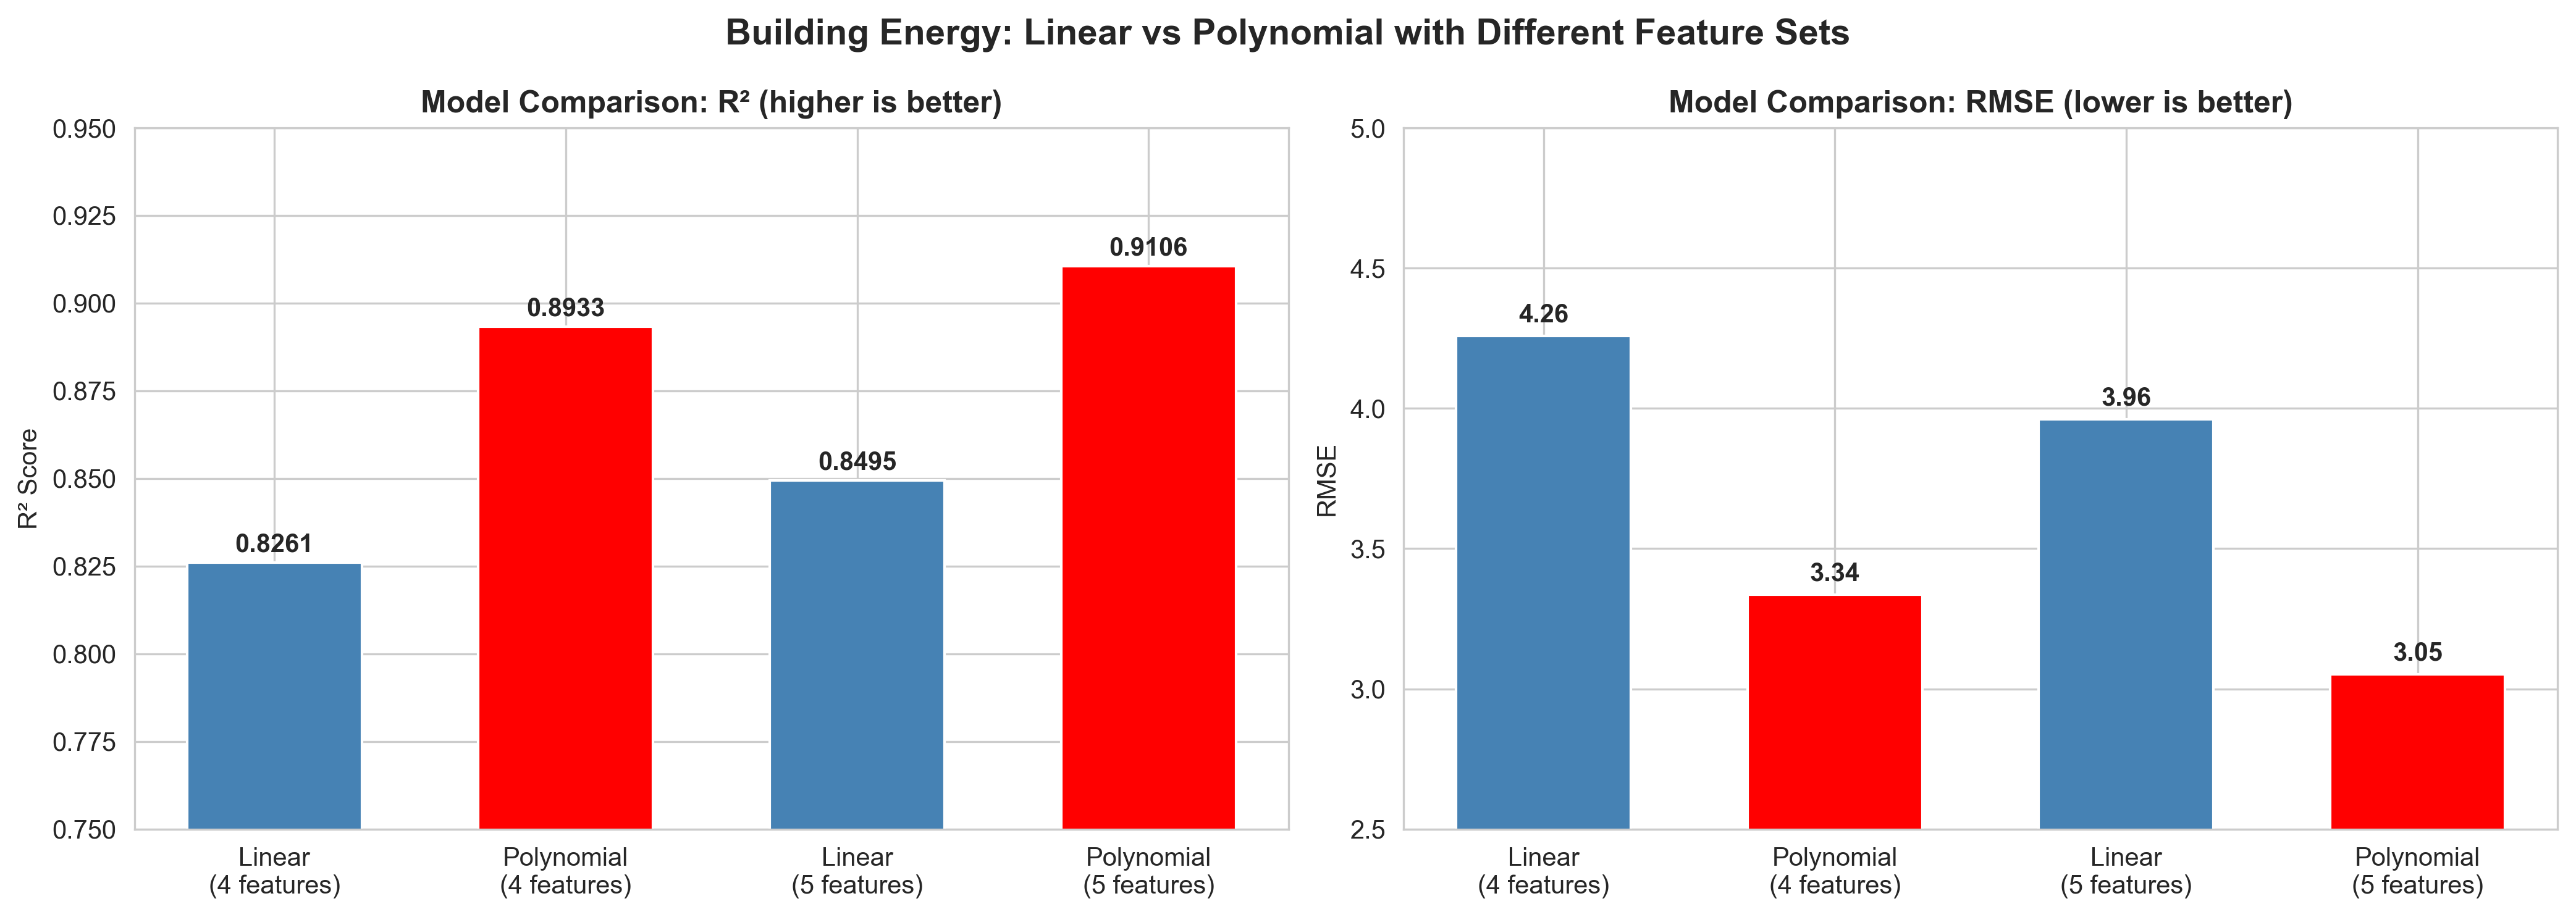

In [105]:
# Answer to bonus question:


# Part 1: Explore the Data
print(energy_df.describe().round(2))

print('\nCorrelations with Heating_Load:')
corr = energy_df.corr()['Heating_Load'].drop(['Heating_Load', 'Cooling_Load']).sort_values(ascending=False)
print(corr.round(4))

# Part 2: Multiple Linear Regression (4 features)
features_4 = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area']
X = energy_df[features_4]
y = energy_df['Heating_Load']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lin4 = LinearRegression()
model_lin4.fit(X_train, y_train)
y_pred_lin4 = model_lin4.predict(X_test)

r2_lin4 = r2_score(y_test, y_pred_lin4)
rmse_lin4 = np.sqrt(mean_squared_error(y_test, y_pred_lin4))

print(f'Linear Regression (4 features):')
print(f'  R²:   {r2_lin4:.4f}')
print(f'  RMSE: {rmse_lin4:.2f}')


# Part 3: Multiple Polynomial Regression (4 features, degree 2)
poly4 = PolynomialFeatures(degree=2)
X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

print(f'Original features:   {len(features_4)}  -> {features_4}')
print(f'Polynomial features: {X_train_poly4.shape[1]} -> {list(poly4.get_feature_names_out())}')
print(f'\nPolynomialFeatures creates: 1 (bias) + original + squares + all cross-products')

model_poly4 = LinearRegression()
model_poly4.fit(X_train_poly4, y_train)
y_pred_poly4 = model_poly4.predict(X_test_poly4)

r2_poly4 = r2_score(y_test, y_pred_poly4)
rmse_poly4 = np.sqrt(mean_squared_error(y_test, y_pred_poly4))

print(f'\nPolynomial Regression (4 features, degree 2):')
print(f'  R²:   {r2_poly4:.4f}')
print(f'  RMSE: {rmse_poly4:.2f}')
print(f'\nImprovement over linear:')
print(f'  R²:   {r2_poly4 - r2_lin4:+.4f}')
print(f'  RMSE: {rmse_poly4 - rmse_lin4:+.2f} (lower is better)')

# Part 4: Add Height (5 features)
features_5 = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Height']
X5 = energy_df[features_5]

X_train5, X_test5, y_train5, y_test5 = train_test_split(X5, y, test_size=0.2, random_state=42)

# Linear with 5 features
model_lin5 = LinearRegression()
model_lin5.fit(X_train5, y_train5)
y_pred_lin5 = model_lin5.predict(X_test5)
r2_lin5 = r2_score(y_test5, y_pred_lin5)
rmse_lin5 = np.sqrt(mean_squared_error(y_test5, y_pred_lin5))

# Polynomial with 5 features
poly5 = PolynomialFeatures(degree=2)
X_train5_poly = poly5.fit_transform(X_train5)
X_test5_poly = poly5.transform(X_test5)

model_poly5 = LinearRegression()
model_poly5.fit(X_train5_poly, y_train5)
y_pred_poly5 = model_poly5.predict(X_test5_poly)
r2_poly5 = r2_score(y_test5, y_pred_poly5)
rmse_poly5 = np.sqrt(mean_squared_error(y_test5, y_pred_poly5))

print(f'5 Features - Linear:     R² = {r2_lin5:.4f}, RMSE = {rmse_lin5:.2f}')
print(f'5 Features - Polynomial: R² = {r2_poly5:.4f}, RMSE = {rmse_poly5:.2f}')
print(f'\nPolynomial features created: {X_train5_poly.shape[1]} from 5 original')
print(f'Adding Height improved both models -- it has the strongest correlation (0.89)')


# Compare All Models
models = ['Linear\n(4 features)', 'Polynomial\n(4 features)',
          'Linear\n(5 features)', 'Polynomial\n(5 features)']
r2_scores = [r2_lin4, r2_poly4, r2_lin5, r2_poly5]
rmse_scores = [rmse_lin4, rmse_poly4, rmse_lin5, rmse_poly5]
colors = ['steelblue', 'red', 'steelblue', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
bars1 = axes[0].bar(models, r2_scores, color=colors, edgecolor='white', width=0.6)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison: R² (higher is better)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.75, 0.95)
for bar, score in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

# RMSE comparison
bars2 = axes[1].bar(models, rmse_scores, color=colors, edgecolor='white', width=0.6)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[1].set_ylim(2.5, 5.0)
for bar, score in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{score:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Building Energy: Linear vs Polynomial with Different Feature Sets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Part 5: Discussion Answers
#
# 1. How many features did PolynomialFeatures create?
#    - From 4 features: 15 (1 bias + 4 original + 4 squares + 6 cross-products)
#    - From 5 features: 21 (1 bias + 5 original + 5 squares + 10 cross-products)
#    - Formula: (n + d)! / (n! * d!) where n = features, d = degree
#
# 2. Which model performed best?
#
# 3. Risks of many polynomial features?
#    - Overfitting: 21 features from just 5 inputs -- with degree 3 it would be 56
#    - The model may memorize training data instead of learning the real pattern
#    - This is why we use train/test split to check generalization
